In [ ]:
pip install ollama

Необходимо сгенерировать датасет, для этого используем большую языковую модель с промтом, учитывающим разные настроения и возраста, все возможные категории мест из спарсенного датасета с карт.

In [ ]:
import ollama
import pandas as pd
import time
import random
import json
import re
from tqdm import tqdm

VENUE_TYPES = [
    'Sauna', 'Convention center', 'Cafe', 'Museum', 'Spa', 'Zoo',
       'Training center', 'Concert hall', 'Pool hall',
       'Thai massage therapist', 'Performing arts theater',
       "Children's theater", 'Fast food restaurant', 'Movie theater',
       'Portrait studio', 'Restaurant', 'Bar', 'Computer club',
       'Computer training school', 'Sauna store', 'Party store',
       'Photography studio', 'Coffee shop', 'Tennis club',
       'Italian restaurant', 'Amusement center', 'Subway station',
       'Entertainment agency', 'Sports complex', 'Airsoft supply store',
       'Educational institution', 'Tennis court', 'Go-karting venue',
       'Public sauna', 'Farm', 'Georgian restaurant', 'Park', 'Club',
       'Photographer', 'Exhibition and trade center', 'Karaoke bar',
       "Children's cafe", 'Family restaurant', 'Night club',
       'Tattoo shop', 'Day care center', 'Pet store', 'Social club',
       'Coworking space', 'Corporate office', 'Hotel', 'Botanical garden',
       'Historical landmark', 'Garden', 'Movie studio',
       'Picture frame shop', 'Modern art museum', 'Country club',
       'Leisure center', 'Hypermarket', 'Day spa', 'Baths and saunas',
       'Public bath', 'Observatory', 'Event planner', 'Hookah bar',
       'Amusement park ride', 'Amusement park',
       "Children's amusement center", 'Tram stop', 'Bar & grill',
       'Bowling alley', 'Spa and health club',
       'Eastern European restaurant', 'Gym', 'University',
       'Motorsports store', 'Transport hub', 'Ecological park',
       'City park', 'Pool billard club', 'Billiards supply store',
       'Arboretum', 'Model portfolio studio', 'Bowling club', 'Stand bar',
       'Tour agency', 'Bowling supply shop', 'American restaurant',
       'Business center', 'Vietnamese restaurant',
       'Lebanese restaurant', 'Russian restaurant', 'Banquet hall',
       'Aquatic center', 'Art gallery', 'Opera house', 'Army museum',
       'Cultural center', 'European restaurant', 'Swimming pool',
       'Recording studio', 'Breakfast restaurant', 'Halal restaurant',
       'Tea house', 'Small plates restaurant', 'Skatepark',
       'Escape room center', 'Transit stop', 'Ice skating club',
       'Golf club', 'Sports school', 'Rock climbing gym',
       'Live music bar', 'Coffee stand', 'Art museum',
       'Photography service', 'Japanese restaurant',
       'Commercial photographer', 'Aquarium', 'Planetarium', 'Market',
       'Adult entertainment club', 'Dance club',
       'Environmental organization', 'Internet cafe',
       'Historical place museum', 'Pizza restaurant',
       'Dessert restaurant', 'Art studio', 'Mexican restaurant',
       'Sports club', 'Monastery', 'Hiking area', 'Indoor playground',
       'Jazz club', 'Stadium', 'Clothing store', 'Souvenir store',
       'Science museum', 'Cafeteria', 'Art cafe', 'Fitness center',
       'Health spa', 'Recreation center', 'Ice skating rink',
       'IMAX theater', 'Live music venue', 'Passport photo processor',
       'Photo restoration service', 'Photo shop', 'Photo lab',
       'Education center', 'Photography class', 'Photography school',
       "Children's club", 'Playground', 'Football club', 'Soccer field',
       'Vegetarian restaurant', 'Landscaping supply store',
       'Western restaurant', 'Ski resort', 'Shopping mall', 'Frituur',
       'Soup restaurant', 'Hammam', 'Chinese restaurant', 'Dog breeder',
       'Health food restaurant', 'Garden center', 'Memorial estate',
       'Synagogue', 'Coffee store', 'Mountain cable car',
       'Event ticket seller', 'Sports activity location',
       'Chicken restaurant', 'Bakery', 'Russian Orthodox church',
       'Business networking company', 'Learning center',
       'Secondary school', 'Off track betting shop', 'Buffet restaurant',
       'Equestrian club', 'Gondola lift station', 'Transit station',
       'Handicraft fair', 'Condominium complex', 'Clock repair service',
       'Ice skating instructor', 'Prison', 'Train station',
       'Nature preserve', 'Telescope store', 'Hamburger restaurant',
       'Sushi restaurant', 'Medical Center', 'Deli', 'Turkish restaurant',
       'Massage therapist', 'Massage spa', 'Art school',
       'Association / Organization', 'Beach volleyball court',
       'Memorial park', 'Pan-Asian restaurant', 'Badminton court',
       'Video production service', 'Falafel restaurant',
       'French restaurant', 'Press advisory', 'Water park', 'Airport',
       'Car racing venue', 'International airport',
       'Outdoor movie theater', 'Curling hall', 'Public university',
       'City government office', 'Archaeological museum',
       'Museum of space history', 'Handicraft museum', 'History museum',
       'Table tennis club', 'Art center', 'National park',
       'General contractor', 'Cocktail bar', 'High ropes course',
       'Puppet theater', 'E-commerce service', 'Outlet mall', 'Bistro',
       'Pub', 'Sports bar', 'Athletic field', 'Historical place',
       'Theme park', 'Paintball center', 'Sauna club', 'Wildlife park',
       'Athletic park', 'Parking lot', 'Athletic track', 'Pond',
       'Wedding photographer', 'Housing development', 'Manufacturer',
       'Espresso bar', 'Adventure sports center', 'Castle',
       'Travel agency', 'Plaza', 'Short term apartment rental agency',
       'Rock climbing', 'Tourist attraction', 'Community center',
       'Erotic massage', 'Heritage preservation', 'Community garden',
       'Beauty salon', 'Asian restaurant', 'Health resort',
       'Public medical center', 'Holiday home', 'Armenian restaurant',
       'Warehouse club', 'Chess club', 'Hat shop', 'Barbecue restaurant',
       'Shawarma restaurant', 'Rock music club', 'Roller skating rink',
       'Sculpture', 'Sporting goods store', 'Cathedral',
       'Self service restaurant', 'Brewpub', 'Dance school',
       'Music school', 'Delivery Restaurant', 'Ballet theater',
       'Theater company', 'Lido', 'Thermal baths', 'Aerial photographer',
       'Table tennis facility', 'Visitor center', 'Art dealer',
       'Drawing lessons', 'War museum', 'Wellness center',
       'Fine dining restaurant', 'Super public bath',
       'Ukrainian restaurant', 'Natural goods store', 'Needlework shop',
       'Adult education school', 'Monument', "Children's party service",
       'Uzbeki restaurant', 'Board game club', 'Dinner theater',
       'Wine bar', 'Youth center', 'Public library', 'Restaurant or cafe',
       'Wrestling school', 'Cat cafe', 'Equestrian facility',
       'Repair service', 'Herbal medicine store', 'Modeling agency',
       'Airstrip', 'Landscaper', 'Music producer', 'Diner', 'Sports',
       'Shooting range', 'Outdoor sports store'
]

PERSONAS = [
    "подросток-зумер, говорит на сленге (краш, хайп, зашквар, норм, кек)",
    "молодая мама с маленьким ребёнком",
    "серьезный человек говорит кратко и сдержанно",
    "бизнесмен, ценит статус",
    "влюблённая пара, ищет романтику",
    "турист в незнакомом городе",
    "фрилансер-интроверт",
    "компания друзей, хотят веселья, громкой музыки",
    "ребёнок, говорит простыми фразами",
    "инстаграм-блогер, ищет красивые места для фото",
    "уставший офисный сотрудник, хочет тихо поужинать",
    "спортсмен, ищет массаж, сауну или здоровую еду",
    "любитель активного отдыха",
    "грустный человек"
]

MOODS = [
    "восторженный, много восклицательных знаков",
    "раздражённый, жалуется на предыдущий опыт",
    "скептический, не верит, что хорошее место существует",
    "нейтральный, спокойно перечисляет требования",
    "уставший, говорит короткими фразами",
    "требовательный, использует императивы",
    "мечтательный, описывает идеальное место",
    "нерешительный, не знает чего точно хочет и пишет очень размыто"
]

SYSTEM_PROMPT = """Ты — генератор данных. Твоя задача — создавать реалистичные поисковые запросы пользователей о местах (кафе, рестораны, сауны и т.д.).

ВАЖНЫЕ ПРАВИЛА:
1. Запрос должен быть ТОЛЬКО НА РУССКОМ языке.
2. Учитывай личность и настроение пользователя.
3. Из запроса нужно выделить ТЕГИ — это ТОЛЬКО слова или короткие фразы, которые описывают АТМОСФЕРУ или ИНТЕРЬЕР места.
4. Теги ДОЛЖНЫ БЫТЬ ДОСЛОВНО взяты из запроса (точное совпадение).
5. НЕ включай в теги:
   - тип заведения (кафе, ресторан, сауна и т.д.)
   - действия пользователя (посидеть, покушать, попариться)
   - местоположение (метро, улица, район)
6. ХОРОШИЕ примеры тегов: "тихое", "шумное", "уютное", "с камином", "с панорамными окнами", "романтичное", "современный интерьер", "светлое", "просторное"
7. ПЛОХИЕ примеры тегов: "кофейня", "посидеть", "невкусно", "метро", "дешёво" (это не про атмосферу)

Формат вывода — ТОЛЬКО JSON, без лишнего текста:
{"query": "текст запроса пользователя", "tags": ["тег1", "тег2", ...]}

Примеры правильных ответов:
{"query": "Хочу найти тихую кофейню с панорамными окнами", "tags": ["тихую", "с панорамными окнами"]}
{"query": "Ищу шумный бар с живой музыкой и танцполом", "tags": ["шумный", "с живой музыкой", "с танцполом"]}
{"query": "Нужно уютное местечко с камином, чтобы отметить день рождения", "tags": ["уютное местечко", "с камином"]}
{"query": "Где можно спокойно попариться, чтобы не шумно и чисто было", "tags": ["спокойно", "не шумно", "чисто"]}
"""

def build_user_prompt():
    """Создаёт разнообразный запрос для модели"""
    venue = random.choice(VENUE_TYPES)
    persona = random.choice(PERSONAS)
    mood = random.choice(MOODS)

    return f"""Сгенерируй поисковый запрос пользователя.

Параметры:
- Тип места: {venue}
- Личность: {persona}
- Настроение: {mood}

Требования:
1. Запрос ТОЛЬКО НА РУССКОМ языке.
2. Название типа места можно оставить на английском или перевести на русский.
3. Запрос должен звучать как живой человек, с учётом личности и настроения.
4. Обязательно опиши хотя бы 1-2 характеристики АТМОСФЕРЫ или ИНТЕРЬЕРА (тихое, шумное, уютное, светлое, с камином и т.п.).

Выдай ТОЛЬКО JSON в формате: {{"query": "...", "tags": [...]}}
"""

def generate_record(model_name: str = 'OxW/Vikhr-Nemo-12B-Instruct-R-21-09-24:q4_K_M'):
    """Генерирует одну запись"""
    for attempt in range(3):
        try:
            response = ollama.chat(
                model=model_name,
                messages=[
                    {'role': 'system', 'content': SYSTEM_PROMPT},
                    {'role': 'user', 'content': build_user_prompt()}
                ],
                options={
                    'temperature': 0.85,
                    'num_predict': 256
                }
            )

            result = response['message']['content']

            # Ищем JSON в ответе
            start = result.find('{')
            end = result.rfind('}') + 1
            if start != -1 and end != 0:
                json_str = result[start:end]
                data = json.loads(json_str)

                # Фильтруем теги, оставляя только про атмосферу/интерьер
                # (модель уже обучена, но на всякий случай)
                tags = data.get('tags', [])
                # Убираем кавычки внутри тегов, если есть
                tags = [tag.strip('"\'') for tag in tags]

                return {
                    'user_query': data['query'],
                    'atmosphere_tags': '[' + ', '.join(tag.strip() for tag in tags) + ']'
                }
        except json.JSONDecodeError as e:
            print(f"JSON ошибка (попытка {attempt+1}): {e}")
        except Exception as e:
            print(f"Ошибка (попытка {attempt+1}): {e}")

        time.sleep(1)

    return None

if __name__ == "__main__":
    NUM_SAMPLES = 3000

    print(f" Начинаю генерацию {NUM_SAMPLES} запросов...")
    print(f" Типов мест: {len(VENUE_TYPES)}")
    print(f" Личностей: {len(PERSONAS)}")
    print(f" Настроений: {len(MOODS)}")
    print(f" Модель: OxW/Vikhr-Nemo-12B\n")
    print(" Теги должны быть ТОЛЬКО про атмосферу и интерьер\n")

    results = []

    for i in tqdm(range(NUM_SAMPLES)):
        record = generate_record()
        if record:
            results.append(record)
        else:
            print(f" Не удалось сгенерировать запрос {i+1}")
        time.sleep(0.5)

    # Сохраняем результат с разделителем ;
    if results:
        df = pd.DataFrame(results)
        df.to_csv('synthetic_dataset.csv', index=False, encoding='utf-8-sig', sep=';', quoting=0)

        print(f"\n Готово! Создано {len(df)} записей")
        print(f" Файл сохранён: synthetic_dataset.csv")
        print(f" Разделитель: точка с запятой (;)")

        # Показываем примеры
        print("\n ПРИМЕРЫ СГЕНЕРИРОВАННЫХ ЗАПРОСОВ:")
        for i in range(min(5, len(df))):
            print(f"\n--- Пример {i+1} ---")
            print(f"Запрос: {df.iloc[i]['user_query']}")
            print(f"Теги:   {df.iloc[i]['atmosphere_tags']}")
    else:
        print("\n Не удалось сгенерировать ни одной записи. Проверьте подключение к Ollama.")

🚀 Начинаю генерацию 3000 запросов...
📊 Типов мест: 322
🎭 Личностей: 14
💭 Настроений: 8
🤖 Модель: OxW/Vikhr-Nemo-12B

📌 Теги должны быть ТОЛЬКО про атмосферу и интерьер



 49%|████▊     | 1461/3000 [2:01:04<1:58:49,  4.63s/it]

JSON ошибка (попытка 1): Expecting property name enclosed in double quotes: line 3 column 1 (char 138)
JSON ошибка (попытка 2): Expecting ',' delimiter: line 3 column 34 (char 175)


100%|██████████| 3000/3000 [4:02:51<00:00,  4.86s/it]  


✅ Готово! Создано 3000 записей
📁 Файл сохранён: synthetic_dataset.csv
📌 Разделитель: точка с запятой (;)

🔍 ПРИМЕРЫ СГЕНЕРИРОВАННЫХ ЗАПРОСОВ:

--- Пример 1 ---
Запрос: Нужно найти тихий фотошоп с уютной атмосферой, где можно спокойно поужинать после работы!😄
Теги:   [тихый, уютной атмосферы]

--- Пример 2 ---
Запрос: Ищу магазин сувениров с красивым интерьером, чтобы не как в последний раз с этой убогой вывеской и кривыми полками. Хочу сделать классные фото для инстаграма
Теги:   [с красивым интерьером]

--- Пример 3 ---
Запрос: Мне нужно туристическое агентство, но я не знаю точно куда хочу поехать. Может быть что-то интересное для детей, где спокойно и уютно?
Теги:   [для детей, спокойно, уютно]

--- Пример 4 ---
Запрос: Ищу арт-школу для инстаграма, где будет красиво и нестандартно, чтобы больше не было как в последний раз с этими ужасными углами
Теги:   [для инстаграма, красиво, нестандартно]

--- Пример 5 ---
Запрос: Может быть где-то есть магазин для снабжения пейнтбольным обору

Проведем анализ получившего датасета

In [2]:
import pandas as pd
import json
import ast
from collections import Counter
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('/kaggle/input/datasets/krasavina/sintetic/synthetic_dataset.csv', sep=';', encoding='utf-8-sig')
print(f"   - Всего записей: {len(df)}")
print(f"   - Колонки: {', '.join(df.columns)}")
print(f"   - Пустые значения: {df.isnull().sum().sum()}")

   - Всего записей: 2999
   - Колонки: user_query, atmosphere_tags
   - Пустые значения: 0


In [4]:
df['query_length'] = df['user_query'].str.len()
df['query_words'] = df['user_query'].str.split().str.len()

print(f"ДЛИНА ЗАПРОСОВ:")
print(f"   - Средняя длина (символы): {df['query_length'].mean():.1f}")
print(f"   - Медианная длина (символы): {df['query_length'].median():.1f}")
print(f"   - Минимальная длина: {df['query_length'].min()} символов")
print(f"   - Максимальная длина: {df['query_length'].max()} символов")
print(f"   - Среднее количество слов: {df['query_words'].mean():.1f}")

ДЛИНА ЗАПРОСОВ:
   - Средняя длина (символы): 122.8
   - Медианная длина (символы): 117.0
   - Минимальная длина: 24 символов
   - Максимальная длина: 437 символов
   - Среднее количество слов: 18.8


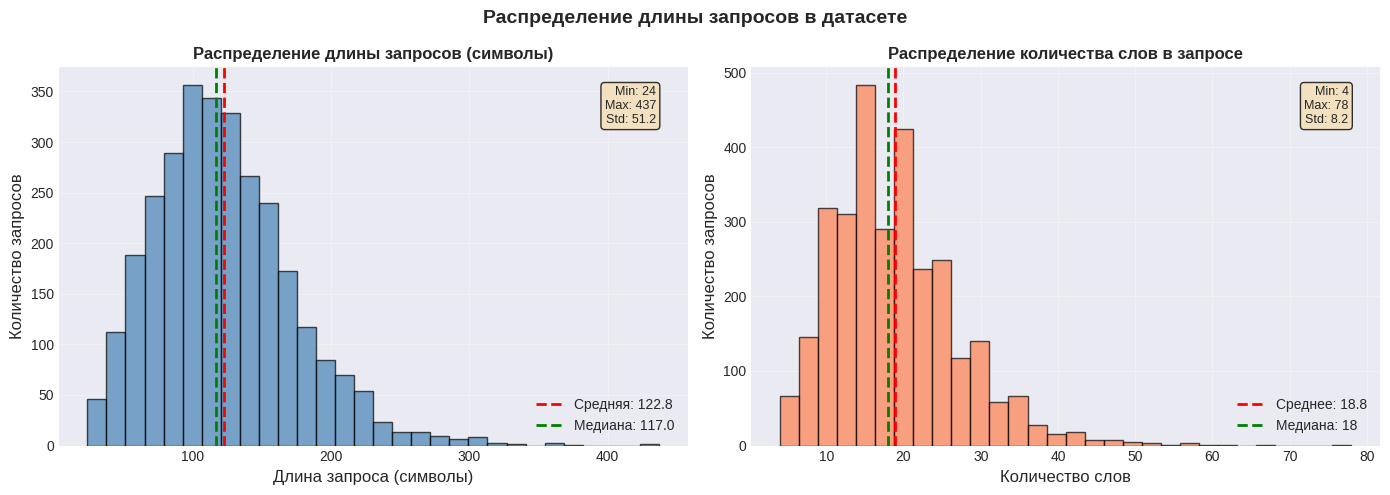

СТАТИСТИКА ДЛИНЫ ЗАПРОСОВ

По символам:
   Средняя длина: 122.8 символов
   Медианная длина: 117.0 символов
   Минимальная длина: 24 символов
   Максимальная длина: 437 символов
   Стандартное отклонение: 51.2

По словам:
   Среднее количество слов: 18.8
   Медианное количество слов: 18
   Минимальное количество слов: 4
   Максимальное количество слов: 78
   Стандартное отклонение: 8.2

Процентили (символы):
   10%: 62.0
   25%: 87.0
   50%: 117.0
   75%: 151.0
   90%: 189.0
   95%: 215.0

Процентили (слова):
   10%: 9.8
   25%: 13.0
   50%: 18.0
   75%: 23.0
   90%: 29.0
   95%: 34.0


In [5]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Распределение длины запросов в датасете', fontsize=14, fontweight='bold')

# ГРАФИК 1: Распределение длины в символах
ax1 = axes[0]
n, bins, patches = ax1.hist(df['query_length'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(df['query_length'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Средняя: {df["query_length"].mean():.1f}')
ax1.axvline(df['query_length'].median(), color='green', linestyle='--', linewidth=2,
            label=f'Медиана: {df["query_length"].median():.1f}')
ax1.set_xlabel('Длина запроса (символы)', fontsize=12)
ax1.set_ylabel('Количество запросов', fontsize=12)
ax1.set_title('Распределение длины запросов (символы)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

stats_text = f'Min: {df["query_length"].min()}\nMax: {df["query_length"].max()}\nStd: {df["query_length"].std():.1f}'
ax1.text(0.95, 0.95, stats_text, transform=ax1.transAxes,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
         fontsize=9)

# ГРАФИК 2: Распределение количества слов
ax2 = axes[1]
n, bins, patches = ax2.hist(df['query_words'], bins=30, edgecolor='black', alpha=0.7, color='coral')
ax2.axvline(df['query_words'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Среднее: {df["query_words"].mean():.1f}')
ax2.axvline(df['query_words'].median(), color='green', linestyle='--', linewidth=2,
            label=f'Медиана: {df["query_words"].median():.0f}')
ax2.set_xlabel('Количество слов', fontsize=12)
ax2.set_ylabel('Количество запросов', fontsize=12)
ax2.set_title('Распределение количества слов в запросе', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# Добавляем статистику на график
stats_text = f'Min: {df["query_words"].min()}\nMax: {df["query_words"].max()}\nStd: {df["query_words"].std():.1f}'
ax2.text(0.95, 0.95, stats_text, transform=ax2.transAxes,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
         fontsize=9)

plt.tight_layout()
plt.show()

print("СТАТИСТИКА ДЛИНЫ ЗАПРОСОВ")
print(f"\nПо символам:")
print(f"   Средняя длина: {df['query_length'].mean():.1f} символов")
print(f"   Медианная длина: {df['query_length'].median():.1f} символов")
print(f"   Минимальная длина: {df['query_length'].min()} символов")
print(f"   Максимальная длина: {df['query_length'].max()} символов")
print(f"   Стандартное отклонение: {df['query_length'].std():.1f}")

print(f"\nПо словам:")
print(f"   Среднее количество слов: {df['query_words'].mean():.1f}")
print(f"   Медианное количество слов: {df['query_words'].median():.0f}")
print(f"   Минимальное количество слов: {df['query_words'].min()}")
print(f"   Максимальное количество слов: {df['query_words'].max()}")
print(f"   Стандартное отклонение: {df['query_words'].std():.1f}")

# Процентили для символов
print(f"\nПроцентили (символы):")
for p in [10, 25, 50, 75, 90, 95]:
    print(f"   {p}%: {np.percentile(df['query_length'], p):.1f}")

# Процентили для слов
print(f"\nПроцентили (слова):")
for p in [10, 25, 50, 75, 90, 95]:
    print(f"   {p}%: {np.percentile(df['query_words'], p):.1f}")


 ТЕГИ (АСПЕКТЫ):
   - Всего уникальных тегов: 2555
   - Среднее количество тегов на запрос: 2.55
   - Медианное количество тегов: 2
   - Минимум тегов: 0
   - Максимум тегов: 8

   Распределение количества тегов на запрос:
      0 тег(а/ов): 48 запросов (1.6%)
      1 тег(а/ов): 314 запросов (10.5%)
      2 тег(а/ов): 1365 запросов (45.5%)
      3 тег(а/ов): 751 запросов (25.0%)
      4 тег(а/ов): 344 запросов (11.5%)
      5 тег(а/ов): 119 запросов (4.0%)
      6 тег(а/ов): 43 запросов (1.4%)
      7 тег(а/ов): 12 запросов (0.4%)
      8 тег(а/ов): 3 запросов (0.1%)

 ТОП-20 САМЫХ ЧАСТЫХ ТЕГОВ:
    1. 'тихое' — 288 раз(а) (9.6%)
    2. 'спокойно' — 245 раз(а) (8.2%)
    3. 'тихо' — 209 раз(а) (7.0%)
    4. 'уютно' — 128 раз(а) (4.3%)
    5. 'спокойное' — 116 раз(а) (3.9%)
    6. 'тихый' — 116 раз(а) (3.9%)
    7. 'уютное' — 95 раз(а) (3.2%)
    8. 'тихий' — 91 раз(а) (3.0%)
    9. 'уютный' — 81 раз(а) (2.7%)
   10. 'без шума' — 77 раз(а) (2.6%)
   11. 'громкая музыка' — 72 раз(а) (2.

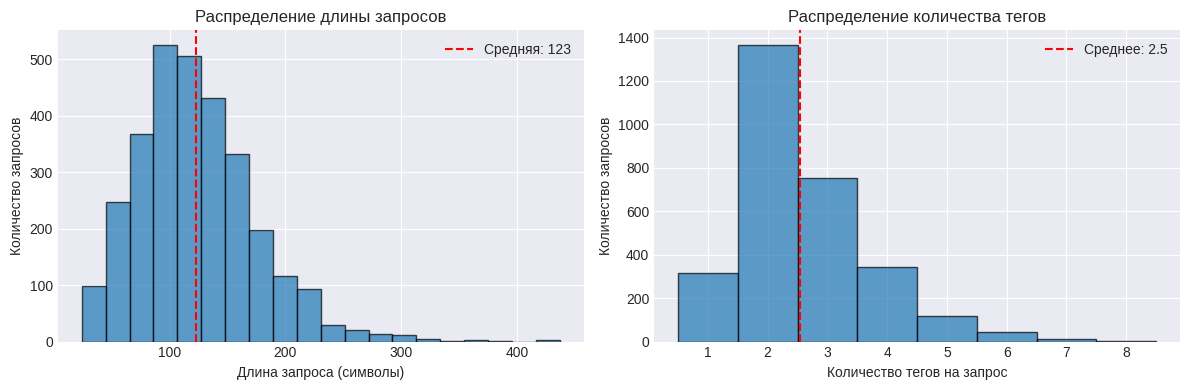

In [6]:
def parse_tags(tag_str):
    """Преобразует строку '[тег1, тег2]' в список ['тег1', 'тег2']"""
    try:
        # Убираем квадратные скобки и пробелы
        cleaned = tag_str.strip('[]')
        if not cleaned:
            return []
        # Разделяем по запятой и убираем кавычки
        tags = [t.strip().strip('"\'') for t in cleaned.split(',')]
        return [t for t in tags if t]
    except:
        return []

df['tags_list'] = df['atmosphere_tags'].apply(parse_tags)
df['tags_count'] = df['tags_list'].apply(len)

print(f"\n ТЕГИ (АСПЕКТЫ):")
print(f"   - Всего уникальных тегов: {len(set([tag for tags in df['tags_list'] for tag in tags]))}")
print(f"   - Среднее количество тегов на запрос: {df['tags_count'].mean():.2f}")
print(f"   - Медианное количество тегов: {df['tags_count'].median():.0f}")
print(f"   - Минимум тегов: {df['tags_count'].min()}")
print(f"   - Максимум тегов: {df['tags_count'].max()}")

# Распределение количества тегов
print("\n   Распределение количества тегов на запрос:")
tag_dist = df['tags_count'].value_counts().sort_index()
for count, num in tag_dist.items():
    print(f"      {count} тег(а/ов): {num} запросов ({num/len(df)*100:.1f}%)")

# ТОП-20 САМЫХ ЧАСТЫХ ТЕГОВ
all_tags = [tag for tags in df['tags_list'] for tag in tags]
tag_counter = Counter(all_tags)

print(f"\n ТОП-20 САМЫХ ЧАСТЫХ ТЕГОВ:")
for i, (tag, count) in enumerate(tag_counter.most_common(20), 1):
    print(f"   {i:2}. '{tag}' — {count} раз(а) ({count/len(df)*100:.1f}%)")

# ПРИМЕРЫ ЗАПРОСОВ С РАЗНЫМ КОЛИЧЕСТВОМ ТЕГОВ
print(f"\n ПРИМЕРЫ ЗАПРОСОВ:")
print("\n    С МИНИМАЛЬНЫМ количеством тегов:")
min_tags_df = df[df['tags_count'] == df['tags_count'].min()]
if len(min_tags_df) > 0:
    row = min_tags_df.iloc[0]
    print(f"      Запрос: {row['user_query'][:100]}...")
    print(f"      Теги: {row['atmosphere_tags']}")

print("\n    С МАКСИМАЛЬНЫМ количеством тегов:")
max_tags_df = df[df['tags_count'] == df['tags_count'].max()]
if len(max_tags_df) > 0:
    row = max_tags_df.iloc[0]
    print(f"      Запрос: {row['user_query'][:100]}...")
    print(f"      Теги: {row['atmosphere_tags']}")

# ВИЗУАЛИЗАЦИЯ
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Гистограмма длины запросов
axes[0].hist(df['query_length'], bins=20, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Длина запроса (символы)')
axes[0].set_ylabel('Количество запросов')
axes[0].set_title('Распределение длины запросов')
axes[0].axvline(df['query_length'].mean(), color='red', linestyle='dashed', label=f'Средняя: {df["query_length"].mean():.0f}')
axes[0].legend()

# Гистограмма количества тегов
axes[1].hist(df['tags_count'], bins=range(1, df['tags_count'].max()+2), edgecolor='black', alpha=0.7, align='left')
axes[1].set_xlabel('Количество тегов на запрос')
axes[1].set_ylabel('Количество запросов')
axes[1].set_title('Распределение количества тегов')
axes[1].axvline(df['tags_count'].mean(), color='red', linestyle='dashed', label=f'Среднее: {df["tags_count"].mean():.1f}')
axes[1].legend()

plt.tight_layout()

In [7]:
pip install pymorphy3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 721.4 kB/s eta 0:00:000:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 25.8 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


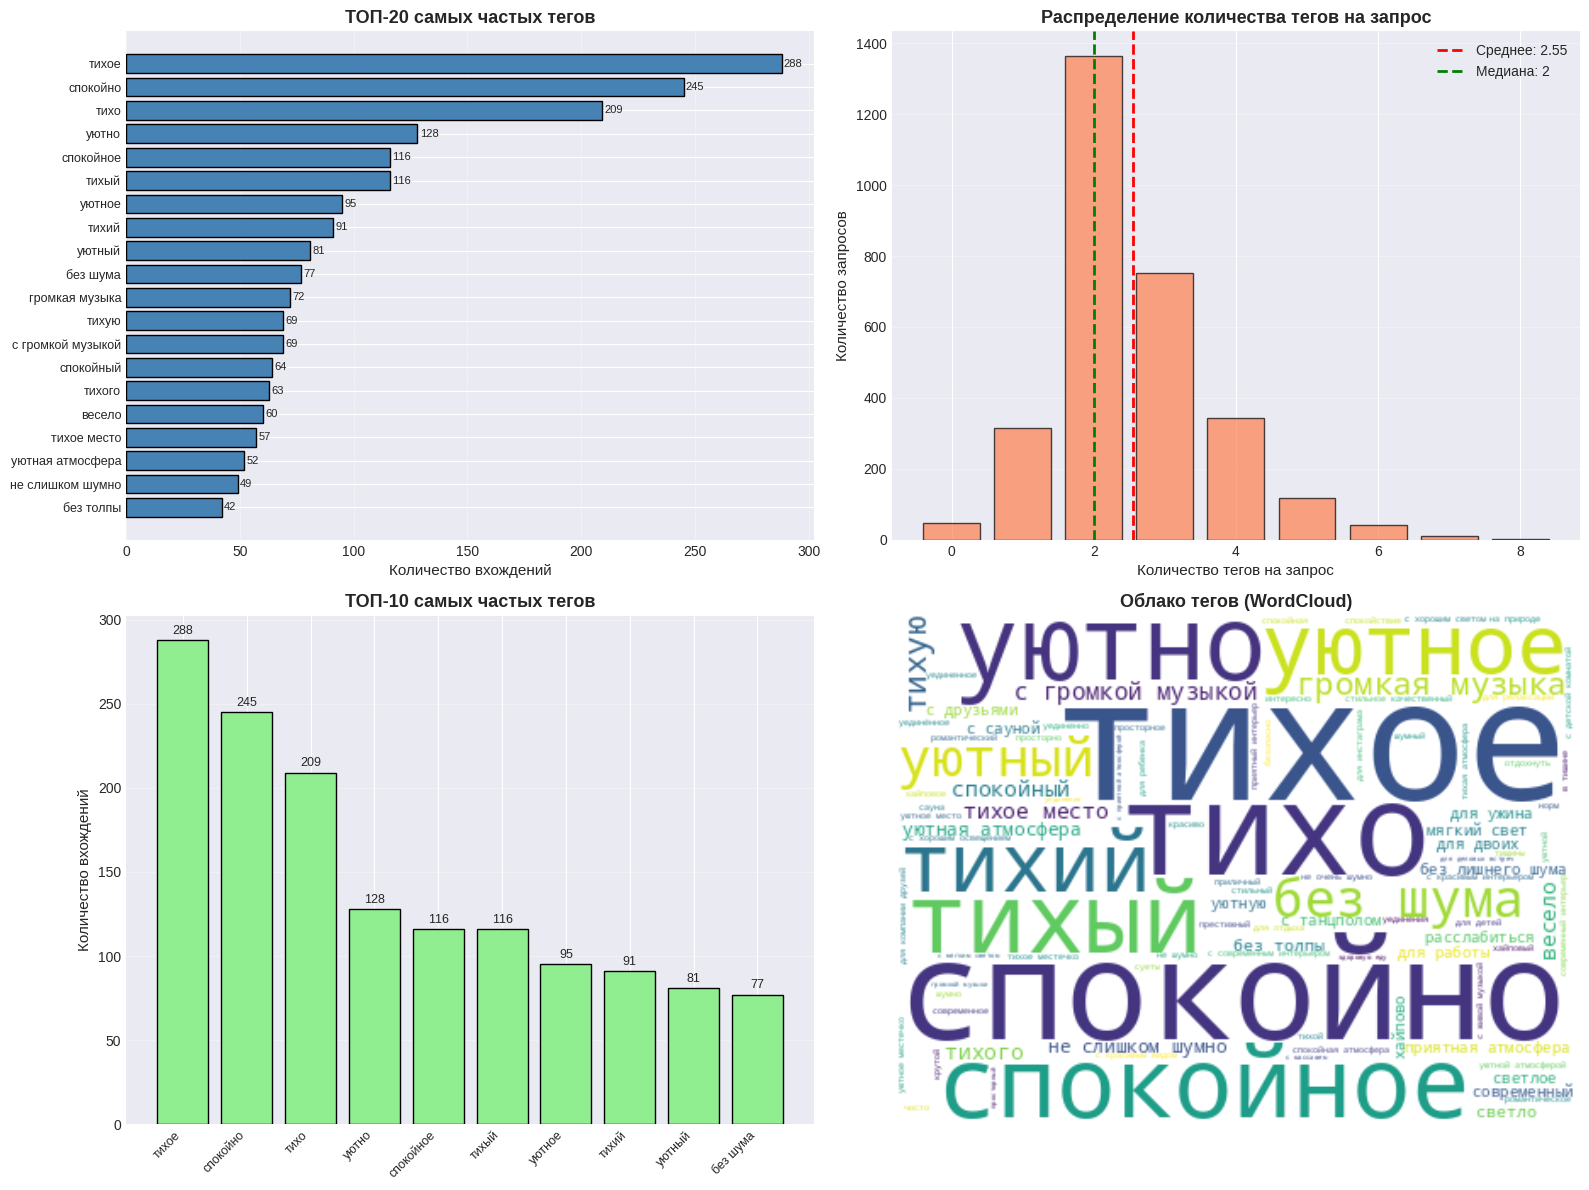

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
fig = plt.figure(figsize=(16, 12))

# ТОП-20 САМЫХ ЧАСТЫХ ТЕГОВ (горизонтальная гистограмма)
ax1 = plt.subplot(2, 2, 1)
top_tags = tag_counter.most_common(20)
tags = [tag[0] for tag in top_tags]
counts = [tag[1] for tag in top_tags]

bars = ax1.barh(range(len(tags)), counts, color='steelblue', edgecolor='black')
ax1.set_yticks(range(len(tags)))
ax1.set_yticklabels(tags, fontsize=9)
ax1.set_xlabel('Количество вхождений', fontsize=11)
ax1.set_title('ТОП-20 самых частых тегов', fontsize=13, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

for i, (bar, count) in enumerate(zip(bars, counts)):
    ax1.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             str(count), va='center', fontsize=8)

# РАСПРЕДЕЛЕНИЕ КОЛИЧЕСТВА ТЕГОВ НА ЗАПРОС
ax2 = plt.subplot(2, 2, 2)
tag_dist = df['tags_count'].value_counts().sort_index()
ax2.bar(tag_dist.index, tag_dist.values, color='coral', edgecolor='black', alpha=0.7)
ax2.axvline(df['tags_count'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Среднее: {df["tags_count"].mean():.2f}')
ax2.axvline(df['tags_count'].median(), color='green', linestyle='--', linewidth=2,
            label=f'Медиана: {df["tags_count"].median():.0f}')
ax2.set_xlabel('Количество тегов на запрос', fontsize=11)
ax2.set_ylabel('Количество запросов', fontsize=11)
ax2.set_title('Распределение количества тегов на запрос', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)

# ТОП-10 ТЕГОВ (вертикальная гистограмма)
ax3 = plt.subplot(2, 2, 3)
top10_tags = tag_counter.most_common(10)
tags10 = [tag[0] for tag in top10_tags]
counts10 = [tag[1] for tag in top10_tags]

bars = ax3.bar(range(len(tags10)), counts10, color='lightgreen', edgecolor='black')
ax3.set_xticks(range(len(tags10)))
ax3.set_xticklabels(tags10, rotation=45, ha='right', fontsize=9)
ax3.set_ylabel('Количество вхождений', fontsize=11)
ax3.set_title('ТОП-10 самых частых тегов', fontsize=13, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# Добавляем значения
for bar, count in zip(bars, counts10):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             str(count), ha='center', va='bottom', fontsize=9)

# облако слов
ax4 = plt.subplot(2, 2, 4)
try:
    from wordcloud import WordCloud

    # Создаём словарь частот
    word_freq = dict(tag_counter)

    # Генерируем облако слов
    wordcloud = WordCloud(width=400, height=300,
                         background_color='white',
                         colormap='viridis',
                         max_words=100,
                         font_path=None).generate_from_frequencies(word_freq)

    ax4.imshow(wordcloud, interpolation='bilinear')
    ax4.axis('off')
    ax4.set_title('Облако тегов (WordCloud)', fontsize=13, fontweight='bold')
except ImportError:
    # Если wordcloud не установлен, показываем круговую диаграмму
    top5_tags = tag_counter.most_common(5)
    other_count = sum(count for tag, count in tag_counter.most_common()[5:])

    labels = [tag[0] for tag in top5_tags] + ['Другие']
    sizes = [tag[1] for tag in top5_tags] + [other_count]
    colors = plt.cm.Set3(range(len(labels)))

    ax4.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
    ax4.set_title('Распределение тегов (ТОП-5)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

Выполним проверку на пустые словари с атмосферой

In [ ]:
# Функция для проверки, является ли значение тегов пустым
def is_empty_tags(tag_value):
    # Проверяем на NaN, None, пустую строку, строку "[]" или "[ ]"
    if pd.isna(tag_value):
        return True
    if not isinstance(tag_value, str):
        tag_value = str(tag_value)
    cleaned = tag_value.strip()
    return cleaned == '' or cleaned == '[]' or cleaned == '[ ]'

empty_mask = df['atmosphere_tags'].apply(is_empty_tags)
empty_records = df[empty_mask]

print(f" НАЙДЕНО ЗАПИСЕЙ БЕЗ ТЕГОВ: {len(empty_records)}\n")

if len(empty_records) > 0:
    for idx, row in empty_records.iterrows():
        print(f" ЗАПИСЬ #{idx + 1} (индекс {idx}):")
        print(f"   Запрос пользователя: {row['user_query']}")
        print(f"   Поле atmosphere_tags: {row['atmosphere_tags']}")
        print("-" * 80)
else:
    print("Все записи содержат теги.")

 НАЙДЕНО ЗАПИСЕЙ БЕЗ ТЕГОВ: 48

 ЗАПИСЬ #86 (индекс 85):
   Запрос пользователя: где найти магазин садовой техники для отдыха после работы
   Поле atmosphere_tags: []
--------------------------------------------------------------------------------
 ЗАПИСЬ #106 (индекс 105):
   Запрос пользователя: Где хороший спорт-бара для массажа?
   Поле atmosphere_tags: []
--------------------------------------------------------------------------------
 ЗАПИСЬ #182 (индекс 181):
   Запрос пользователя: Нужна специализированная торговая точка для садоводства, с широким ассортиментом посадочных материалов и профессиональным персоналом.
   Поле atmosphere_tags: []
--------------------------------------------------------------------------------
 ЗАПИСЬ #192 (индекс 191):
   Запрос пользователя: Где хорошая выпечка для ребенка?
   Поле atmosphere_tags: []
--------------------------------------------------------------------------------
 ЗАПИСЬ #206 (индекс 205):
   Запрос пользователя: Ищем место для ком

Удалим такие записи

In [9]:
df = pd.read_csv('/kaggle/input/datasets/krasavina/sintetic/synthetic_dataset.csv', sep=';', encoding='utf-8-sig')

# Оставляем только непустые теги
def has_valid_tags(tag_value):
    if pd.isna(tag_value):
        return False
    tag_str = str(tag_value).strip()
    # Пустые скобки или пустая строка — не подходят
    return tag_str not in ('', '[]', '[ ]')

df_clean = df[df['atmosphere_tags'].apply(has_valid_tags)]

print(f"Было записей: {len(df)}")
print(f"Осталось после чистки: {len(df_clean)}")
print(f"Удалено пустых: {len(df) - len(df_clean)}")

df_clean.to_csv('synthetic_dataset_clean.csv', index=False, sep=';', encoding='utf-8-sig', quoting=0)

Было записей: 2999
Осталось после чистки: 2951
Удалено пустых: 48


Попробуем отвалидировать полученные теги с помощью одной языковой модели другой языковой моделью. Зададим ей подходящий промт.

In [ ]:
import ollama
import pandas as pd
import json
import time
import ast
from tqdm import tqdm

# МОДЕЛИ ДЛЯ ВАЛИДАЦИИ
MODELS = {
    "validator": "qwen2.5:7b",
    "backup": "OxW/Vikhr-Nemo-12B-Instruct-R-21-09-24:q4_K_M"
}

VALIDATION_PROMPT = """Ты — валидатор тегов для поисковых запросов.

Запрос пользователя: "{query}"
Оригинальные теги: {original_tags}

ПРАВИЛА:
1. Теги описывают ТОЛЬКО атмосферу или интерьер места
2. НЕ включай: тип заведения (кафе, сауна, ресторан), действия (посидеть, поесть), местоположение (метро)
3. Теги ДОЛЖНЫ БЫТЬ ДОСЛОВНО из запроса
4. Удали лишние теги, добавь пропущенные

ХОРОШИЕ ТЕГИ: "тихое", "с камином", "уютное", "светлое"
ПЛОХИЕ ТЕГИ: "кофейня", "посидеть", "метро", "вкусно"

Верни ТОЛЬКО JSON: {{"corrected_tags": ["тег1", "тег2", ...]}}"""

def safe_parse_tags(tag_str):
    """Безопасно преобразует строку с тегами в список"""
    if pd.isna(tag_str) or not isinstance(tag_str, str):
        return []
    try:
        # Убираем квадратные скобки и пробелы
        cleaned = tag_str.strip('[]')
        if not cleaned:
            return []
        # Разделяем по запятой, убираем кавычки и пробелы
        tags = [t.strip().strip('"\'') for t in cleaned.split(',')]
        return [t for t in tags if t]
    except:
        return []

def filter_tags_in_query(tags, query):
    """Оставляет теги, которые дословно встречаются в запросе"""
    query_lower = query.lower()
    return [tag for tag in tags if tag.lower() in query_lower]

def validate_with_model(query, original_tags, model_name):
    """Запускает валидацию на указанной модели"""
    for attempt in range(2):
        try:
            response = ollama.chat(
                model=model_name,
                messages=[{
                    'role': 'user',
                    'content': VALIDATION_PROMPT.format(
                        query=query,
                        original_tags=original_tags
                    )
                }],
                options={'temperature': 0.0}  # Ещё строже
            )

            content = response['message']['content']
            start = content.find('{')
            end = content.rfind('}') + 1

            if start != -1 and end != 0:
                data = json.loads(content[start:end])
                # Оставляем только теги из запроса
                raw_tags = data.get('corrected_tags', [])
                return filter_tags_in_query(raw_tags, query)
        except Exception as e:
            if attempt == 0:  # Логируем только первую ошибку
                print(f"Ошибка в {model_name}: {e}")
            time.sleep(1)
    return []

def validate_dataset(df, validated_file='validated_dataset.csv'):
    """Валидация всего датасета"""
    results = []
    changed_count = 0

    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Валидация"):
        query = row['user_query']
        original_tags = safe_parse_tags(row['atmosphere_tags'])

        # Валидация
        validated_tags = validate_with_model(query, original_tags, MODELS["validator"])

        if not validated_tags:
            validated_tags = validate_with_model(query, original_tags, MODELS["backup"])

        if not validated_tags and original_tags:
            validated_tags = filter_tags_in_query(original_tags, query)

        # Проверяем, изменились ли теги
        if set(original_tags) != set(validated_tags):
            changed_count += 1

        results.append({
            'user_query': query,
            'original_tags': str(original_tags),
            'validated_tags': str(validated_tags)
        })

    # Сохраняем результат
    result_df = pd.DataFrame(results)
    result_df.to_csv(validated_file, index=False, sep=';', encoding='utf-8-sig')

    print(f"\n Валидация завершена! Результат в {validated_file}")
    print(f" Изменено записей: {changed_count} из {len(results)} ({changed_count/len(results)*100:.1f}%)")

    return result_df

if __name__ == "__main__":
    df = pd.read_csv('synthetic_dataset_clean.csv', sep=';', encoding='utf-8-sig')
    validated = validate_dataset(df, 'synthetic_dataset_validated.csv')

Валидация: 100%|██████████| 2951/2951 [4:30:33<00:00,  5.50s/it]  



✅ Валидация завершена! Результат в synthetic_dataset_validated.csv
📊 Изменено записей: 2271 из 2951 (77.0%)


Однако после проверки получившегося датасета было выяснено, что при "валидации" языковая модель убирала практически все обнаруженные теги, так что такая проверка была признана неподходящей.

Анализ ранее показал, что датасет не достаточно разнообразен, сильно превышает кол-во тегов для спокойных и уютных, тихих мест + датасет достаточно однотипен, содержит примерно одинаковое число тегов в каждом запросе, что не отражает возможное итоговое различие пользовательских запросов. 

Создадим еще немного строк с другим промтом, чтобы было более подробное описание мест:

In [ ]:
import ollama
import pandas as pd
import json
import time
import random
from tqdm import tqdm

VENUE_TYPES = [
    'Sauna', 'Convention center', 'Cafe', 'Museum', 'Spa', 'Zoo',
       'Training center', 'Concert hall', 'Pool hall',
       'Thai massage therapist', 'Performing arts theater',
       "Children's theater", 'Fast food restaurant', 'Movie theater',
       'Portrait studio', 'Restaurant', 'Bar', 'Computer club',
       'Computer training school', 'Sauna store', 'Party store',
       'Photography studio', 'Coffee shop', 'Tennis club',
       'Italian restaurant', 'Amusement center', 'Subway station',
       'Entertainment agency', 'Sports complex', 'Airsoft supply store',
       'Educational institution', 'Tennis court', 'Go-karting venue',
       'Public sauna', 'Farm', 'Georgian restaurant', 'Park', 'Club',
       'Photographer', 'Exhibition and trade center', 'Karaoke bar',
       "Children's cafe", 'Family restaurant', 'Night club',
       'Tattoo shop', 'Day care center', 'Pet store', 'Social club',
       'Coworking space', 'Corporate office', 'Hotel', 'Botanical garden',
       'Historical landmark', 'Garden', 'Movie studio',
       'Picture frame shop', 'Modern art museum', 'Country club',
       'Leisure center', 'Hypermarket', 'Day spa', 'Baths and saunas',
       'Public bath', 'Observatory', 'Event planner', 'Hookah bar',
       'Amusement park ride', 'Amusement park',
       "Children's amusement center", 'Tram stop', 'Bar & grill',
       'Bowling alley', 'Spa and health club',
       'Eastern European restaurant', 'Gym', 'University',
       'Motorsports store', 'Transport hub', 'Ecological park',
       'City park', 'Pool billard club', 'Billiards supply store',
       'Arboretum', 'Model portfolio studio', 'Bowling club', 'Stand bar',
       'Tour agency', 'Bowling supply shop', 'American restaurant',
       'Business center', 'Vietnamese restaurant',
       'Lebanese restaurant', 'Russian restaurant', 'Banquet hall',
       'Aquatic center', 'Art gallery', 'Opera house', 'Army museum',
       'Cultural center', 'European restaurant', 'Swimming pool',
       'Recording studio', 'Breakfast restaurant', 'Halal restaurant',
       'Tea house', 'Small plates restaurant', 'Skatepark',
       'Escape room center', 'Transit stop', 'Ice skating club',
       'Golf club', 'Sports school', 'Rock climbing gym',
       'Live music bar', 'Coffee stand', 'Art museum',
       'Photography service', 'Japanese restaurant',
       'Commercial photographer', 'Aquarium', 'Planetarium', 'Market',
       'Adult entertainment club', 'Dance club',
       'Environmental organization', 'Internet cafe',
       'Historical place museum', 'Pizza restaurant',
       'Dessert restaurant', 'Art studio', 'Mexican restaurant',
       'Sports club', 'Monastery', 'Hiking area', 'Indoor playground',
       'Jazz club', 'Stadium', 'Clothing store', 'Souvenir store',
       'Science museum', 'Cafeteria', 'Art cafe', 'Fitness center',
       'Health spa', 'Recreation center', 'Ice skating rink',
       'IMAX theater', 'Live music venue', 'Passport photo processor',
       'Photo restoration service', 'Photo shop', 'Photo lab',
       'Education center', 'Photography class', 'Photography school',
       "Children's club", 'Playground', 'Football club', 'Soccer field',
       'Vegetarian restaurant', 'Landscaping supply store',
       'Western restaurant', 'Ski resort', 'Shopping mall', 'Frituur',
       'Soup restaurant', 'Hammam', 'Chinese restaurant', 'Dog breeder',
       'Health food restaurant', 'Garden center', 'Memorial estate',
       'Synagogue', 'Coffee store', 'Mountain cable car',
       'Event ticket seller', 'Sports activity location',
       'Chicken restaurant', 'Bakery', 'Russian Orthodox church',
       'Business networking company', 'Learning center',
       'Secondary school', 'Off track betting shop', 'Buffet restaurant',
       'Equestrian club', 'Gondola lift station', 'Transit station',
       'Handicraft fair', 'Condominium complex', 'Clock repair service',
       'Ice skating instructor', 'Prison', 'Train station',
       'Nature preserve', 'Telescope store', 'Hamburger restaurant',
       'Sushi restaurant', 'Medical Center', 'Deli', 'Turkish restaurant',
       'Massage therapist', 'Massage spa', 'Art school',
       'Association / Organization', 'Beach volleyball court',
       'Memorial park', 'Pan-Asian restaurant', 'Badminton court',
       'Video production service', 'Falafel restaurant',
       'French restaurant', 'Press advisory', 'Water park', 'Airport',
       'Car racing venue', 'International airport',
       'Outdoor movie theater', 'Curling hall', 'Public university',
       'City government office', 'Archaeological museum',
       'Museum of space history', 'Handicraft museum', 'History museum',
       'Table tennis club', 'Art center', 'National park',
       'General contractor', 'Cocktail bar', 'High ropes course',
       'Puppet theater', 'E-commerce service', 'Outlet mall', 'Bistro',
       'Pub', 'Sports bar', 'Athletic field', 'Historical place',
       'Theme park', 'Paintball center', 'Sauna club', 'Wildlife park',
       'Athletic park', 'Parking lot', 'Athletic track', 'Pond',
       'Wedding photographer', 'Housing development', 'Manufacturer',
       'Espresso bar', 'Adventure sports center', 'Castle',
       'Travel agency', 'Plaza', 'Short term apartment rental agency',
       'Rock climbing', 'Tourist attraction', 'Community center',
       'Erotic massage', 'Heritage preservation', 'Community garden',
       'Beauty salon', 'Asian restaurant', 'Health resort',
       'Public medical center', 'Holiday home', 'Armenian restaurant',
       'Warehouse club', 'Chess club', 'Hat shop', 'Barbecue restaurant',
       'Shawarma restaurant', 'Rock music club', 'Roller skating rink',
       'Sculpture', 'Sporting goods store', 'Cathedral',
       'Self service restaurant', 'Brewpub', 'Dance school',
       'Music school', 'Delivery Restaurant', 'Ballet theater',
       'Theater company', 'Lido', 'Thermal baths', 'Aerial photographer',
       'Table tennis facility', 'Visitor center', 'Art dealer',
       'Drawing lessons', 'War museum', 'Wellness center',
       'Fine dining restaurant', 'Super public bath',
       'Ukrainian restaurant', 'Natural goods store', 'Needlework shop',
       'Adult education school', 'Monument', "Children's party service",
       'Uzbeki restaurant', 'Board game club', 'Dinner theater',
       'Wine bar', 'Youth center', 'Public library', 'Restaurant or cafe',
       'Wrestling school', 'Cat cafe', 'Equestrian facility',
       'Repair service', 'Herbal medicine store', 'Modeling agency',
       'Airstrip', 'Landscaper', 'Music producer', 'Diner', 'Sports',
       'Shooting range', 'Outdoor sports store'
]

DETAILED_GENERATION_PROMPT = """Ты — генератор реалистичных поисковых запросов пользователей о местах (кафе, рестораны, парки, сауны, музеи).

Задача: создать запрос от первого лица с детальным описанием атмосферы и интерьера.

Правила:
1. Язык — русский, живой, естественный.
2. Опиши:
   - АТМОСФЕРУ (тихо/шумно, романтично/энергично, уютно/строго, уединённо/людно)
   - ИНТЕРЬЕР (деревянные столы, мягкие кресла, панорамные окна, свечи, камин, неон, открытая кухня)
   - ОСВЕЩЕНИЕ (приглушённый свет, много света, торшеры, бра)
   - ЗВУКИ (живая музыка, тишина, электроника, разговоры)
3. Длина: 2-4 предложения.

Примеры хороших запросов:

Пример 1 (романтичное кафе):
"Ищу уютное кафе с приглушённым светом и мягкими диванами, чтобы спокойно поужинать вдвоём под живую акустическую музыку. Хочется, чтобы было не шумно, а на столах стояли свечи."

Пример 2 (шумный бар):
"Нужен модный бар с открытой кирпичной стеной и неоновой подсветкой, где играет электронная музыка и можно потанцевать в толпе. Чтобы атмосфера была энерджайзер, не для скучных разговоров."

Пример 3 (спокойная сауна):
"Хочу попариться в деревянной сауне с панорамным окном в лес, где вместо музыки — тишина и запах эвкалипта. Чтобы внутри было просторно, светло и никого, кроме нас с парой друзей."

Пример 4 (коворкинг):
"Ищу коворкинг с большими окнами и высокими потолками, где много естественного света и розеток у каждого стола. Чтобы можно было уединиться в кресле-мешке и работалось спокойно, без лишнего шума."

Теперь сгенерируй запрос для типа места: {venue}

Формат вывода — ТОЛЬКО JSON: {{"query": "...", "tags": [...]}}

Теги — это дословные фразы из запроса, описывающие атмосферу или интерьер (2-5 тегов).
"""

def generate_detailed_record(model_name='OxW/Vikhr-Nemo-12B-Instruct-R-21-09-24:q4_K_M'):
    """Генерирует один детальный запрос"""
    venue = random.choice(VENUE_TYPES)

    for attempt in range(3):
        try:
            response = ollama.chat(
                model=model_name,
                messages=[{
                    'role': 'user',
                    'content': DETAILED_GENERATION_PROMPT.format(venue=venue)
                }],
                options={
                    'temperature': 0.85,
                    'num_predict': 512
                }
            )

            content = response['message']['content']
            start = content.find('{')
            end = content.rfind('}') + 1

            if start != -1 and end != 0:
                data = json.loads(content[start:end])
                return {
                    'user_query': data['query'],
                    'atmosphere_tags': '[' + ', '.join(data.get('tags', [])) + ']'
                }
        except Exception as e:
            print(f"Ошибка (попытка {attempt+1}): {e}")
            time.sleep(1)

    return None

if __name__ == "__main__":
    NUM_SAMPLES = 322
    print(f" Запуск детальной генерации {NUM_SAMPLES} запросов...")
    print(f"  Типы мест: {len(VENUE_TYPES)}")

    results = []
    for i in tqdm(range(NUM_SAMPLES)):
        record = generate_detailed_record()
        if record:
            results.append(record)
        time.sleep(0.3)

    if results:
        df = pd.DataFrame(results)
        df.to_csv('detailed_queries.csv', index=False, sep=';', encoding='utf-8-sig')
        print(f"\n✅ Сохранено {len(results)} запросов в detailed_queries.csv")

        # Показываем пару примеров
        print("\n🔍 ПРИМЕРЫ:")
        for i in range(min(3, len(df))):
            print(f"\n--- {i+1} ---")
            print(f"Запрос: {df.iloc[i]['user_query']}")
            print(f"Теги:   {df.iloc[i]['atmosphere_tags']}")

🚀 Запуск детальной генерации 322 запросов...
🏷️  Типы мест: 322


 44%|████▍     | 141/322 [41:06<51:44, 17.15s/it]  

Ошибка (попытка 1): Expecting ',' delimiter: line 3 column 3 (char 267)


100%|██████████| 322/322 [1:32:22<00:00, 17.21s/it]



✅ Сохранено 322 запросов в detailed_queries.csv

🔍 ПРИМЕРЫ:

--- 1 ---
Запрос: Ищу астрономический планетарий с мягкими креслами, где можно уютно устроиться и наблюдать за звёздами на большом куполообразном экране. Хочется, чтобы звуки были минимальны или присутствовала приятная фоновая музыка, а освещение было немного приглушенным, создавая атмосферу глубкого космоса.
Теги:   [астрономический планетарий, мягкие кресла, звёздное небо, приглушённое свет, фоновая музыка]

--- 2 ---
Запрос: Хочу найти развлекательный центр с просторным залом для боулинга и играми виртуальной реальности. Ищу место, где царит веселая атмосфера, много народу, яркое освещение и звучит популярная музыка. Предпочтительно, чтобы было уютное кафе с мягкими креслами внутри центра.
Теги:   [развлекательный центр, боулинг, виртуальная реальность, веселая атмосфера, яркое освещение, популярная музыка, уютное кафе]

--- 3 ---
Запрос: Ищу sports bar с большими экранами для просмотра спортивных событий. Хочется уютного

Добавим еще больше подобных подробных запросов, сгенерируем еще 3000 строк:

In [ ]:
import ollama
import pandas as pd
import json
import time
import random
from tqdm import tqdm

VENUE_TYPES = [
    'Sauna', 'Convention center', 'Cafe', 'Museum', 'Spa', 'Zoo',
       'Training center', 'Concert hall', 'Pool hall',
       'Thai massage therapist', 'Performing arts theater',
       "Children's theater", 'Fast food restaurant', 'Movie theater',
       'Portrait studio', 'Restaurant', 'Bar', 'Computer club',
       'Computer training school', 'Sauna store', 'Party store',
       'Photography studio', 'Coffee shop', 'Tennis club',
       'Italian restaurant', 'Amusement center', 'Subway station',
       'Entertainment agency', 'Sports complex', 'Airsoft supply store',
       'Educational institution', 'Tennis court', 'Go-karting venue',
       'Public sauna', 'Farm', 'Georgian restaurant', 'Park', 'Club',
       'Photographer', 'Exhibition and trade center', 'Karaoke bar',
       "Children's cafe", 'Family restaurant', 'Night club',
       'Tattoo shop', 'Day care center', 'Pet store', 'Social club',
       'Coworking space', 'Corporate office', 'Hotel', 'Botanical garden',
       'Historical landmark', 'Garden', 'Movie studio',
       'Picture frame shop', 'Modern art museum', 'Country club',
       'Leisure center', 'Hypermarket', 'Day spa', 'Baths and saunas',
       'Public bath', 'Observatory', 'Event planner', 'Hookah bar',
       'Amusement park ride', 'Amusement park',
       "Children's amusement center", 'Tram stop', 'Bar & grill',
       'Bowling alley', 'Spa and health club',
       'Eastern European restaurant', 'Gym', 'University',
       'Motorsports store', 'Transport hub', 'Ecological park',
       'City park', 'Pool billard club', 'Billiards supply store',
       'Arboretum', 'Model portfolio studio', 'Bowling club', 'Stand bar',
       'Tour agency', 'Bowling supply shop', 'American restaurant',
       'Business center', 'Vietnamese restaurant',
       'Lebanese restaurant', 'Russian restaurant', 'Banquet hall',
       'Aquatic center', 'Art gallery', 'Opera house', 'Army museum',
       'Cultural center', 'European restaurant', 'Swimming pool',
       'Recording studio', 'Breakfast restaurant', 'Halal restaurant',
       'Tea house', 'Small plates restaurant', 'Skatepark',
       'Escape room center', 'Transit stop', 'Ice skating club',
       'Golf club', 'Sports school', 'Rock climbing gym',
       'Live music bar', 'Coffee stand', 'Art museum',
       'Photography service', 'Japanese restaurant',
       'Commercial photographer', 'Aquarium', 'Planetarium', 'Market',
       'Adult entertainment club', 'Dance club',
       'Environmental organization', 'Internet cafe',
       'Historical place museum', 'Pizza restaurant',
       'Dessert restaurant', 'Art studio', 'Mexican restaurant',
       'Sports club', 'Monastery', 'Hiking area', 'Indoor playground',
       'Jazz club', 'Stadium', 'Clothing store', 'Souvenir store',
       'Science museum', 'Cafeteria', 'Art cafe', 'Fitness center',
       'Health spa', 'Recreation center', 'Ice skating rink',
       'IMAX theater', 'Live music venue', 'Passport photo processor',
       'Photo restoration service', 'Photo shop', 'Photo lab',
       'Education center', 'Photography class', 'Photography school',
       "Children's club", 'Playground', 'Football club', 'Soccer field',
       'Vegetarian restaurant', 'Landscaping supply store',
       'Western restaurant', 'Ski resort', 'Shopping mall', 'Frituur',
       'Soup restaurant', 'Hammam', 'Chinese restaurant', 'Dog breeder',
       'Health food restaurant', 'Garden center', 'Memorial estate',
       'Synagogue', 'Coffee store', 'Mountain cable car',
       'Event ticket seller', 'Sports activity location',
       'Chicken restaurant', 'Bakery', 'Russian Orthodox church',
       'Business networking company', 'Learning center',
       'Secondary school', 'Off track betting shop', 'Buffet restaurant',
       'Equestrian club', 'Gondola lift station', 'Transit station',
       'Handicraft fair', 'Condominium complex', 'Clock repair service',
       'Ice skating instructor', 'Prison', 'Train station',
       'Nature preserve', 'Telescope store', 'Hamburger restaurant',
       'Sushi restaurant', 'Medical Center', 'Deli', 'Turkish restaurant',
       'Massage therapist', 'Massage spa', 'Art school',
       'Association / Organization', 'Beach volleyball court',
       'Memorial park', 'Pan-Asian restaurant', 'Badminton court',
       'Video production service', 'Falafel restaurant',
       'French restaurant', 'Press advisory', 'Water park', 'Airport',
       'Car racing venue', 'International airport',
       'Outdoor movie theater', 'Curling hall', 'Public university',
       'City government office', 'Archaeological museum',
       'Museum of space history', 'Handicraft museum', 'History museum',
       'Table tennis club', 'Art center', 'National park',
       'General contractor', 'Cocktail bar', 'High ropes course',
       'Puppet theater', 'E-commerce service', 'Outlet mall', 'Bistro',
       'Pub', 'Sports bar', 'Athletic field', 'Historical place',
       'Theme park', 'Paintball center', 'Sauna club', 'Wildlife park',
       'Athletic park', 'Parking lot', 'Athletic track', 'Pond',
       'Wedding photographer', 'Housing development', 'Manufacturer',
       'Espresso bar', 'Adventure sports center', 'Castle',
       'Travel agency', 'Plaza', 'Short term apartment rental agency',
       'Rock climbing', 'Tourist attraction', 'Community center',
       'Erotic massage', 'Heritage preservation', 'Community garden',
       'Beauty salon', 'Asian restaurant', 'Health resort',
       'Public medical center', 'Holiday home', 'Armenian restaurant',
       'Warehouse club', 'Chess club', 'Hat shop', 'Barbecue restaurant',
       'Shawarma restaurant', 'Rock music club', 'Roller skating rink',
       'Sculpture', 'Sporting goods store', 'Cathedral',
       'Self service restaurant', 'Brewpub', 'Dance school',
       'Music school', 'Delivery Restaurant', 'Ballet theater',
       'Theater company', 'Lido', 'Thermal baths', 'Aerial photographer',
       'Table tennis facility', 'Visitor center', 'Art dealer',
       'Drawing lessons', 'War museum', 'Wellness center',
       'Fine dining restaurant', 'Super public bath',
       'Ukrainian restaurant', 'Natural goods store', 'Needlework shop',
       'Adult education school', 'Monument', "Children's party service",
       'Uzbeki restaurant', 'Board game club', 'Dinner theater',
       'Wine bar', 'Youth center', 'Public library', 'Restaurant or cafe',
       'Wrestling school', 'Cat cafe', 'Equestrian facility',
       'Repair service', 'Herbal medicine store', 'Modeling agency',
       'Airstrip', 'Landscaper', 'Music producer', 'Diner', 'Sports',
       'Shooting range', 'Outdoor sports store'
]

DETAILED_GENERATION_PROMPT = """Ты — генератор реалистичных поисковых запросов пользователей о местах (кафе, рестораны, парки, сауны, музеи).

Задача: создать запрос от первого лица с детальным описанием атмосферы и интерьера.

Правила:
1. Язык — русский, живой, естественный.
2. Опиши:
   - АТМОСФЕРУ (например: тихо/шумно, романтично/энергично, уютно/строго, уединённо/людно)
   - ИНТЕРЬЕР (например: деревянные столы, мягкие кресла, панорамные окна, свечи, камин, неон, открытая кухня)
   - ОСВЕЩЕНИЕ (например: приглушённый свет, много света, торшеры, бра, яркий солнечный свет)
   - ЗВУКИ (например: живая музыка, тишина, электроника, разговоры)
3. Длина: 2-4 предложения.
4. В разных запросах используй разную лексику и разные синонимы атмосфер, интерьера и звуков, не ограничивайся только теми, что указаны в примерах.

Примеры хороших запросов:

Пример 1 (романтичное кафе):
"Ищу уютное кафе с приглушённым светом и мягкими диванами, чтобы спокойно поужинать вдвоём под живую акустическую музыку. Хочется, чтобы было не шумно, а на столах стояли свечи."

Пример 2 (шумный бар):
"Нужен модный бар с открытой кирпичной стеной и неоновой подсветкой, где играет электронная музыка и можно потанцевать в толпе. Чтобы атмосфера была энерджайзер, не для скучных разговоров."

Пример 3 (спокойная сауна):
"Хочу попариться в деревянной сауне с панорамным окном в лес, где вместо музыки — тишина и запах эвкалипта. Чтобы внутри было просторно, светло и никого, кроме нас с парой друзей."

Пример 4 (коворкинг):
"Ищу коворкинг с большими окнами и высокими потолками, где много естественного света и розеток у каждого стола. Чтобы можно было уединиться в кресле-мешке и работалось спокойно, без лишнего шума."

Теперь сгенерируй запрос для типа места: {venue}

Формат вывода — ТОЛЬКО JSON: {{"query": "...", "tags": [...]}}

Теги — это дословные фразы из запроса, описывающие атмосферу или интерьер (1-5 тегов).
"""

def generate_detailed_record(model_name='OxW/Vikhr-Nemo-12B-Instruct-R-21-09-24:q4_K_M'):
    """Генерирует один детальный запрос"""
    venue = random.choice(VENUE_TYPES)

    for attempt in range(3):
        try:
            response = ollama.chat(
                model=model_name,
                messages=[{
                    'role': 'user',
                    'content': DETAILED_GENERATION_PROMPT.format(venue=venue)
                }],
                options={
                    'temperature': 0.85,
                    'num_predict': 512  # Больше токенов для детальности
                }
            )

            content = response['message']['content']
            start = content.find('{')
            end = content.rfind('}') + 1

            if start != -1 and end != 0:
                data = json.loads(content[start:end])
                return {
                    'user_query': data['query'],
                    'atmosphere_tags': '[' + ', '.join(data.get('tags', [])) + ']'
                }
        except Exception as e:
            print(f"Ошибка (попытка {attempt+1}): {e}")
            time.sleep(1)

    return None

if __name__ == "__main__":
    NUM_SAMPLES = 3000
    print(f" Запуск детальной генерации {NUM_SAMPLES} запросов...")
    print(f"  Типы мест: {len(VENUE_TYPES)}")

    results = []
    for i in tqdm(range(NUM_SAMPLES)):
        record = generate_detailed_record()
        if record:
            results.append(record)
        time.sleep(0.3)

    if results:
        df = pd.DataFrame(results)
        df.to_csv('detailed_queries2.csv', index=False, sep=';', encoding='utf-8-sig')
        print(f"\n Сохранено {len(results)} запросов в detailed_queries2.csv")

        # Показываем пару примеров
        print("\n ПРИМЕРЫ:")
        for i in range(min(3, len(df))):
            print(f"\n--- {i+1} ---")
            print(f"Запрос: {df.iloc[i]['user_query']}")
            print(f"Теги:   {df.iloc[i]['atmosphere_tags']}")

🚀 Запуск детальной генерации 3000 запросов...
🏷️  Типы мест: 322


  5%|▍         | 149/3000 [20:48<6:46:38,  8.56s/it]

Ошибка (попытка 1): Expecting value: line 3 column 136 (char 533)


  7%|▋         | 224/3000 [31:56<7:14:28,  9.39s/it]

Ошибка (попытка 1): Expecting ',' delimiter: line 3 column 196 (char 739)


 35%|███▌      | 1059/3000 [2:31:46<4:41:26,  8.70s/it]

Ошибка (попытка 1): Expecting value: line 3 column 79 (char 341)


100%|██████████| 3000/3000 [7:10:43<00:00,  8.61s/it]  


✅ Сохранено 3000 запросов в detailed_queries2.csv

🔍 ПРИМЕРЫ:

--- 1 ---
Запрос: Хочу найти спорт-клуб для игры в настольный теннис с ярким светом и большими панорамными окнами, где можно посоревноваться на профессиональных столах под звуки заряженной электронной музыки. Ищу место, чтобы атмосфера была бодрящей и динамичной, но при этом не слишком шумно из-за звука ударов ракеток о стол.
Теги:   [настольный теннис, спортивный клуб, профессиональные столы, яркий свет, электронная музыка]

--- 2 ---
Запрос: Ищу кассу для покупки билетов на мероприятие, где есть возможность забронировать места заранее через сайт. Предпочитаю пункты продаж с доступной информацией о событиях и дружелюбным персоналом.
Теги:   [покупка билетов, забронировать места, доступная информация, дружелюбный персонал]

--- 3 ---
Запрос: Ищу спа-отель с теплым светом и просторным холлом в стиле минимализма, чтобы расслабиться на кожаных диванах и ощутить уединение среди зелени экзотических растений, под тихое фоновое з

In [19]:
df3 = pd.read_csv('/kaggle/input/datasets/krasavina/work-hard/detailed_queries2.csv', sep=';', encoding='utf-8-sig')
df3

,user_query,atmosphere_tags
0,Хочу найти спорт-клуб для игры в настольный те...,"[настольный теннис, профессиональные столы, я..."
1,"Ищу кассу для покупки билетов на мероприятие, ...","[доступная информация, дружелюбный персонал]"
2,Ищу спа-отель с теплым светом и просторным хол...,"[спа-отель, теплым светом, просторным холом, в..."
3,Нужно найти уютное туристическое агентство с к...,"[комфортабельными диванами, мягкий дневной све..."
4,Ищу paintball центр с военными декорациями и м...,"[военные декорации, муляжи техники, адреналин,..."
...,...,...
2995,Нужна спа салонная студия с уединённой и рассл...,"[спальной, уединённая, расслабляющая, мягкие к..."
2996,Хочу посетить уютное dinner theater с мягким с...,"[мягкий свет театральных прожекторов, романтич..."
2997,Хочу найти зал для скалолазания с индустриальн...,"[скалолазание, индустриальный стиль, большие о..."
2998,Ищу футбольный бар с большими экранами и мягки...,"[футбольный бар, большие экраны, мягкие диваны..."


Объединяем получившиеся 3 датасета в один:

In [10]:
import pandas as pd

df1 = pd.read_csv('/kaggle/input/datasets/krasavina/work-hard/detailed_queries.csv', sep=';', encoding='utf-8-sig')
df2 = pd.read_csv('/kaggle/input/datasets/krasavina/work-hard/synthetic_dataset_clean.csv', sep=';', encoding='utf-8-sig')
df3 = pd.read_csv('/kaggle/input/datasets/krasavina/work-hard/detailed_queries2.csv', sep=';', encoding='utf-8-sig')

df_combined = pd.concat([df1, df2], ignore_index=True)
df_combined = pd.concat([df_combined, df3], ignore_index=True)
df_combined = df_combined.drop_duplicates(subset=['user_query'], keep='first')
df_combined = df_combined.dropna(subset=['atmosphere_tags'])

df_combined.to_csv('combined_dataset2.csv', index=False, sep=';', encoding='utf-8-sig', quoting=0)

print(f"Объединено записей: {len(df_combined)}")

Объединено записей: 6273


Перейдем к его преобработке:

In [11]:
import pandas as pd
df = pd.read_csv('combined_dataset2.csv', sep=';', encoding='utf-8-sig')

In [3]:
df.isna().sum()

user_query         0
atmosphere_tags    0
dtype: int64

In [12]:
def clean_text(text):
    """Очистка текста запроса"""
    if not isinstance(text, str):
        return ""

    # Удаляем лишние пробелы
    text = re.sub(r'\s+', ' ', text)

    # .Удаляем специальные символы (оставляем буквы, цифры, пробелы, знаки препинания)
    text = re.sub(r'[^\w\s\.,!?-]', '', text)

    # Нормализуем кавычки
    text = text.replace('"', "'").replace('"', "'")

    return text.strip()

In [13]:
# Функция для парсинга тегов
def parse_tags(tag_str):
    """Превращает '[тег1, тег2]' в список тегов"""
    if pd.isna(tag_str) or not isinstance(tag_str, str):
        return []

    # Убираем квадратные скобки
    cleaned = tag_str.strip('[]')
    if not cleaned:
        return []

    # Разделяем по запятым
    tags = [t.strip().strip('\'"') for t in cleaned.split(',')]
    return [t for t in tags if t]

In [14]:
from tqdm import tqdm
import re
tqdm.pandas()
df['clean_query'] = df['user_query'].progress_apply(clean_text)
df['tags_list'] = df['atmosphere_tags'].progress_apply(parse_tags)

100%|██████████| 6273/6273 [00:00<00:00, 348363.75it/s]


In [15]:
df.head()

,user_query,atmosphere_tags,clean_query,tags_list
0,Ищу астрономический планетарий с мягкими кресл...,"[астрономический планетарий, мягкие кресла, ую...",Ищу астрономический планетарий с мягкими кресл...,"[астрономический планетарий, мягкие кресла, ую..."
1,Хочу найти развлекательный центр с просторным ...,"[просторный зал для боулинга, виртуальная реал...",Хочу найти развлекательный центр с просторным ...,"[просторный зал для боулинга, виртуальная реал..."
2,Ищу sports bar с большими экранами для просмот...,"[большие экраны, мягкие кресла, фоновая музыка...",Ищу sports bar с большими экранами для просмот...,"[большие экраны, мягкие кресла, фоновая музыка..."
3,Ищу яркий боулинг с неоновыми огнями и совреме...,"[яркий боулинг, неоновые огни, современный диз...",Ищу яркий боулинг с неоновыми огнями и совреме...,"[яркий боулинг, неоновые огни, современный диз..."
4,Ищу экологический парк с тихой и уединённой ат...,"[тихо, уединённо, зелени, пение птиц, свежий в...",Ищу экологический парк с тихой и уединённой ат...,"[тихо, уединённо, зелени, пение птиц, свежий в..."


In [16]:
df = df[['clean_query', 'tags_list']]
df = df.rename(columns={"clean_query": "user_query", "tags_list": "atmosphere_tags"})
df

,user_query,atmosphere_tags
0,Ищу астрономический планетарий с мягкими кресл...,"[астрономический планетарий, мягкие кресла, ую..."
1,Хочу найти развлекательный центр с просторным ...,"[просторный зал для боулинга, виртуальная реал..."
2,Ищу sports bar с большими экранами для просмот...,"[большие экраны, мягкие кресла, фоновая музыка..."
3,Ищу яркий боулинг с неоновыми огнями и совреме...,"[яркий боулинг, неоновые огни, современный диз..."
4,Ищу экологический парк с тихой и уединённой ат...,"[тихо, уединённо, зелени, пение птиц, свежий в..."
...,...,...
6268,Нужна спа салонная студия с уединённой и рассл...,"[спальной, уединённая, расслабляющая, мягкие к..."
6269,Хочу посетить уютное dinner theater с мягким с...,"[мягкий свет театральных прожекторов, романтич..."
6270,Хочу найти зал для скалолазания с индустриальн...,"[скалолазание, индустриальный стиль, большие о..."
6271,Ищу футбольный бар с большими экранами и мягки...,"[футбольный бар, большие экраны, мягкие диваны..."


Поделим датасет на 3 выборки: train, test, valid

In [17]:
from sklearn.model_selection import train_test_split

train_val_df, test_df = train_test_split(
    df,
    test_size=0.15,
    random_state=42,
    stratify=None
)

# Затем из оставшихся отделяем валидацию (15% от исходного = ~17.6% от train_val)
val_size = 0.15 / (1 - 0.15)  # ~0.176
train_df, valid_df = train_test_split(
    train_val_df,
    test_size=val_size,
    random_state=42
)

print(f"\nTrain: {len(train_df)}")
print(f"Valid: {len(valid_df)}")
print(f"Test: {len(test_df)}")


Train: 4391
Valid: 941
Test: 941


Создадим BIO разметку и токенизируем слова, преобразуем в числовой формат

In [18]:
import pandas as pd
import re
import ast
import torch
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForTokenClassification, TrainingArguments, Trainer, DataCollatorForTokenClassification
from datasets import Dataset
from sklearn.metrics import accuracy_score, f1_score
import numpy as np
from tqdm import tqdm
import os

MODEL_NAME = "DeepPavlov/rubert-base-cased"
OUTPUT_DIR = "./atmosphere_model"
BATCH_SIZE = 8
EPOCHS = 5
LEARNING_RATE = 2e-5
MAX_LEN = 128
RANDOM_SEED = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

label_to_id = {'O': 0, 'B-AMBIENCE': 1, 'I-AMBIENCE': 2}
id_to_label = {v: k for k, v in label_to_id.items()}
print(f"Метки: {label_to_id}")

Device: cuda
Метки: {'O': 0, 'B-AMBIENCE': 1, 'I-AMBIENCE': 2}


In [19]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.add_prefix_space = True  # ВАЖНО для ruBERT!

# Проверяем, как токенизатор работает
test_words = ["Ищу", "уютное", "место"]
test_tokens = tokenizer.tokenize(" ".join(test_words))
print(f"Тест токенизации: {test_words} -> {test_tokens}")

Тест токенизации: ['Ищу', 'уютное', 'место'] -> ['Ищ', '##у', 'уют', '##ное', 'место']


In [5]:
!pip install --upgrade pip
!pip install pymorphy3 --no-warn-script-location
!pip install pymorphy3-dicts-ru  # Устанавливаем русский словарь

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 6.5 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 29.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [pymorphy3]/3 [pymorphy3]


In [ ]:
import sys
sys.path.append(r'C:\Users\krask\AppData\Roaming\Python\Python312\site-packages')

import pymorphy3
morph = pymorphy3.MorphAnalyzer()
print("Успешно импортировано!")

Успешно импортировано!


In [20]:
import pymorphy3

In [21]:
morph = pymorphy3.MorphAnalyzer()

def lemmatize_word(word):
    """Возвращает лемму слова"""
    try:
        return morph.parse(word)[0].normal_form
    except:
        return word.lower()  # fallback

def expand_tags_to_words(tags_list):
    """
    Разбивает теги на отдельные слова и возвращает список (слово_из_тега, метка)
    Для лемматизации нужно будет вызывать отдельно при сопоставлении
    """
    expanded = []
    for tag in tags_list:
        tag_clean = clean_word(tag)
        tag_words = tag_clean.split()

        for j, word in enumerate(tag_words):
            if j == 0:
                expanded.append((word, 'B-AMBIENCE'))
            else:
                expanded.append((word, 'I-AMBIENCE'))

    return expanded

def match_tags_by_lemmas(words, expanded_tags):
    """
    Сопоставляет теги со словами предложения по леммам

    Args:
        words: список слов предложения
        expanded_tags: результат функции expand_tags_to_words

    Returns:
        список меток для каждого слова
    """
    word_labels = ['O'] * len(words)
    used_indices = set()

    # Лемматизируем все слова предложения один раз
    word_lemmas = [lemmatize_word(word) for word in words]

    # Для каждого тега ищем последовательность слов
    i = 0
    while i < len(expanded_tags):
        # Собираем последовательность слов из тега
        tag_sequence = []
        tag_sequence.append(expanded_tags[i])

        # Собираем все I-AMBIENCE следующие за B-AMBIENCE
        j = i + 1
        while j < len(expanded_tags) and expanded_tags[j][1] == 'I-AMBIENCE':
            tag_sequence.append(expanded_tags[j])
            j += 1

        # Лемматизируем слова тега
        tag_lemmas = [lemmatize_word(tag_word) for tag_word, _ in tag_sequence]

        # Ищем эту последовательность лемм в предложении
        for idx in range(len(words) - len(tag_lemmas) + 1):
            # Пропускаем уже использованные индексы
            if any(idx + k in used_indices for k in range(len(tag_lemmas))):
                continue

            # Сравниваем по леммам
            match = all(
                word_lemmas[idx + k] == tag_lemmas[k]
                for k in range(len(tag_lemmas))
            )

            if match:
                # Нашли совпадение - присваиваем метки
                for k, (_, bio_label) in enumerate(tag_sequence):
                    word_labels[idx + k] = bio_label
                    used_indices.add(idx + k)
                    print(f"  Совпадение по лемме: '{words[idx + k]}' (лемма: {word_lemmas[idx + k]}) -> '{bio_label}'")
                break

        i = j  # Переходим к следующему тегу

    return word_labels

In [22]:
def clean_word(word):
    """Очищает слово от пунктуации"""
    return re.sub(r'[^\w\s]', '', word).strip()

In [23]:
df = pd.read_csv('combined_dataset2.csv', sep=';', encoding='utf-8-sig')
df['tags_list'] = df['atmosphere_tags'].apply(parse_tags)

# Берём первое предложение
first_row = df.iloc[0]
print(f"\nТекст: {first_row['user_query'][:100]}...")
print(f"Теги: {first_row['tags_list']}")

# Разбиваем на слова
words = first_row['user_query'].split()
print(f"Слова (первые 10): {words[:10]}")

# Разворачиваем теги
expanded = expand_tags_to_words(first_row['tags_list'])
print(f"Развёрнутые теги (первые 5): {expanded[:5]}")

# СОЗДАЁМ МЕТКИ С ПОМОЩЬЮ НОВОЙ ФУНКЦИИ (по леммам)
word_labels = match_tags_by_lemmas(words, expanded)

print(f"\nМетки для слов (первые 10): {list(zip(words[:10], word_labels[:10]))}")

# Выводим все совпадения
print(f"\nПолная разметка:")
for word, label in zip(words, word_labels):
    if label != 'O':
        print(f"  '{word}' -> {label}")


Текст: Ищу астрономический планетарий с мягкими креслами, где можно уютно устроиться и наблюдать за звёздам...
Теги: ['астрономический планетарий', 'мягкие кресла', 'уютно', 'звёздное небо', 'приглушённое освещение', 'минимальные звуки', 'фоновая музыка', 'глубокого космоса']
Слова (первые 10): ['Ищу', 'астрономический', 'планетарий', 'с', 'мягкими', 'креслами,', 'где', 'можно', 'уютно', 'устроиться']
Развёрнутые теги (первые 5): [('астрономический', 'B-AMBIENCE'), ('планетарий', 'I-AMBIENCE'), ('мягкие', 'B-AMBIENCE'), ('кресла', 'I-AMBIENCE'), ('уютно', 'B-AMBIENCE')]
  Совпадение по лемме: 'астрономический' (лемма: астрономический) -> 'B-AMBIENCE'
  Совпадение по лемме: 'планетарий' (лемма: планетарий) -> 'I-AMBIENCE'
  Совпадение по лемме: 'уютно' (лемма: уютный) -> 'B-AMBIENCE'

Метки для слов (первые 10): [('Ищу', 'O'), ('астрономический', 'B-AMBIENCE'), ('планетарий', 'I-AMBIENCE'), ('с', 'O'), ('мягкими', 'O'), ('креслами,', 'O'), ('где', 'O'), ('можно', 'O'), ('уютно', 'B-AMB

In [28]:
df.head()

,user_query,atmosphere_tags,tags_list
0,Ищу астрономический планетарий с мягкими кресл...,"[астрономический планетарий, мягкие кресла, ую...","[астрономический планетарий, мягкие кресла, ую..."
1,Хочу найти развлекательный центр с просторным ...,"[просторный зал для боулинга, виртуальная реал...","[просторный зал для боулинга, виртуальная реал..."
2,Ищу sports bar с большими экранами для просмот...,"[большие экраны, мягкие кресла, фоновая музыка...","[большие экраны, мягкие кресла, фоновая музыка..."
3,Ищу яркий боулинг с неоновыми огнями и совреме...,"[яркий боулинг, неоновые огни, современный диз...","[яркий боулинг, неоновые огни, современный диз..."
4,Ищу экологический парк с тихой и уединённой ат...,"[тихо, уединённо, зелени, пение птиц, свежий в...","[тихо, уединённо, зелени, пение птиц, свежий в..."


In [24]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.add_prefix_space = True  # ВАЖНО для ruBERT!

# Проверяем, как токенизатор работает
test_words = ["Ищу", "уютное", "место"]
test_tokens = tokenizer.tokenize(" ".join(test_words))
print(f"Тест токенизации: {test_words} -> {test_tokens}")

Тест токенизации: ['Ищу', 'уютное', 'место'] -> ['Ищ', '##у', 'уют', '##ное', 'место']


In [25]:
encoding = tokenizer(
    words,
    is_split_into_words=True,
    truncation=True,
    max_length=MAX_LEN,
)

print(f"Токенов: {len(encoding['input_ids'])}")
print(f"Токены (первые 15): {tokenizer.convert_ids_to_tokens(encoding['input_ids'][:15])}")

word_ids = encoding.word_ids()
print(f"Тип word_ids: {type(word_ids)}")
print(f"word_ids (первые 15): {word_ids[:15] if word_ids else None}")

# Проверяем, что word_ids не None
if word_ids is None:
    print(" word_ids is None! Останавливаемся.")
else:
    # Выравниваем метки
    token_labels = []
    prev_word_idx = None

    for word_idx in word_ids:
        if word_idx is None:
            token_labels.append(-100)
        elif word_idx != prev_word_idx:
            if word_idx < len(word_labels):
                token_labels.append(label_to_id[word_labels[word_idx]])
            else:
                token_labels.append(-100)
            prev_word_idx = word_idx
        else:
            token_labels.append(-100)

    print(f"token_labels (первые 20): {token_labels[:20]}")
    print(f"Длина token_labels: {len(token_labels)}")

    # Для модели нам понадобятся тензоры, создадим их отдельно
    input_ids = torch.tensor([encoding['input_ids']])
    attention_mask = torch.tensor([encoding['attention_mask']])

    print(f"input_ids shape: {input_ids.shape}")
    print(f"attention_mask shape: {attention_mask.shape}")

Токенов: 57
Токены (первые 15): ['[CLS]', 'Ищ', '##у', 'астрономический', 'планета', '##рий', 'с', 'мягкими', 'кресла', '##ми', ',', 'где', 'можно', 'уют', '##но']
Тип word_ids: <class 'list'>
word_ids (первые 15): [None, 0, 0, 1, 2, 2, 3, 4, 5, 5, 5, 6, 7, 8, 8]
token_labels (первые 20): [-100, 0, -100, 1, 2, -100, 0, 0, 0, -100, -100, 0, 0, 1, -100, 0, 0, 0, 0, 0]
Длина token_labels: 57
input_ids shape: torch.Size([1, 57])
attention_mask shape: torch.Size([1, 57])


In [26]:
def process_row(text, tags_list, max_length=MAX_LEN):
    """
    Обрабатывает одну строку текста
    """
    # Проверки
    if not text or pd.isna(text):
        return None
    if not tags_list:
        return None

    text = str(text).strip()
    if not text:
        return None

    # Разбиваем на слова
    words = text.split()
    if not words:
        return None

    # Разворачиваем теги в отдельные слова с метками
    expanded_tags = expand_tags_to_words(tags_list)

    # Создаём метки для слов (изначально все O)
    word_labels = ['O'] * len(words)

    # Для каждого развёрнутого тега ищем слово в тексте
    for tag_word, bio_label in expanded_tags:
        tag_word_clean = clean_word(tag_word)
        for i, word in enumerate(words):
            word_clean = clean_word(word)
            if word_clean == tag_word_clean:
                word_labels[i] = bio_label
                break

    encoding = tokenizer(
        words,
        is_split_into_words=True,
        truncation=True,
        max_length=max_length
    )

    word_ids = encoding.word_ids()

    # Проверяем, что word_ids не None
    if word_ids is None:
        return None

    # Выравниваем метки для токенов
    token_labels = []
    prev_word_idx = None

    for word_idx in word_ids:
        if word_idx is None:
            token_labels.append(-100)
        elif word_idx != prev_word_idx:
            if word_idx < len(word_labels):
                token_labels.append(label_to_id[word_labels[word_idx]])
            else:
                token_labels.append(-100)
            prev_word_idx = word_idx
        else:
            token_labels.append(-100)

    # Возвращаем данные
    return {
        'input_ids': encoding['input_ids'],
        'attention_mask': encoding['attention_mask'],
        'labels': token_labels,
        'words': words,
        'word_labels': word_labels
    }

In [27]:
def prepare_dataset(df, name=""):
    """Преобразует DataFrame в датасет для обучения"""
    data = {
        'input_ids': [],
        'attention_mask': [],
        'labels': [],
        'words': [],
        'word_labels': []
    }

    successful = 0
    failed = 0

    for idx, row in tqdm(df.iterrows(), total=len(df), desc=f"Обработка {name}"):
        result = process_row(row['user_query'], row['tags_list'])

        if result:
            data['input_ids'].append(result['input_ids'])
            data['attention_mask'].append(result['attention_mask'])
            data['labels'].append(result['labels'])
            data['words'].append(result['words'])
            data['word_labels'].append(result['word_labels'])
            successful += 1
        else:
            failed += 1

    print(f" {name}: успешно {successful}, ошибок {failed}")
    return data

In [28]:
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42
train_val_df, test_df = train_test_split(df, test_size=0.15, random_state=RANDOM_SEED)
val_size = 0.15 / (1 - 0.15)
train_df, valid_df = train_test_split(train_val_df, test_size=val_size, random_state=RANDOM_SEED)

In [29]:
print("\nОбработка Train...")
train_data = prepare_dataset(train_df, "Train")

print("\nОбработка Valid...")
valid_data = prepare_dataset(valid_df, "Valid")

print("\nОбработка Test...")
test_data = prepare_dataset(test_df, "Test")

print(f"\nИтоговые размеры:")
print(f"  Train: {len(train_data['input_ids'])}")
print(f"  Valid: {len(valid_data['input_ids'])}")
print(f"  Test: {len(test_data['input_ids'])}")


Обработка Train...


Обработка Train: 100%|██████████| 4391/4391 [00:02<00:00, 1873.89it/s]


 Train: успешно 4391, ошибок 0

Обработка Valid...


Обработка Valid: 100%|██████████| 941/941 [00:00<00:00, 1892.72it/s]


 Valid: успешно 941, ошибок 0

Обработка Test...


Обработка Test: 100%|██████████| 941/941 [00:00<00:00, 1896.83it/s]

 Test: успешно 941, ошибок 0

Итоговые размеры:
  Train: 4391
  Valid: 941
  Test: 941


Переходим к обучению

In [30]:
import torch
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModelForTokenClassification
import torch.nn as nn
from tqdm import tqdm
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report

class AtmosphereDataset(Dataset):
    """PyTorch Dataset для наших данных"""
    def __init__(self, data, max_length=128):
        self.input_ids = data['input_ids']
        self.attention_mask = data['attention_mask']
        self.labels = data['labels']
        self.max_length = max_length

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        # Получаем данные
        input_ids = self.input_ids[idx]
        attention_mask = self.attention_mask[idx]
        labels = self.labels[idx]

        # Делаем padding до max_length
        current_len = len(input_ids)
        if current_len < self.max_length:
            pad_len = self.max_length - current_len
            input_ids = input_ids + [0] * pad_len
            attention_mask = attention_mask + [0] * pad_len
            labels = labels + [-100] * pad_len
        else:
            input_ids = input_ids[:self.max_length]
            attention_mask = attention_mask[:self.max_length]
            labels = labels[:self.max_length]

        return {
            'input_ids': torch.tensor(input_ids, dtype=torch.long),
            'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
            'labels': torch.tensor(labels, dtype=torch.long)
        }

# Создаём датасеты
train_dataset = AtmosphereDataset(train_data, max_length=128)
valid_dataset = AtmosphereDataset(valid_data, max_length=128)
test_dataset = AtmosphereDataset(test_data, max_length=128)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Valid dataset size: {len(valid_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

# Проверяем один пример
sample = train_dataset[0]
print(f"\nПример из train_dataset:")
print(f"  input_ids shape: {sample['input_ids'].shape}")
print(f"  attention_mask shape: {sample['attention_mask'].shape}")
print(f"  labels shape: {sample['labels'].shape}")
print(f"  labels (первые 20): {sample['labels'][:20]}")

Train dataset size: 4391
Valid dataset size: 941
Test dataset size: 941

Пример из train_dataset:
  input_ids shape: torch.Size([128])
  attention_mask shape: torch.Size([128])
  labels shape: torch.Size([128])
  labels (первые 20): tensor([-100,    0, -100,    1, -100,    2,    0,    0, -100,    0,    0,    2,
           0,    0,    0, -100, -100,    0,    0,    0])


In [31]:
BATCH_SIZE = 32

def collate_fn(batch):
    """Объединяет батч (уже все тензоры нужной длины)"""
    input_ids = torch.stack([item['input_ids'] for item in batch])
    attention_mask = torch.stack([item['attention_mask'] for item in batch])
    labels = torch.stack([item['labels'] for item in batch])

    return {
        'input_ids': input_ids,
        'attention_mask': attention_mask,
        'labels': labels
    }

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"Train batches: {len(train_loader)}")
print(f"Valid batches: {len(valid_loader)}")
print(f"Test batches: {len(test_loader)}")

# Проверяем один батч
sample_batch = next(iter(train_loader))
print(f"\nПример батча:")
print(f"  input_ids shape: {sample_batch['input_ids'].shape}")
print(f"  attention_mask shape: {sample_batch['attention_mask'].shape}")
print(f"  labels shape: {sample_batch['labels'].shape}")

Train batches: 138
Valid batches: 30
Test batches: 30

Пример батча:
  input_ids shape: torch.Size([32, 128])
  attention_mask shape: torch.Size([32, 128])
  labels shape: torch.Size([32, 128])


In [32]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print(" CUDA не доступна")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


В датасетах есть дисбаланс классов, что обусловлено из структурой


 Анализ TRAIN DATASET...


Анализ TRAIN DATASET: 100%|██████████| 138/138 [00:02<00:00, 66.28it/s]



   Статистика TRAIN DATASET:
     Всего токенов: 562,048
     Валидных токенов: 120,876 (21.5%)

    Распределение классов:
     O               :    104,872 (86.76%)
     B-AMBIENCE      :      7,573 ( 6.27%)
     I-AMBIENCE      :      8,431 ( 6.97%)

 Анализ VALIDATION DATASET...


Анализ VALIDATION DATASET: 100%|██████████| 30/30 [00:00<00:00, 80.65it/s]



   Статистика VALIDATION DATASET:
     Всего токенов: 120,448
     Валидных токенов: 25,656 (21.3%)

    Распределение классов:
     O               :     22,137 (86.28%)
     B-AMBIENCE      :      1,651 ( 6.44%)
     I-AMBIENCE      :      1,868 ( 7.28%)

 Анализ TEST DATASET...


Анализ TEST DATASET: 100%|██████████| 30/30 [00:00<00:00, 83.19it/s]



   Статистика TEST DATASET:
     Всего токенов: 120,448
     Валидных токенов: 25,680 (21.3%)

    Распределение классов:
     O               :     22,084 (86.00%)
     B-AMBIENCE      :      1,722 ( 6.71%)
     I-AMBIENCE      :      1,874 ( 7.30%)


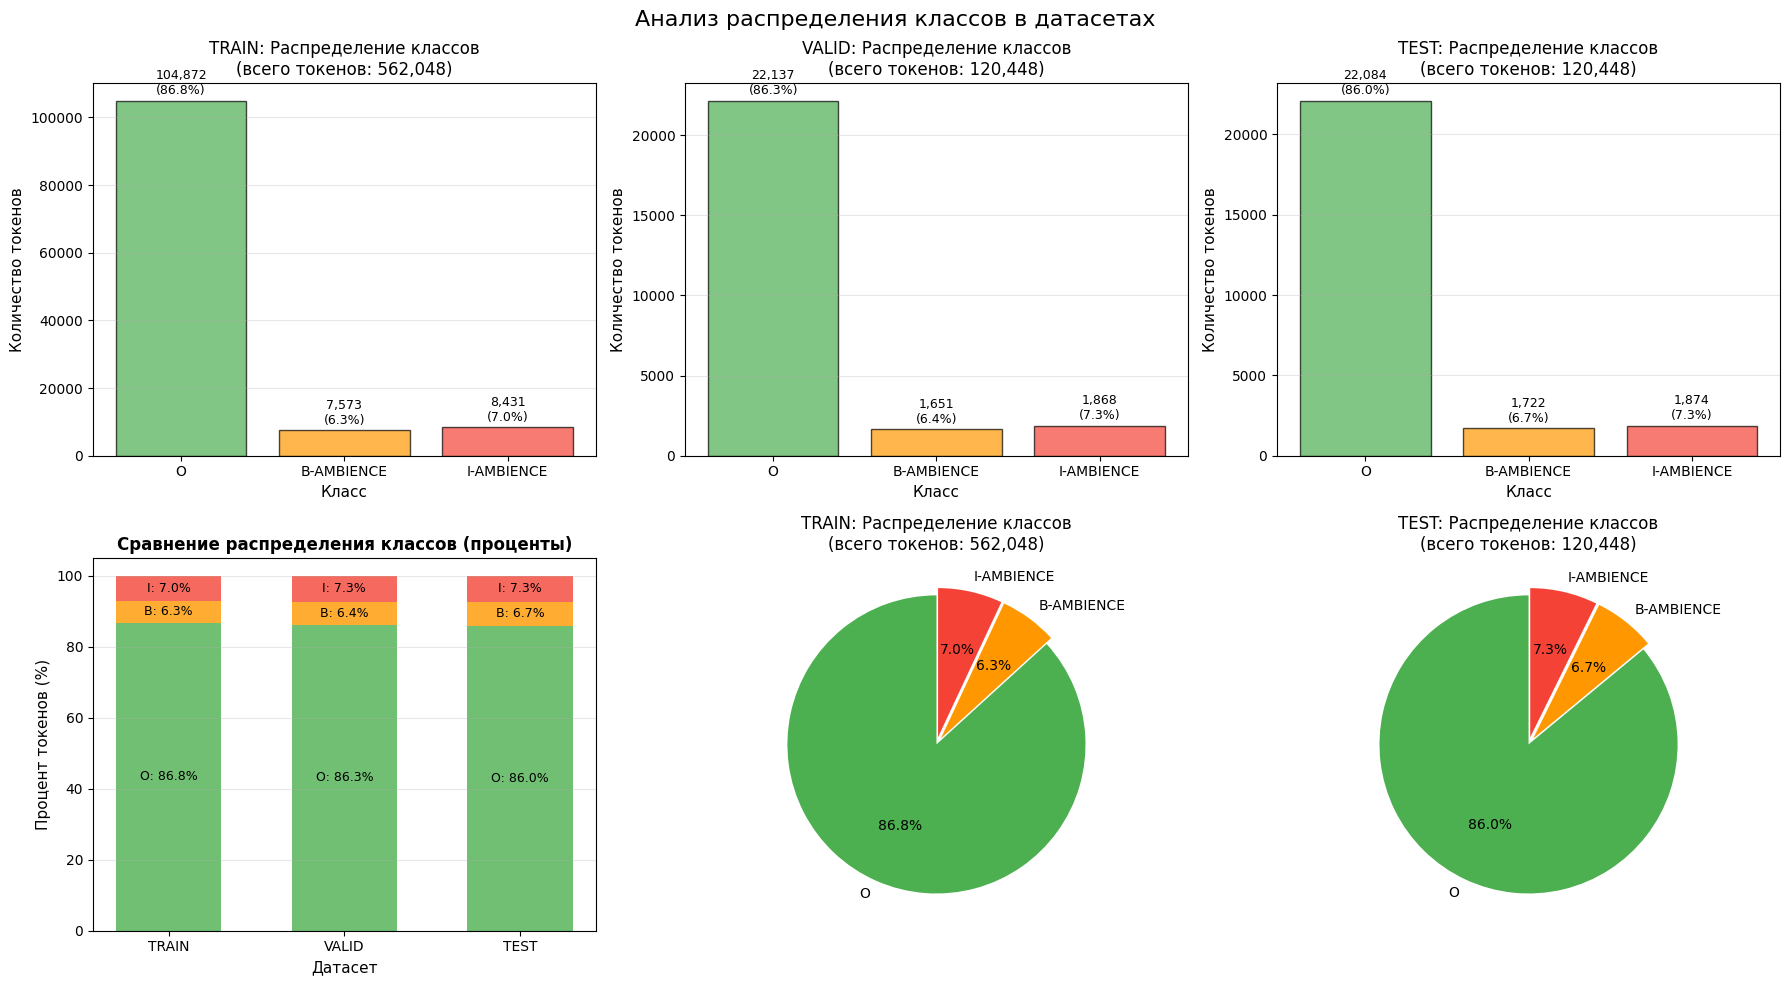

In [27]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

def analyze_class_distribution(data_loader, dataset_name, device='cpu'):
    """Анализирует распределение классов в датасете"""
    
    class_counts = Counter()
    total_tokens = 0
    total_valid_tokens = 0
    
    print(f"\n Анализ {dataset_name}...")
    
    with torch.no_grad():
        for batch in tqdm(data_loader, desc=f"Анализ {dataset_name}"):
            labels = batch['labels'].to(device)
            
            # Считаем только не -100 (не ignored)
            valid_mask = labels != -100
            valid_labels = labels[valid_mask]
            
            total_tokens += labels.numel()
            total_valid_tokens += valid_labels.numel()
            
            # Считаем классы
            for label in valid_labels:
                class_counts[label.item()] += 1
    
    # Преобразуем в удобный формат
    id_to_label = {0: 'O', 1: 'B-AMBIENCE', 2: 'I-AMBIENCE'}
    labels_list = [id_to_label[i] for i in sorted(class_counts.keys())]
    counts_list = [class_counts[i] for i in sorted(class_counts.keys())]
    
    # Вычисляем проценты
    total = sum(counts_list)
    percentages = [100 * c / total for c in counts_list]
    
    print(f"\n   Статистика {dataset_name}:")
    print(f"     Всего токенов: {total_tokens:}")
    print(f"     Валидных токенов: {total_valid_tokens:} ({100*total_valid_tokens/total_tokens:.1f}%)")
    print(f"\n    Распределение классов:")
    for label, count, pct in zip(labels_list, counts_list, percentages):
        print(f"     {label:15} : {count:>10} ({pct:5.2f}%)")
    
    return {
        'name': dataset_name,
        'labels': labels_list,
        'counts': counts_list,
        'percentages': percentages,
        'total_tokens': total_tokens,
        'valid_tokens': total_valid_tokens
    }

def plot_class_distribution(train_stats, val_stats, test_stats):
    """Строит графики распределения классов"""
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Анализ распределения классов в датасетах', fontsize=16)
    
    # Цвета для классов
    colors = {'O': '#4CAF50', 'B-AMBIENCE': '#FF9800', 'I-AMBIENCE': '#F44336'}
    
    # 1. Распределение классов в TRAIN (абсолютные значения)
    ax = axes[0, 0]
    bars = ax.bar(train_stats['labels'], train_stats['counts'], 
                  color=[colors[l] for l in train_stats['labels']],
                  edgecolor='black', alpha=0.7)
    ax.set_xlabel('Класс', fontsize=11)
    ax.set_ylabel('Количество токенов', fontsize=11)
    ax.set_title(f'TRAIN: Распределение классов\n(всего токенов: {train_stats["total_tokens"]:})', 
                 fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    
    for i, (bar, count) in enumerate(zip(bars, train_stats['counts'])):
        label = train_stats['labels'][i]
        pct = train_stats['percentages'][i]
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(train_stats['counts'])*0.01,
                f'{count:}\n({pct:.1f}%)',
                ha='center', va='bottom', fontsize=9)
    
    # 2. Распределение классов в VALID
    ax = axes[0, 1]
    bars = ax.bar(val_stats['labels'], val_stats['counts'], 
                  color=[colors[l] for l in val_stats['labels']],
                  edgecolor='black', alpha=0.7)
    ax.set_xlabel('Класс', fontsize=11)
    ax.set_ylabel('Количество токенов', fontsize=11)
    ax.set_title(f'VALID: Распределение классов\n(всего токенов: {val_stats["total_tokens"]:})', 
                 fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    
    # Добавляем значения на столбцы
    for i, (bar, count) in enumerate(zip(bars, val_stats['counts'])):
        pct = val_stats['percentages'][i]
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(val_stats['counts'])*0.01,
                f'{count:}\n({pct:.1f}%)',
                ha='center', va='bottom', fontsize=9)
    
    # 3. Распределение классов в TEST
    ax = axes[0, 2]
    bars = ax.bar(test_stats['labels'], test_stats['counts'], 
                  color=[colors[l] for l in test_stats['labels']],
                  edgecolor='black', alpha=0.7)
    ax.set_xlabel('Класс', fontsize=11)
    ax.set_ylabel('Количество токенов', fontsize=11)
    ax.set_title(f'TEST: Распределение классов\n(всего токенов: {test_stats["total_tokens"]:})', 
                 fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    
    for i, (bar, count) in enumerate(zip(bars, test_stats['counts'])):
        pct = test_stats['percentages'][i]
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(test_stats['counts'])*0.01,
                f'{count:}\n({pct:.1f}%)',
                ha='center', va='bottom', fontsize=9)
    
    # Сравнение процентов (stacked bars)
    ax = axes[1, 0]
    
    datasets = ['TRAIN', 'VALID', 'TEST']
    o_percents = [train_stats['percentages'][train_stats['labels'].index('O')],
                  val_stats['percentages'][val_stats['labels'].index('O')],
                  test_stats['percentages'][test_stats['labels'].index('O')]]
    b_percents = [train_stats['percentages'][train_stats['labels'].index('B-AMBIENCE')],
                  val_stats['percentages'][val_stats['labels'].index('B-AMBIENCE')],
                  test_stats['percentages'][test_stats['labels'].index('B-AMBIENCE')]]
    i_percents = [train_stats['percentages'][train_stats['labels'].index('I-AMBIENCE')],
                  val_stats['percentages'][val_stats['labels'].index('I-AMBIENCE')],
                  test_stats['percentages'][test_stats['labels'].index('I-AMBIENCE')]]
    
    x = np.arange(len(datasets))
    width = 0.6
    
    ax.bar(x, o_percents, width, label='O', color=colors['O'], alpha=0.8)
    ax.bar(x, b_percents, width, bottom=o_percents, label='B-AMBIENCE', color=colors['B-AMBIENCE'], alpha=0.8)
    ax.bar(x, i_percents, width, bottom=[o+b for o,b in zip(o_percents, b_percents)], 
           label='I-AMBIENCE', color=colors['I-AMBIENCE'], alpha=0.8)
    
    ax.set_xlabel('Датасет', fontsize=11)
    ax.set_ylabel('Процент токенов (%)', fontsize=11)
    ax.set_title('Сравнение распределения классов (проценты)', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(datasets)
    ax.grid(axis='y', alpha=0.3)
    
    # Добавляем проценты на график
    for i, (o, b, ic) in enumerate(zip(o_percents, b_percents, i_percents)):
        ax.text(i, o/2, f'O: {o:.1f}%', ha='center', va='center', fontsize=9)
        ax.text(i, o + b/2, f'B: {b:.1f}%', ha='center', va='center', fontsize=9)
        ax.text(i, o + b + ic/2, f'I: {ic:.1f}%', ha='center', va='center', fontsize=9)
    
    # Pie chart - TRAIN
    ax = axes[1, 1]
    sizes = train_stats['counts']
    labels = train_stats['labels']
    explode = [0.05 if l != 'O' else 0 for l in labels]
    wedges, texts, autotexts = ax.pie(sizes, explode=explode, labels=labels, 
                                        autopct='%1.1f%%', 
                                        colors=[colors[l] for l in labels],
                                        startangle=90,
                                        textprops={'fontsize': 10})
    ax.set_title(f'TRAIN: Распределение классов\n(всего токенов: {train_stats["total_tokens"]:})', 
                 fontsize=12)
    
    # Pie chart - TEST
    ax = axes[1, 2]
    sizes = test_stats['counts']
    labels = test_stats['labels']
    explode = [0.05 if l != 'O' else 0 for l in labels]
    wedges, texts, autotexts = ax.pie(sizes, explode=explode, labels=labels, 
                                        autopct='%1.1f%%', 
                                        colors=[colors[l] for l in labels],
                                        startangle=90,
                                        textprops={'fontsize': 10})
    ax.set_title(f'TEST: Распределение классов\n(всего токенов: {test_stats["total_tokens"]:})', 
                 fontsize=12)
    
    plt.tight_layout()
    plt.show()

train_stats = analyze_class_distribution(train_loader, "TRAIN DATASET", device)
val_stats = analyze_class_distribution(valid_loader, "VALIDATION DATASET", device)
test_stats = analyze_class_distribution(test_loader, "TEST DATASET", device)

plot_class_distribution(train_stats, val_stats, test_stats)

Выравнивание классов нарушит структуру данных, поэтому будет использовать взвешенную функцию ошибки и взвешенную метрику f1, чтобы учитывать дисбаланс классов.

Перейдем к обучению

Версия 1:

In [33]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForTokenClassification
from sklearn.metrics import accuracy_score, f1_score, classification_report
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.utils.class_weight import compute_class_weight

def set_seed(seed=42):
    """Фиксирует все random seeds для воспроизводимости"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)

MODEL_NAME = "DeepPavlov/rubert-base-cased"
NUM_LABELS = 3
EPOCHS = 20
LEARNING_RATE = 2e-5
EARLY_STOPPING_PATIENCE = 7
BATCH_SIZE = 32 

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Устройство: {device}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    ignore_mismatched_sizes=True
).to(device)

print(f"Модель загружена. Параметров: {sum(p.numel() for p in model.parameters()):}")

Устройство: cuda


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                        

Модель загружена. Параметров: 177,265,155


In [47]:
print("Вычисление весов классов для взвешенной функции ошибки...")
all_train_labels = []

for item in tqdm(train_dataset, desc="Сбор меток"):
    labels = item['labels']
    for label in labels:
        if label != -100:  # Игнорируем -100
            all_train_labels.append(label)

# Преобразуем в numpy
all_train_labels = np.array(all_train_labels)

# Получаем уникальные классы (только те, что есть в данных)
unique_labels = np.unique(all_train_labels)
print(f"Уникальные классы в данных: {unique_labels}")

# Проверяем, что все метки от 0 до NUM_LABELS-1
if not np.all(np.isin(unique_labels, np.arange(NUM_LABELS))):
    print(f"Предупреждение: Найдены неожиданные метки: {unique_labels}")

try:
    from sklearn.utils.class_weight import compute_class_weight
    
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=unique_labels,
        y=all_train_labels
    )
    
    # Создаём полный массив весов для всех NUM_LABELS классов
    full_class_weights = np.ones(NUM_LABELS)
    for i, label in enumerate(unique_labels):
        if label < NUM_LABELS:
            full_class_weights[label] = class_weights[i]
    
    class_weights_tensor = torch.tensor(full_class_weights, dtype=torch.float32).to(device)
    
except Exception as e:
    print(f"Ошибка при использовании sklearn: {e}")
    # Альтернативный ручной расчёт
    from collections import Counter
    label_counts = Counter(all_train_labels)
    n_samples = len(all_train_labels)
    n_classes = len(unique_labels)
    
    full_class_weights = np.ones(NUM_LABELS)
    for label, count in label_counts.items():
        if label < NUM_LABELS and label != -100:
            full_class_weights[label] = n_samples / (n_classes * count)
    
    class_weights_tensor = torch.tensor(full_class_weights, dtype=torch.float32).to(device)

print(f"Веса классов: {dict(enumerate(class_weights_tensor.cpu().numpy()))}")

Вычисление весов классов для взвешенной функции ошибки...


Сбор меток: 100%|██████████| 4391/4391 [00:02<00:00, 1463.84it/s]


Уникальные классы в данных: [0 1 2]
Веса классов: {0: np.float32(0.3842017), 1: np.float32(5.320481), 2: np.float32(4.77903)}


In [41]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForTokenClassification
from peft import LoraConfig, get_peft_model, TaskType
from sklearn.metrics import f1_score
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import json

# ========== FOCAL LOSS ==========
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, ignore_index=-100):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ignore_index = ignore_index
    
    def forward(self, inputs, targets):
        batch_size, seq_len, num_classes = inputs.shape
        logits = inputs.permute(0, 2, 1)
        ce_loss = F.cross_entropy(
            logits, targets,
            weight=self.alpha,
            ignore_index=self.ignore_index,
            reduction='none'
        )
        probs = F.softmax(inputs, dim=-1)
        safe_targets = targets.clone()
        safe_targets[safe_targets == self.ignore_index] = 0
        targets_one_hot = torch.zeros(
            batch_size, seq_len, num_classes,
            device=inputs.device, dtype=inputs.dtype
        )
        targets_one_hot.scatter_(-1, safe_targets.unsqueeze(-1), 1.0)
        mask = (targets != self.ignore_index).unsqueeze(-1).float()
        targets_one_hot = targets_one_hot * mask
        pt = (probs * targets_one_hot).sum(dim=-1)
        pt = torch.clamp(pt, min=1e-8, max=1.0 - 1e-8)
        focal_weight = (1 - pt) ** self.gamma
        focal_loss = focal_weight * ce_loss
        valid_mask = targets != self.ignore_index
        if valid_mask.sum() > 0:
            return focal_loss[valid_mask].sum() / valid_mask.sum()
        else:
            return torch.tensor(0.0, device=inputs.device, requires_grad=True)

# ========== ПАРАМЕТРЫ ==========
MODEL_NAME = "DeepPavlov/rubert-base-cased"
NUM_LABELS = 3
EPOCHS = 50
EARLY_STOPPING_PATIENCE = 5
BATCH_SIZE = 16
FOCAL_GAMMA = 2.0

LEARNING_RATE = 5e-5  # было 3e-4, уменьшаем в 6 раз
LORA_R = 4  # было 16, уменьшаем (меньше параметров)
LORA_ALPHA = 8  # alpha = 2 * r
LORA_DROPOUT = 0.3  # увеличиваем dropout
WEIGHT_DECAY = 0.05  # увеличиваем регуляризацию
LORA_TARGET_MODULES = ["query", "value", "key", "output.dense"]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Устройство: {device}")

# ========== ЗАГРУЗКА МОДЕЛИ ==========
print(f"\nЗагрузка модели {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    ignore_mismatched_sizes=True
).to(device)

# ========== НАСТРОЙКА LORA ==========
lora_config = LoraConfig(
    task_type=TaskType.TOKEN_CLS,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=LORA_TARGET_MODULES,
    bias="none",
    modules_to_save=["classifier"]
)

model = get_peft_model(model, lora_config)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n СТАТИСТИКА ПАРАМЕТРОВ:")
print(f"  Всего параметров: {total_params:}")
print(f"  Обучаемых (LoRA + classifier): {trainable_params:}")
print(f"  Процент обучаемых: {100*trainable_params/total_params:.3f}%")

print(f"\nВеса классов: {class_weights_tensor.cpu().numpy()}")

# ========== ФУНКЦИИ ДЛЯ МЕТРИК ==========
def compute_detailed_metrics(all_labels, all_predictions, num_labels=3):
    """Вычисляет метрики с поддержкой weighted и per-class"""
    metrics = {}
    total_support = 0
    
    for class_id in range(num_labels):
        tp = sum(1 for p, l in zip(all_predictions, all_labels) if p == class_id and l == class_id)
        fp = sum(1 for p, l in zip(all_predictions, all_labels) if p == class_id and l != class_id)
        fn = sum(1 for p, l in zip(all_predictions, all_labels) if p != class_id and l == class_id)
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        support = sum(1 for l in all_labels if l == class_id)
        
        metrics[class_id] = {
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'support': support
        }
        total_support += support
    
    # Вычисляем WEIGHTED F1 (по поддержке каждого класса)
    weighted_f1 = sum(metrics[c]['f1'] * metrics[c]['support'] for c in range(num_labels)) / total_support if total_support > 0 else 0.0
    
    return metrics, weighted_f1

def train_epoch_with_metrics(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_predictions = []
    all_labels = []
    progress_bar = tqdm(dataloader, desc="Training")

    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

        predictions = torch.argmax(logits, dim=2)
        for pred_seq, label_seq in zip(predictions, labels):
            for pred, label in zip(pred_seq, label_seq):
                if label != -100:
                    all_predictions.append(pred.item())
                    all_labels.append(label.item())

        progress_bar.set_postfix({'loss': loss.item()})

    avg_loss = total_loss / len(dataloader)
    metrics, weighted_f1 = compute_detailed_metrics(all_labels, all_predictions, NUM_LABELS)
    return avg_loss, metrics, weighted_f1

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Validation"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            
            loss = criterion(logits, labels)
            total_loss += loss.item()

            predictions = torch.argmax(logits, dim=2)

            for pred_seq, label_seq in zip(predictions, labels):
                for pred, label in zip(pred_seq, label_seq):
                    if label != -100:
                        all_predictions.append(pred.item())
                        all_labels.append(label.item())

    avg_loss = total_loss / len(dataloader)
    metrics, weighted_f1 = compute_detailed_metrics(all_labels, all_predictions, NUM_LABELS)
    return avg_loss, metrics, weighted_f1

# ========== ОБУЧЕНИЕ ==========
criterion = FocalLoss(alpha=class_weights_tensor, gamma=FOCAL_GAMMA, ignore_index=-100)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

from transformers import get_linear_schedule_with_warmup
total_steps = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)
scheduler = get_linear_schedule_with_warmup(
    optimizer, 
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

OUTPUT_DIR = "./model_lora_rubert_base_best"
os.makedirs(OUTPUT_DIR, exist_ok=True)

history = {
    'epoch': [],
    'train_loss': [], 'val_loss': [],
    'train_weighted_f1': [], 'val_weighted_f1': [],
    'train_f1_class0': [], 'val_f1_class0': [],
    'train_f1_class1': [], 'val_f1_class1': [],
    'train_f1_class2': [], 'val_f1_class2': []
}

best_val_f1 = 0
best_epoch = 0
patience_counter = 0

print(f"  Модель: {MODEL_NAME}")
print(f"  LoRA: r={LORA_R}, alpha={LORA_ALPHA}, dropout={LORA_DROPOUT}")
print(f"  Обучаемых параметров: {trainable_params:}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Weight decay: {WEIGHT_DECAY}")

for epoch in range(EPOCHS):
    print(f"# ЭПОХА {epoch + 1}/{EPOCHS}")
    
    train_loss, train_metrics, train_weighted_f1 = train_epoch_with_metrics(model, train_loader, optimizer, criterion, device)
    val_loss, val_metrics, val_weighted_f1 = evaluate(model, valid_loader, criterion, device)
    
    scheduler.step()
    
    # Сохраняем в историю
    history['epoch'].append(epoch + 1)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_weighted_f1'].append(train_weighted_f1)
    history['val_weighted_f1'].append(val_weighted_f1)
    
    class_names = ['O', 'B-AMBIENCE', 'I-AMBIENCE']
    for c in range(NUM_LABELS):
        history[f'train_f1_class{c}'].append(train_metrics[c]['f1'])
        history[f'val_f1_class{c}'].append(val_metrics[c]['f1'])
    
    # ВЫВОД МЕТРИК
    print(f"\nLOSS: Train={train_loss:.4f}, Val={val_loss:.4f}, Gap={val_loss-train_loss:.4f}")
    print(f"WEIGHTED F1: Train={train_weighted_f1:.4f}, Val={val_weighted_f1:.4f}")
    
    print(f"\nPer-class TRAIN F1:")
    for c in range(NUM_LABELS):
        print(f"  {class_names[c]}: {train_metrics[c]['f1']:.4f} (P={train_metrics[c]['precision']:.4f}, R={train_metrics[c]['recall']:.4f})")
    
    print(f"\nPer-class VALIDATION F1:")
    for c in range(NUM_LABELS):
        print(f"  {class_names[c]}: {val_metrics[c]['f1']:.4f} (P={val_metrics[c]['precision']:.4f}, R={val_metrics[c]['recall']:.4f})")
    
    # Сохраняем лучшую модель по weighted F1
    if val_weighted_f1 > best_val_f1:
        best_val_f1 = val_weighted_f1
        best_epoch = epoch + 1
        patience_counter = 0
        model.save_pretrained(OUTPUT_DIR)
        tokenizer.save_pretrained(OUTPUT_DIR)
        
        best_info = {
            'best_epoch': best_epoch,
            'best_val_weighted_f1': best_val_f1,
            'best_val_loss': val_loss,
            'focal_gamma': FOCAL_GAMMA,
            'learning_rate': LEARNING_RATE,
            'lora_r': LORA_R,
            'lora_alpha': LORA_ALPHA,
            'lora_dropout': LORA_DROPOUT
        }
        with open(os.path.join(OUTPUT_DIR, 'best_model_info.json'), 'w') as f:
            json.dump(best_info, f, indent=2)
        
        print(f"\n ЛУЧШАЯ МОДЕЛЬ сохранена! (Weighted F1={val_weighted_f1:.4f})")
    else:
        patience_counter += 1
        print(f"\n Weighted F1 не улучшился ({patience_counter}/{EARLY_STOPPING_PATIENCE})")
    
    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print(f"\n EARLY STOPPING! Лучший результат: {best_val_f1:.4f} на эпохе {best_epoch}")
        break

# Сохраняем историю
history_df = pd.DataFrame(history)
history_df.to_csv(os.path.join(OUTPUT_DIR, 'training_history.csv'), index=False)

print(f"\n Обучение завершено!")
print(f" Результаты сохранены в: {OUTPUT_DIR}")

Устройство: cuda

Загрузка модели DeepPavlov/rubert-base-cased...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                        


 СТАТИСТИКА ПАРАМЕТРОВ:
  Всего параметров: 177,746,694
  Обучаемых (LoRA + classifier): 481,539
  Процент обучаемых: 0.271%

Веса классов: [0.3842017 5.320481  4.77903  ]
  Модель: DeepPavlov/rubert-base-cased
  LoRA: r=4, alpha=8, dropout=0.3
  Обучаемых параметров: 481,539
  Learning rate: 5e-05
  Weight decay: 0.05
# ЭПОХА 1/50


Validation: 100%|██████████| 30/30 [00:10<00:00,  2.74it/s]


...


LOSS: Train=0.2644, Val=0.2553, Gap=-0.0091
WEIGHTED F1: Train=0.7100, Val=0.7167

Per-class TRAIN F1:
  O: 0.7631 (P=0.9678, R=0.6299)
  B-AMBIENCE: 0.4134 (P=0.2778, R=0.8083)
  I-AMBIENCE: 0.3167 (P=0.2020, R=0.7328)

Per-class VALIDATION F1:
  O: 0.7697 (P=0.9695, R=0.6382)
  B-AMBIENCE: 0.4450 (P=0.3045, R=0.8262)
  I-AMBIENCE: 0.3292 (P=0.2112, R=0.7468)

 ЛУЧШАЯ МОДЕЛЬ сохранена! (Weighted F1=0.7167)
# ЭПОХА 49/50


Validation: 100%|██████████| 30/30 [00:10<00:00,  2.78it/s]



LOSS: Train=0.2617, Val=0.2523, Gap=-0.0094
WEIGHTED F1: Train=0.7145, Val=0.7109

Per-class TRAIN F1:
  O: 0.7679 (P=0.9659, R=0.6373)
  B-AMBIENCE: 0.4168 (P=0.2814, R=0.8036)
  I-AMBIENCE: 0.3168 (P=0.2028, R=0.7229)

Per-class VALIDATION F1:
  O: 0.7632 (P=0.9712, R=0.6286)
  B-AMBIENCE: 0.4426 (P=0.3014, R=0.8322)
  I-AMBIENCE: 0.3276 (P=0.2090, R=0.7575)

 Weighted F1 не улучшился (1/5)
# ЭПОХА 50/50


Validation: 100%|██████████| 30/30 [00:10<00:00,  2.76it/s]


LOSS: Train=0.2573, Val=0.2491, Gap=-0.0081
WEIGHTED F1: Train=0.7170, Val=0.7158

Per-class TRAIN F1:
  O: 0.7699 (P=0.9678, R=0.6392)
  B-AMBIENCE: 0.4244 (P=0.2872, R=0.8128)
  I-AMBIENCE: 0.3218 (P=0.2058, R=0.7368)

Per-class VALIDATION F1:
  O: 0.7681 (P=0.9715, R=0.6352)
  B-AMBIENCE: 0.4496 (P=0.3076, R=0.8353)
  I-AMBIENCE: 0.3315 (P=0.2120, R=0.7602)

 Weighted F1 не улучшился (2/5)

 Обучение завершено!
 Результаты сохранены в: ./model_lora_rubert_base_best


📊 Данные загружены. Всего эпох: 50
🏆 Лучшая эпоха: 48, Weighted F1: 0.7167


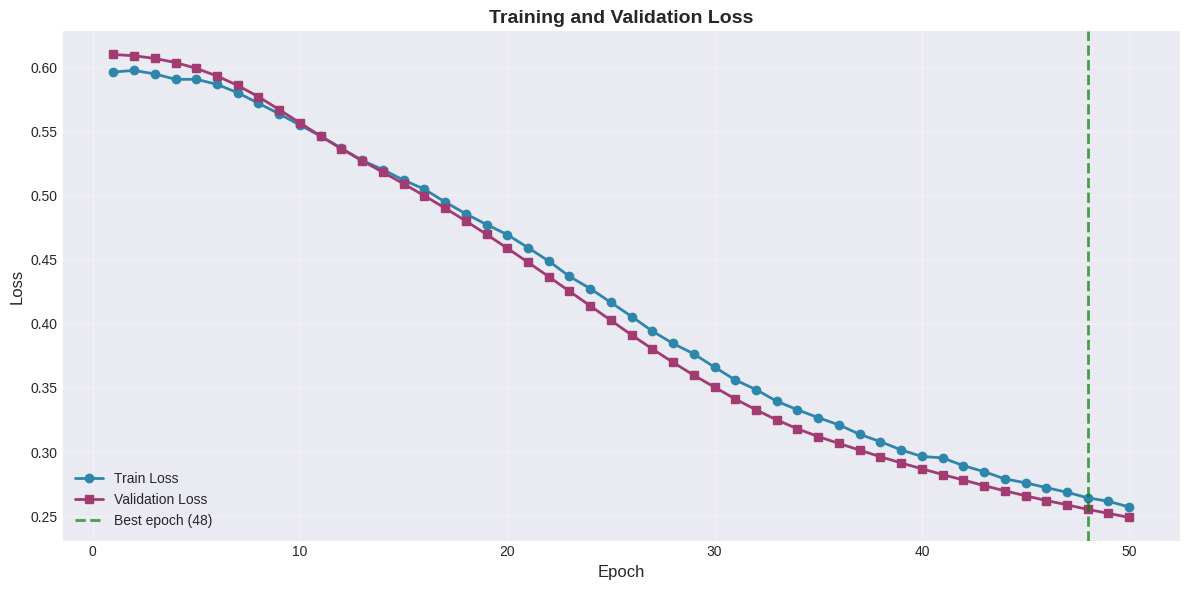

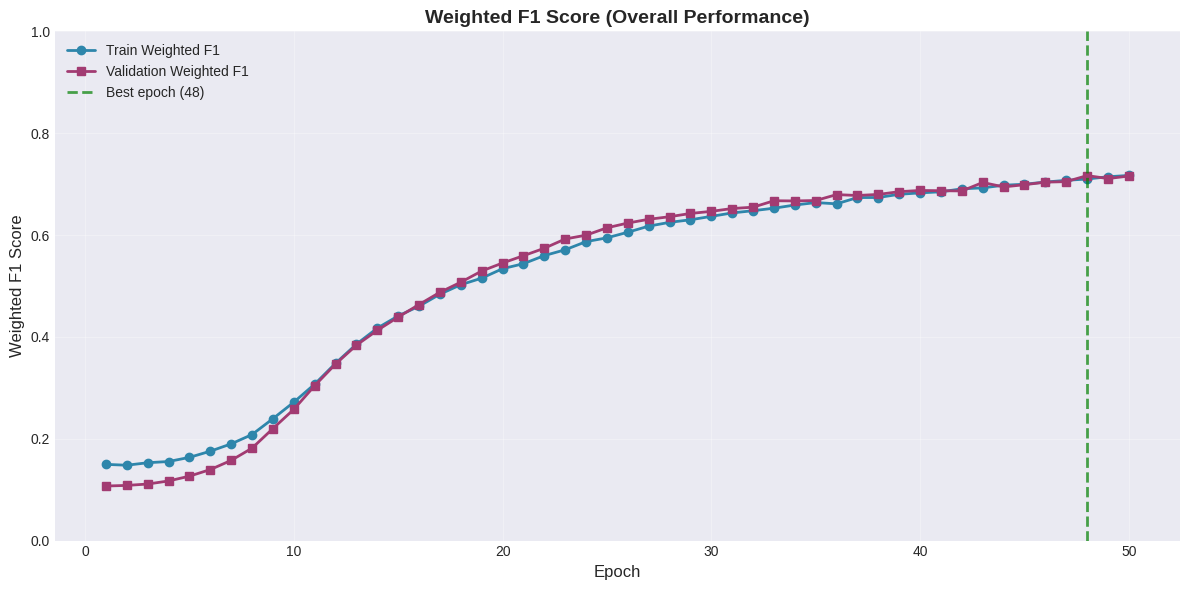

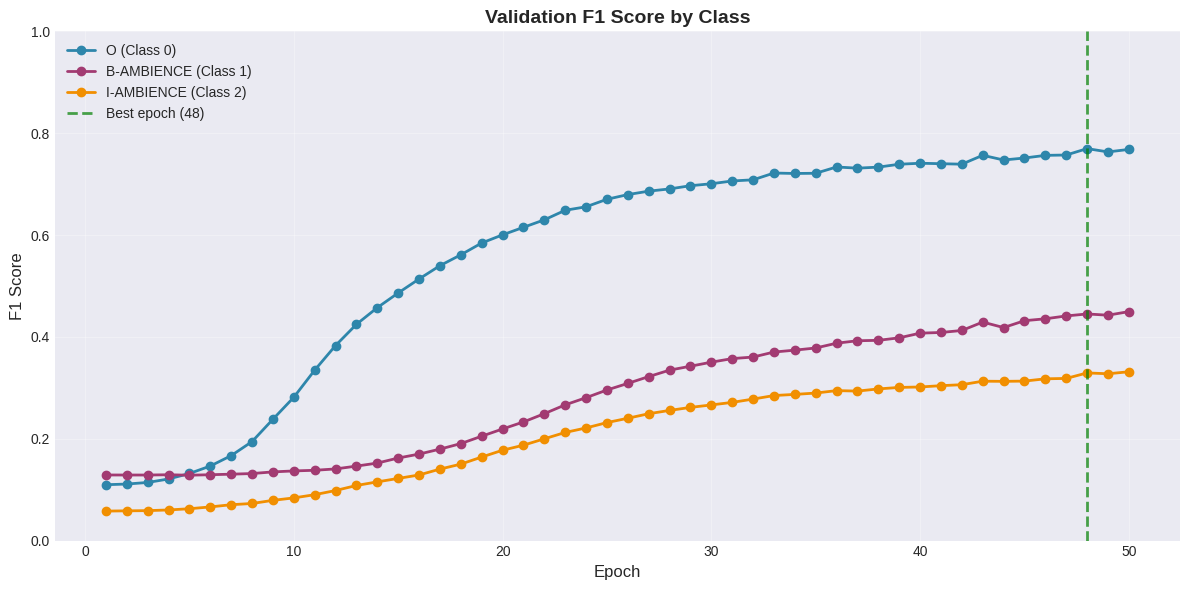

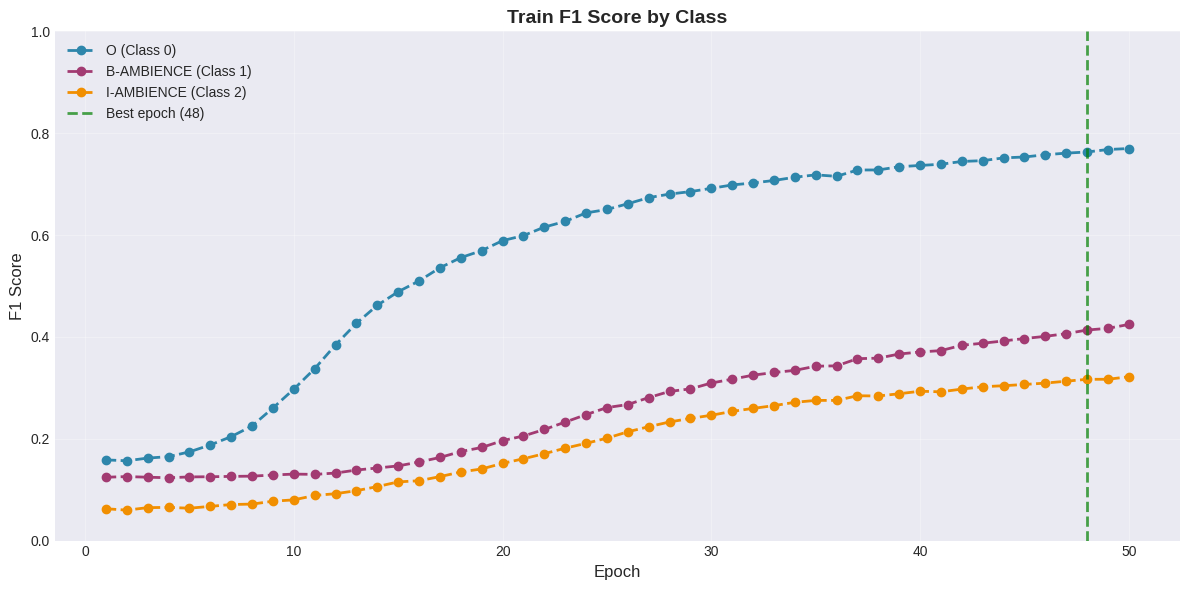

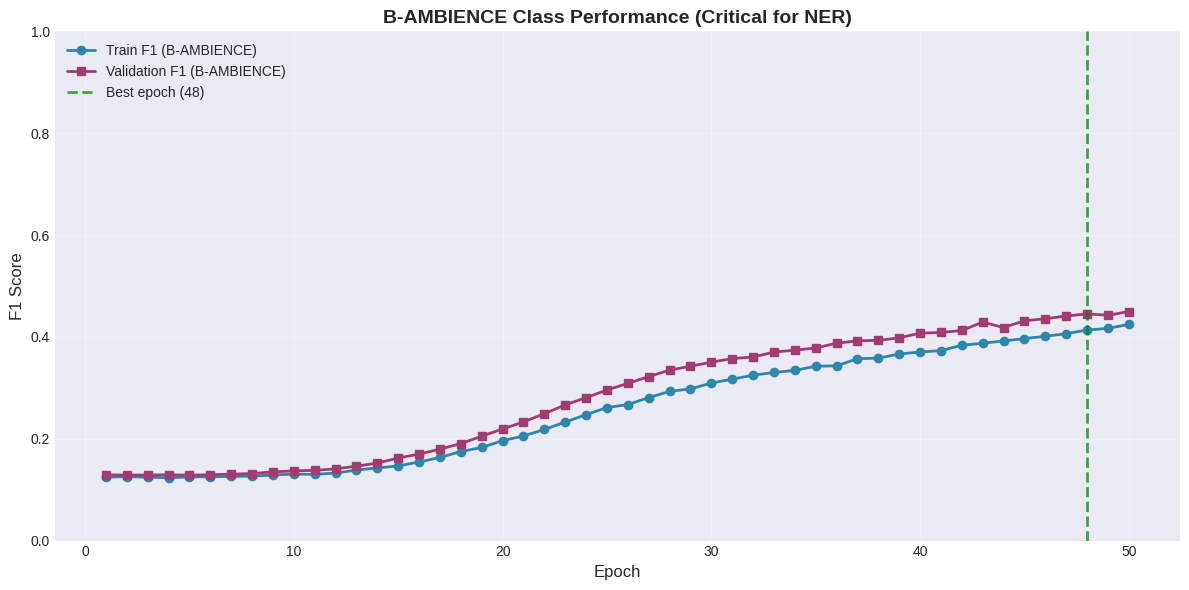

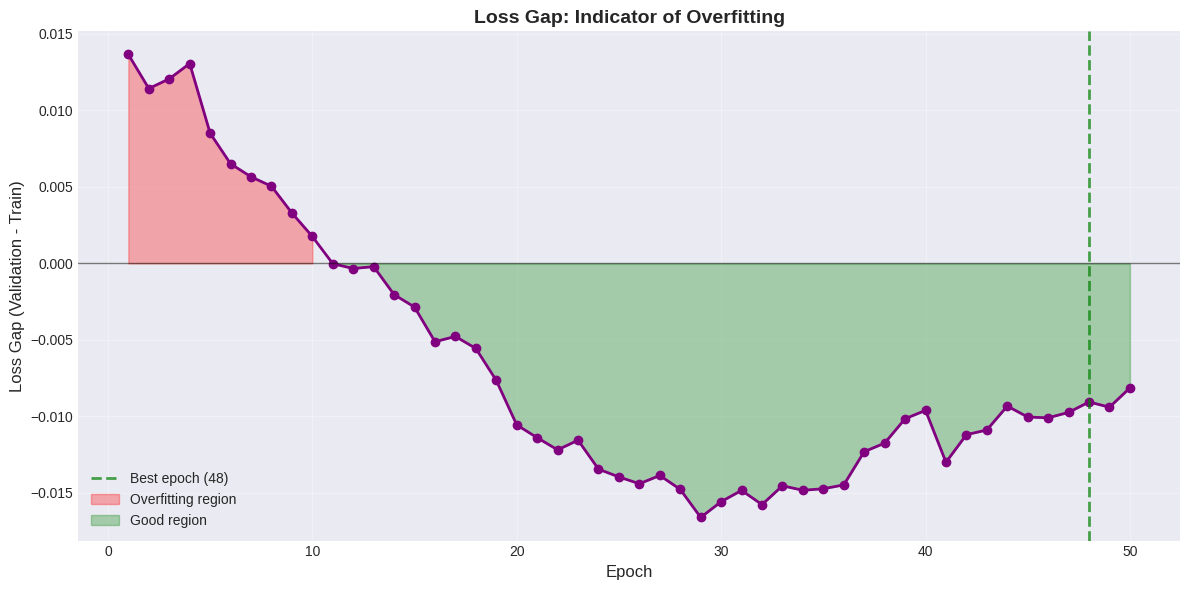

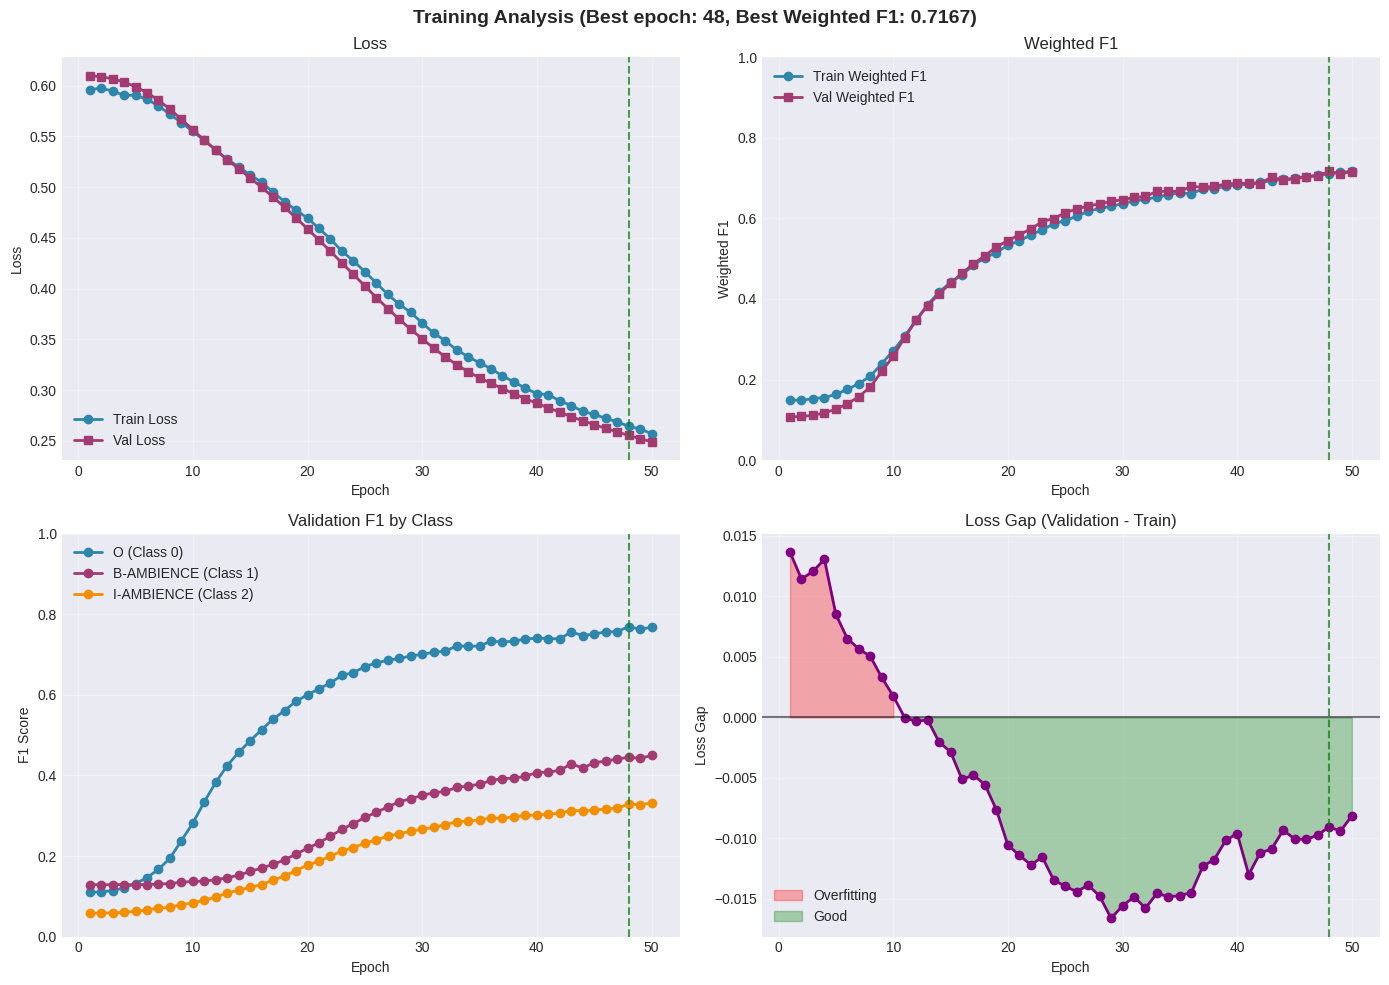


✅ Все графики сохранены в ./model_lora_rubert_base_best


In [44]:
# ========== ГРАФИКИ ПО РЕЗУЛЬТАТАМ ОБУЧЕНИЯ ==========
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
import os

OUTPUT_DIR = "./model_lora_rubert_base_best"

# Загружаем данные
history_df = pd.read_csv(os.path.join(OUTPUT_DIR, 'training_history.csv'))
history = history_df.to_dict(orient='list')

# Загружаем информацию о лучшей модели
with open(os.path.join(OUTPUT_DIR, 'best_model_info.json'), 'r') as f:
    best_info = json.load(f)

best_epoch = best_info['best_epoch']
best_val_f1 = best_info['best_val_weighted_f1']

class_names = ['O (Class 0)', 'B-AMBIENCE (Class 1)', 'I-AMBIENCE (Class 2)']

# Стиль графиков
plt.style.use('seaborn-v0_8-darkgrid')
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E']

print(f"📊 Данные загружены. Всего эпох: {len(history['epoch'])}")
print(f"🏆 Лучшая эпоха: {best_epoch}, Weighted F1: {best_val_f1:.4f}")

# ========== ГРАФИК 1: LOSS ==========
fig1, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(history['epoch'], history['train_loss'], label='Train Loss', marker='o', linewidth=2, color=colors[0], markersize=6)
ax1.plot(history['epoch'], history['val_loss'], label='Validation Loss', marker='s', linewidth=2, color=colors[1], markersize=6)
ax1.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, linewidth=2, label=f'Best epoch ({best_epoch})')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'loss_curve.png'), dpi=150, bbox_inches='tight')
plt.show()

# ========== ГРАФИК 2: WEIGHTED F1 ==========
fig2, ax2 = plt.subplots(figsize=(12, 6))
ax2.plot(history['epoch'], history['train_weighted_f1'], label='Train Weighted F1', marker='o', linewidth=2, color=colors[0], markersize=6)
ax2.plot(history['epoch'], history['val_weighted_f1'], label='Validation Weighted F1', marker='s', linewidth=2, color=colors[1], markersize=6)
ax2.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, linewidth=2, label=f'Best epoch ({best_epoch})')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Weighted F1 Score', fontsize=12)
ax2.set_title('Weighted F1 Score (Overall Performance)', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 1.0])
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'weighted_f1_curve.png'), dpi=150, bbox_inches='tight')
plt.show()

# ========== ГРАФИК 3: PER-CLASS F1 (VALIDATION) ==========
fig3, ax3 = plt.subplots(figsize=(12, 6))
for c in range(3):
    ax3.plot(history['epoch'], history[f'val_f1_class{c}'], label=class_names[c], marker='o', linewidth=2, color=colors[c], markersize=6)
ax3.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, linewidth=2, label=f'Best epoch ({best_epoch})')
ax3.set_xlabel('Epoch', fontsize=12)
ax3.set_ylabel('F1 Score', fontsize=12)
ax3.set_title('Validation F1 Score by Class', fontsize=14, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.set_ylim([0, 1.0])
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'per_class_f1_validation.png'), dpi=150, bbox_inches='tight')
plt.show()

# ========== ГРАФИК 4: PER-CLASS F1 (TRAIN) ==========
fig4, ax4 = plt.subplots(figsize=(12, 6))
for c in range(3):
    ax4.plot(history['epoch'], history[f'train_f1_class{c}'], label=class_names[c], marker='o', linewidth=2, color=colors[c], markersize=6, linestyle='--')
ax4.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, linewidth=2, label=f'Best epoch ({best_epoch})')
ax4.set_xlabel('Epoch', fontsize=12)
ax4.set_ylabel('F1 Score', fontsize=12)
ax4.set_title('Train F1 Score by Class', fontsize=14, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)
ax4.set_ylim([0, 1.0])
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'per_class_f1_train.png'), dpi=150, bbox_inches='tight')
plt.show()

# ========== ГРАФИК 5: TRAIN vs VALIDATION F1 (CLASS 1 - B-AMBIENCE) ==========
fig5, ax5 = plt.subplots(figsize=(12, 6))
ax5.plot(history['epoch'], history['train_f1_class1'], label='Train F1 (B-AMBIENCE)', marker='o', linewidth=2, color=colors[0], markersize=6)
ax5.plot(history['epoch'], history['val_f1_class1'], label='Validation F1 (B-AMBIENCE)', marker='s', linewidth=2, color=colors[1], markersize=6)
ax5.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, linewidth=2, label=f'Best epoch ({best_epoch})')
ax5.set_xlabel('Epoch', fontsize=12)
ax5.set_ylabel('F1 Score', fontsize=12)
ax5.set_title('B-AMBIENCE Class Performance (Critical for NER)', fontsize=14, fontweight='bold')
ax5.legend(fontsize=10)
ax5.grid(True, alpha=0.3)
ax5.set_ylim([0, 1.0])
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'b_ambience_f1.png'), dpi=150, bbox_inches='tight')
plt.show()

# ========== ГРАФИК 6: LOSS GAP (Overfitting Indicator) ==========
fig6, ax6 = plt.subplots(figsize=(12, 6))
loss_gap = np.array(history['val_loss']) - np.array(history['train_loss'])
ax6.plot(history['epoch'], loss_gap, marker='o', linewidth=2, color='purple', markersize=6)
ax6.axhline(y=0, color='black', linestyle='-', alpha=0.5, linewidth=1)
ax6.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, linewidth=2, label=f'Best epoch ({best_epoch})')
ax6.fill_between(history['epoch'], 0, loss_gap, where=(loss_gap > 0), color='red', alpha=0.3, label='Overfitting region')
ax6.fill_between(history['epoch'], 0, loss_gap, where=(loss_gap <= 0), color='green', alpha=0.3, label='Good region')
ax6.set_xlabel('Epoch', fontsize=12)
ax6.set_ylabel('Loss Gap (Validation - Train)', fontsize=12)
ax6.set_title('Loss Gap: Indicator of Overfitting', fontsize=14, fontweight='bold')
ax6.legend(fontsize=10)
ax6.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'loss_gap.png'), dpi=150, bbox_inches='tight')
plt.show()

# ========== ГРАФИК 7: СВОДНЫЙ (2x2) ==========
fig7, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss
axes[0,0].plot(history['epoch'], history['train_loss'], label='Train Loss', marker='o', linewidth=2, color=colors[0])
axes[0,0].plot(history['epoch'], history['val_loss'], label='Val Loss', marker='s', linewidth=2, color=colors[1])
axes[0,0].axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7)
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Loss')
axes[0,0].set_title('Loss')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Weighted F1
axes[0,1].plot(history['epoch'], history['train_weighted_f1'], label='Train Weighted F1', marker='o', linewidth=2, color=colors[0])
axes[0,1].plot(history['epoch'], history['val_weighted_f1'], label='Val Weighted F1', marker='s', linewidth=2, color=colors[1])
axes[0,1].axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7)
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Weighted F1')
axes[0,1].set_title('Weighted F1')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)
axes[0,1].set_ylim([0, 1.0])

# Per-class Validation F1
for c in range(3):
    axes[1,0].plot(history['epoch'], history[f'val_f1_class{c}'], label=class_names[c], marker='o', linewidth=2, color=colors[c])
axes[1,0].axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7)
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('F1 Score')
axes[1,0].set_title('Validation F1 by Class')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)
axes[1,0].set_ylim([0, 1.0])

# Loss Gap
axes[1,1].plot(history['epoch'], loss_gap, marker='o', linewidth=2, color='purple')
axes[1,1].axhline(y=0, color='black', linestyle='-', alpha=0.5)
axes[1,1].axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7)
axes[1,1].fill_between(history['epoch'], 0, loss_gap, where=(loss_gap > 0), color='red', alpha=0.3, label='Overfitting')
axes[1,1].fill_between(history['epoch'], 0, loss_gap, where=(loss_gap <= 0), color='green', alpha=0.3, label='Good')
axes[1,1].set_xlabel('Epoch')
axes[1,1].set_ylabel('Loss Gap')
axes[1,1].set_title('Loss Gap (Validation - Train)')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.suptitle(f'Training Analysis (Best epoch: {best_epoch}, Best Weighted F1: {best_val_f1:.4f})', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'combined_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Все графики сохранены в {OUTPUT_DIR}")

In [51]:
# ========== ТЕСТИРОВАНИЕ МОДЕЛИ ==========
import os
import torch
import numpy as np
import pandas as pd
import json
from transformers import AutoTokenizer, AutoModelForTokenClassification
from peft import PeftModel
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix

# ========== НАСТРОЙКИ ==========
MODEL_DIR = "./model_lora_rubert_base_best"  # директория с лучшей моделью
NUM_LABELS = 3
BATCH_SIZE = 16
FOCAL_GAMMA = 2.0

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Устройство: {device}")

# ========== ЗАГРУЗКА МОДЕЛИ ==========
print(f"\nЗагрузка модели из {MODEL_DIR}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)

# Загружаем модель (как PeftModel)
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_DIR,
    trust_remote_code=True
).to(device)

model.eval()
print("Модель загружена")

# ========== ЗАГРУЗКА ИНФОРМАЦИИ О ЛУЧШЕЙ МОДЕЛИ ==========
try:
    with open(os.path.join(MODEL_DIR, 'best_model_info.json'), 'r') as f:
        best_info = json.load(f)
    print(f"\nИнформация о модели:")
    print(f"  Лучшая эпоха: {best_info.get('best_epoch', 'N/A')}")
    print(f"  Лучший Weighted F1: {best_info.get('best_val_weighted_f1', 'N/A'):.4f}")
except:
    print("  Файл best_model_info.json не найден")

# ========== ФУНКЦИЯ ДЛЯ ТЕСТИРОВАНИЯ ==========
def compute_detailed_metrics(all_labels, all_predictions, num_labels=3):
    """Вычисляет метрики для каждого класса"""
    metrics = {}
    total_support = 0
    
    for class_id in range(num_labels):
        tp = sum(1 for p, l in zip(all_predictions, all_labels) if p == class_id and l == class_id)
        fp = sum(1 for p, l in zip(all_predictions, all_labels) if p == class_id and l != class_id)
        fn = sum(1 for p, l in zip(all_predictions, all_labels) if p != class_id and l == class_id)
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        support = sum(1 for l in all_labels if l == class_id)
        
        metrics[class_id] = {
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'support': support
        }
        total_support += support
    
    weighted_f1 = sum(metrics[c]['f1'] * metrics[c]['support'] for c in range(num_labels)) / total_support if total_support > 0 else 0.0
    macro_f1 = sum(metrics[c]['f1'] for c in range(num_labels)) / num_labels
    
    return metrics, weighted_f1, macro_f1

def test_model(model, dataloader, device):
    """Тестирует модель на test выборке"""
    model.eval()
    all_predictions = []
    all_labels = []
    all_loss = 0
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Testing"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            predictions = torch.argmax(logits, dim=2)
            
            for pred_seq, label_seq in zip(predictions, labels):
                for pred, label in zip(pred_seq, label_seq):
                    if label != -100:
                        all_predictions.append(pred.item())
                        all_labels.append(label.item())
    
    metrics, weighted_f1, macro_f1 = compute_detailed_metrics(all_labels, all_predictions, NUM_LABELS)
    
    return metrics, weighted_f1, macro_f1, all_predictions, all_labels

# ========== ТЕСТИРОВАНИЕ ==========
print(f"\n{'='*60}")
print(f"ТЕСТИРОВАНИЕ МОДЕЛИ")
print(f"{'='*60}")

test_metrics, test_weighted_f1, test_macro_f1, test_preds, test_true = test_model(model, test_loader, device)

# Вывод результатов
class_names = ['O (Класс 0)', 'B-AMBIENCE (Класс 1)', 'I-AMBIENCE (Класс 2)']

print(f"\n{'='*50}")
print(f"ОБЩИЕ МЕТРИКИ")
print(f"{'='*50}")
print(f"  Weighted F1: {test_weighted_f1:.4f}")
print(f"  Macro F1: {test_macro_f1:.4f}")
print(f"{'='*50}\n")

print(f"ПОКЛАССОВЫЕ МЕТРИКИ:")
print(f"{'='*70}")
print(f"{'Класс':<25} {'Precision':>12} {'Recall':>12} {'F1':>12} {'Support':>12}")
print(f"{'-'*70}")

for c in range(NUM_LABELS):
    m = test_metrics[c]
    print(f"{class_names[c]:<25} {m['precision']:>12.4f} {m['recall']:>12.4f} {m['f1']:>12.4f} {m['support']:>12}")

print(f"{'='*70}\n")

# Classification report
print("CLASSIFICATION REPORT (через sklearn):")
print(f"{'='*50}")
target_names = ['O', 'B-AMBIENCE', 'I-AMBIENCE']
report = classification_report(test_true, test_preds, target_names=target_names, zero_division=0)
print(report)

# Сохраняем результаты
test_results = {
    'test_weighted_f1': float(test_weighted_f1),
    'test_macro_f1': float(test_macro_f1),
    'per_class': {}
}
for c in range(NUM_LABELS):
    test_results['per_class'][class_names[c]] = {
        'precision': float(test_metrics[c]['precision']),
        'recall': float(test_metrics[c]['recall']),
        'f1': float(test_metrics[c]['f1']),
        'support': int(test_metrics[c]['support'])
    }

with open(os.path.join(MODEL_DIR, 'test_results.json'), 'w') as f:
    json.dump(test_results, f, indent=2)

print(f"\n✅ Результаты тестирования сохранены в: {MODEL_DIR}/test_results.json")

Устройство: cuda

Загрузка модели из ./model_lora_rubert_base_best...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                        

Loading weights: 0it [00:00, ?it/s]

BertForTokenClassification LOAD REPORT from: ./model_lora_rubert_base_best
Key                                                                                       | Status     | 
------------------------------------------------------------------------------------------+------------+-
base_model.model.bert.encoder.layer.{0...11}.attention.self.query.lora_B.default.weight   | UNEXPECTED | 
base_model.model.bert.encoder.layer.{0...11}.attention.self.key.lora_B.default.weight     | UNEXPECTED | 
base_model.model.bert.encoder.layer.{0...11}.attention.self.value.lora_A.default.weight   | UNEXPECTED | 
base_model.model.bert.encoder.layer.{0...11}.attention.output.dense.lora_B.default.weight | UNEXPECTED | 
base_model.model.bert.encoder.layer.{0...11}.attention.self.value.lora_B.default.weight   | UNEXPECTED | 
base_model.model.bert.encoder.layer.{0...11}.output.dense.lora_A.default.weight           | UNEXPECTED | 
base_model.model.bert.encoder.layer.{0...11}.attention.output.dense.lora_A.de

Модель загружена

Информация о модели:
  Лучшая эпоха: 48
  Лучший Weighted F1: 0.7167

ТЕСТИРОВАНИЕ МОДЕЛИ


Testing: 100%|██████████| 30/30 [00:11<00:00,  2.65it/s]


ОБЩИЕ МЕТРИКИ
  Weighted F1: 0.7162
  Macro F1: 0.3005

ПОКЛАССОВЫЕ МЕТРИКИ:
Класс                        Precision       Recall           F1      Support
----------------------------------------------------------------------
O (Класс 0)                     0.8607       0.7958       0.8270        22084
B-AMBIENCE (Класс 1)            0.0494       0.1510       0.0745         1722
I-AMBIENCE (Класс 2)            0.0000       0.0000       0.0000         1874

CLASSIFICATION REPORT (через sklearn):
              precision    recall  f1-score   support

           O       0.86      0.80      0.83     22084
  B-AMBIENCE       0.05      0.15      0.07      1722
  I-AMBIENCE       0.00      0.00      0.00      1874

    accuracy                           0.69     25680
   macro avg       0.30      0.32      0.30     25680
weighted avg       0.74      0.69      0.72     25680


✅ Результаты тестирования сохранены в: ./model_lora_rubert_base_best/test_results.json


В результате недопустимо низкие метрики. Надо доработать.

In [61]:
# ДООБУЧЕНИЕ ТОЛЬКО LORA ПАРАМЕТРОВ
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForTokenClassification
from peft import PeftModel
from tqdm import tqdm
import pandas as pd
import json

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, ignore_index=-100):
        super().__init__()
        self.gamma = gamma
        self.ignore_index = ignore_index
    
    def forward(self, inputs, targets):
        batch_size, seq_len, num_classes = inputs.shape
        logits = inputs.permute(0, 2, 1)
        ce_loss = F.cross_entropy(
            logits, targets,
            ignore_index=self.ignore_index,
            reduction='none'
        )
        probs = F.softmax(inputs, dim=-1)
        safe_targets = targets.clone()
        safe_targets[safe_targets == self.ignore_index] = 0
        targets_one_hot = torch.zeros(
            batch_size, seq_len, num_classes,
            device=inputs.device, dtype=inputs.dtype
        )
        targets_one_hot.scatter_(-1, safe_targets.unsqueeze(-1), 1.0)
        mask = (targets != self.ignore_index).unsqueeze(-1).float()
        targets_one_hot = targets_one_hot * mask
        pt = (probs * targets_one_hot).sum(dim=-1)
        pt = torch.clamp(pt, min=1e-8, max=1.0 - 1e-8)
        focal_weight = (1 - pt) ** self.gamma
        focal_loss = focal_weight * ce_loss
        valid_mask = targets != self.ignore_index
        if valid_mask.sum() > 0:
            return focal_loss[valid_mask].sum() / valid_mask.sum()
        else:
            return torch.tensor(0.0, device=inputs.device, requires_grad=True)

MODEL_DIR = "./model_lora_rubert_base_best"
CONTINUE_DIR = "./model_lora_rubert_base_continued"

NUM_LABELS = 3
EPOCHS_CONTINUE = 50
LEARNING_RATE = 5e-5
WEIGHT_DECAY = 0.01
EARLY_STOPPING_PATIENCE = 5
FOCAL_GAMMA = 2.0

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Устройство: {device}")

print(f"\nЗагрузка модели из {MODEL_DIR}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)

base_model = AutoModelForTokenClassification.from_pretrained(
    "DeepPavlov/rubert-base-cased",
    num_labels=NUM_LABELS,
    ignore_mismatched_sizes=True
).to(device)

model = PeftModel.from_pretrained(base_model, MODEL_DIR)

model.train()

# Замораживаем все параметры
for param in model.parameters():
    param.requires_grad = False

# Размораживаем только LoRA параметры
lora_params_count = 0
lora_param_names = []
for name, param in model.named_parameters():
    if "lora" in name.lower():
        param.requires_grad = True
        lora_params_count += param.numel()
        lora_param_names.append(name)

# Также размораживаем classifier
for name, param in model.named_parameters():
    if "classifier" in name.lower():
        param.requires_grad = True
        lora_params_count += param.numel()
        lora_param_names.append(name)

print(f"\nНайдено {len(lora_param_names)} LoRA/classifier параметров")
print(f"Обучаемых параметров: {lora_params_count:}")

# Собираем только обучаемые параметры
trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(
    trainable_params, 
    lr=LEARNING_RATE, 
    weight_decay=WEIGHT_DECAY
)

from transformers import get_linear_schedule_with_warmup
total_steps = len(train_loader) * EPOCHS_CONTINUE
warmup_steps = int(0.1 * total_steps)
scheduler = get_linear_schedule_with_warmup(
    optimizer, 
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

criterion = FocalLoss(gamma=FOCAL_GAMMA, ignore_index=-100)

try:
    old_history = pd.read_csv(os.path.join(MODEL_DIR, 'training_history.csv'))
    start_epoch = len(old_history)
    best_val_f1 = float(old_history['val_weighted_f1'].max())
    print(f"Загружена история: {start_epoch} эпох, лучший Weighted F1={best_val_f1:.4f}")
except:
    old_history = None
    start_epoch = 0
    best_val_f1 = 0

def compute_detailed_metrics(all_labels, all_predictions, num_labels=3):
    metrics = {}
    total_support = 0
    
    for class_id in range(num_labels):
        tp = sum(1 for p, l in zip(all_predictions, all_labels) if p == class_id and l == class_id)
        fp = sum(1 for p, l in zip(all_predictions, all_labels) if p == class_id and l != class_id)
        fn = sum(1 for p, l in zip(all_predictions, all_labels) if p != class_id and l == class_id)
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        support = sum(1 for l in all_labels if l == class_id)
        
        metrics[class_id] = {
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'support': support
        }
        total_support += support
    
    weighted_f1 = sum(metrics[c]['f1'] * metrics[c]['support'] for c in range(num_labels)) / total_support if total_support > 0 else 0.0
    return metrics, weighted_f1

def train_epoch_with_metrics(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_predictions = []
    all_labels = []
    progress_bar = tqdm(dataloader, desc="Training")

    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

        predictions = torch.argmax(logits, dim=2)
        for pred_seq, label_seq in zip(predictions, labels):
            for pred, label in zip(pred_seq, label_seq):
                if label != -100:
                    all_predictions.append(pred.item())
                    all_labels.append(label.item())

        progress_bar.set_postfix({'loss': loss.item()})

    avg_loss = total_loss / len(dataloader)
    metrics, weighted_f1 = compute_detailed_metrics(all_labels, all_predictions, NUM_LABELS)
    return avg_loss, metrics, weighted_f1

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Validation"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            
            loss = criterion(logits, labels)
            total_loss += loss.item()

            predictions = torch.argmax(logits, dim=2)

            for pred_seq, label_seq in zip(predictions, labels):
                for pred, label in zip(pred_seq, label_seq):
                    if label != -100:
                        all_predictions.append(pred.item())
                        all_labels.append(label.item())

    avg_loss = total_loss / len(dataloader)
    metrics, weighted_f1 = compute_detailed_metrics(all_labels, all_predictions, NUM_LABELS)
    return avg_loss, metrics, weighted_f1

os.makedirs(CONTINUE_DIR, exist_ok=True)

continued_history = {
    'epoch': [],
    'train_loss': [], 'val_loss': [],
    'train_weighted_f1': [], 'val_weighted_f1': [],
    'train_f1_class0': [], 'val_f1_class0': [],
    'train_f1_class1': [], 'val_f1_class1': [],
    'train_f1_class2': [], 'val_f1_class2': []
}

if old_history is not None and len(old_history) > 0:
    for key in continued_history.keys():
        if key in old_history.columns:
            continued_history[key] = list(old_history[key])

test_batch = next(iter(train_loader))
test_input_ids = test_batch['input_ids'][:2].to(device)
test_attention_mask = test_batch['attention_mask'][:2].to(device)
test_labels = test_batch['labels'][:2].to(device)

model.train()

print("Проверка forward pass...")
test_outputs = model(input_ids=test_input_ids, attention_mask=test_attention_mask)
test_logits = test_outputs.logits
print(f"  ✓ Forward pass успешен")

print("Проверка loss computation...")
test_loss = criterion(test_logits, test_labels)
print(f"  ✓ Loss computed: {test_loss.item():.4f}")

print("Проверка backward pass...")
test_loss.backward()
print("  ✓ Backward pass успешен")

# Проверяем, что градиенты появились у LoRA параметров
has_grad = False
for name, param in model.named_parameters():
    if param.requires_grad and param.grad is not None:
        has_grad = True
        print(f"  Градиент появился у: {name}")
        break
if has_grad:
    print("  ✓ Градиенты успешно вычислены")
else:
    print("   Внимание: градиенты не найдены у LoRA параметров")

optimizer.zero_grad()

print(f"  Старт с эпохи: {start_epoch}")
print(f"  Эпох для дообучения: {EPOCHS_CONTINUE}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Weight decay: {WEIGHT_DECAY}")
print(f"  Focal gamma: {FOCAL_GAMMA}")
print(f"  Обучаемых параметров: {len(trainable_params)} тензоров, {sum(p.numel() for p in trainable_params):} параметров")

class_names = ['O', 'B-AMBIENCE', 'I-AMBIENCE']
patience_counter = 0

for epoch in range(EPOCHS_CONTINUE):
    current_epoch = start_epoch + epoch + 1
    print(f"# ЭПОХА {current_epoch}")
    
    train_loss, train_metrics, train_weighted_f1 = train_epoch_with_metrics(
        model, train_loader, optimizer, criterion, device
    )
    val_loss, val_metrics, val_weighted_f1 = evaluate(
        model, valid_loader, criterion, device
    )
    
    scheduler.step()
    
    continued_history['epoch'].append(current_epoch)
    continued_history['train_loss'].append(train_loss)
    continued_history['val_loss'].append(val_loss)
    continued_history['train_weighted_f1'].append(train_weighted_f1)
    continued_history['val_weighted_f1'].append(val_weighted_f1)
    
    for c in range(NUM_LABELS):
        continued_history[f'train_f1_class{c}'].append(train_metrics[c]['f1'])
        continued_history[f'val_f1_class{c}'].append(val_metrics[c]['f1'])
    
    print(f"\nLOSS: Train={train_loss:.4f}, Val={val_loss:.4f}, Gap={val_loss-train_loss:.4f}")
    print(f"WEIGHTED F1: Train={train_weighted_f1:.4f}, Val={val_weighted_f1:.4f}")
    
    print(f"\nPer-class VALIDATION F1:")
    for c in range(3):
        print(f"  {class_names[c]}: {val_metrics[c]['f1']:.4f} (P={val_metrics[c]['precision']:.4f}, R={val_metrics[c]['recall']:.4f})")
    
    if val_weighted_f1 > best_val_f1:
        best_val_f1 = val_weighted_f1
        best_epoch = current_epoch
        patience_counter = 0
        model.save_pretrained(CONTINUE_DIR)
        tokenizer.save_pretrained(CONTINUE_DIR)
        
        best_info = {
            'best_epoch': best_epoch,
            'best_val_weighted_f1': float(best_val_f1),
            'best_val_loss': float(val_loss),
            'learning_rate': LEARNING_RATE
        }
        with open(os.path.join(CONTINUE_DIR, 'best_model_info.json'), 'w') as f:
            json.dump(best_info, f, indent=2)
        
        print(f"\n ЛУЧШАЯ МОДЕЛЬ сохранена! (Weighted F1={val_weighted_f1:.4f})")
    else:
        patience_counter += 1
        print(f"\n Weighted F1 не улучшился ({patience_counter}/{EARLY_STOPPING_PATIENCE})")
    
    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print(f"\n EARLY STOPPING! Лучший результат: {best_val_f1:.4f} на эпохе {best_epoch}")
        break

continued_df = pd.DataFrame(continued_history)
continued_df.to_csv(os.path.join(CONTINUE_DIR, 'training_history.csv'), index=False)

print(f"\n Дообучение LoRA завершено!")
print(f" Результаты сохранены в: {CONTINUE_DIR}")
print(f" Лучший Weighted F1: {best_val_f1:.4f} на эпохе {best_epoch}")

Устройство: cuda

Загрузка модели из ./model_lora_rubert_base_best...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                        


Найдено 124 LoRA/classifier параметров
Обучаемых параметров: 483,846
Загружена история: 50 эпох, лучший Weighted F1=0.7167
Проверка forward pass...
  ✓ Forward pass успешен
Проверка loss computation...
  ✓ Loss computed: 0.2705
Проверка backward pass...
  ✓ Backward pass успешен
  Градиент появился у: base_model.model.bert.encoder.layer.0.attention.self.query.lora_A.default.weight
  ✓ Градиенты успешно вычислены
  Старт с эпохи: 50
  Эпох для дообучения: 50
  Learning rate: 5e-05
  Weight decay: 0.01
  Focal gamma: 2.0
  Обучаемых параметров: 124 тензоров, 483,846 параметров
# ЭПОХА 51


Validation: 100%|██████████| 30/30 [00:11<00:00,  2.68it/s]


...


LOSS: Train=0.1277, Val=0.1235, Gap=-0.0042
WEIGHTED F1: Train=0.8421, Val=0.8423

Per-class VALIDATION F1:
  O: 0.9288 (P=0.8888, R=0.9726)
  B-AMBIENCE: 0.4676 (P=0.5962, R=0.3846)
  I-AMBIENCE: 0.1485 (P=0.4523, R=0.0889)

 Weighted F1 не улучшился (3/5)
# ЭПОХА 62


Validation: 100%|██████████| 30/30 [00:10<00:00,  2.78it/s]



LOSS: Train=0.1281, Val=0.1232, Gap=-0.0050
WEIGHTED F1: Train=0.8415, Val=0.8423

Per-class VALIDATION F1:
  O: 0.9290 (P=0.8885, R=0.9733)
  B-AMBIENCE: 0.4650 (P=0.5994, R=0.3798)
  I-AMBIENCE: 0.1481 (P=0.4583, R=0.0883)

 Weighted F1 не улучшился (4/5)
# ЭПОХА 63


Validation: 100%|██████████| 30/30 [00:10<00:00,  2.79it/s]


LOSS: Train=0.1269, Val=0.1228, Gap=-0.0042
WEIGHTED F1: Train=0.8424, Val=0.8426

Per-class VALIDATION F1:
  O: 0.9290 (P=0.8889, R=0.9729)
  B-AMBIENCE: 0.4682 (P=0.5998, R=0.3840)
  I-AMBIENCE: 0.1501 (P=0.4541, R=0.0899)

 Weighted F1 не улучшился (5/5)

 EARLY STOPPING! Лучший результат: 0.8486 на эпохе 58

 Дообучение LoRA завершено!
 Результаты сохранены в: ./model_lora_rubert_base_continued
 Лучший Weighted F1: 0.8486 на эпохе 58


После дообучения удалось достигнуть высокой метрики на мажорном классе, но метрики на минорных классах, особенно на I-AMBIENCE, все еще слишком низкие.

In [69]:
# ДООБУЧЕНИЕ С ФОКУСОМ НА МИНОРНЫЕ КЛАССЫ (СРАВНЕНИЕ ПО WEIGHTED F1)
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForTokenClassification
from peft import PeftModel
from tqdm import tqdm
import pandas as pd
import json

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, ignore_index=-100):
        super().__init__()
        self.alpha = alpha  # веса классов
        self.gamma = gamma
        self.ignore_index = ignore_index
    
    def forward(self, inputs, targets):
        batch_size, seq_len, num_classes = inputs.shape
        logits = inputs.permute(0, 2, 1)
        ce_loss = F.cross_entropy(
            logits, targets,
            weight=self.alpha,  # применяем веса
            ignore_index=self.ignore_index,
            reduction='none'
        )
        probs = F.softmax(inputs, dim=-1)
        safe_targets = targets.clone()
        safe_targets[safe_targets == self.ignore_index] = 0
        targets_one_hot = torch.zeros(
            batch_size, seq_len, num_classes,
            device=inputs.device, dtype=inputs.dtype
        )
        targets_one_hot.scatter_(-1, safe_targets.unsqueeze(-1), 1.0)
        mask = (targets != self.ignore_index).unsqueeze(-1).float()
        targets_one_hot = targets_one_hot * mask
        pt = (probs * targets_one_hot).sum(dim=-1)
        pt = torch.clamp(pt, min=1e-8, max=1.0 - 1e-8)
        focal_weight = (1 - pt) ** self.gamma
        focal_loss = focal_weight * ce_loss
        valid_mask = targets != self.ignore_index
        if valid_mask.sum() > 0:
            return focal_loss[valid_mask].sum() / valid_mask.sum()
        else:
            return torch.tensor(0.0, device=inputs.device, requires_grad=True)

MODEL_DIR = "./model_lora_rubert_base_continued"
CONTINUE_DIR = "./model_lora_rubert_base_minority_focused"

NUM_LABELS = 3
EPOCHS_CONTINUE = 50
LEARNING_RATE = 5e-6
WEIGHT_DECAY = 0.01
EARLY_STOPPING_PATIENCE = 5

FOCAL_GAMMA = 5.0
CLASS_WEIGHTS = torch.tensor([0.05, 5.0, 12.0], dtype=torch.float32)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Устройство: {device}")
print(f"Веса классов: O={CLASS_WEIGHTS[0]:.2f}, B={CLASS_WEIGHTS[1]:.2f}, I={CLASS_WEIGHTS[2]:.2f}")
print(f"Focal Gamma: {FOCAL_GAMMA}")

print(f"\nЗагрузка модели из {MODEL_DIR}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)

base_model = AutoModelForTokenClassification.from_pretrained(
    "DeepPavlov/rubert-base-cased",
    num_labels=NUM_LABELS,
    ignore_mismatched_sizes=True
).to(device)

model = PeftModel.from_pretrained(base_model, MODEL_DIR)
model.train()

for param in model.parameters():
    param.requires_grad = False

lora_params_count = 0
for name, param in model.named_parameters():
    if "lora" in name.lower() or "classifier" in name.lower():
        param.requires_grad = True
        lora_params_count += param.numel()

trainable_params = [p for p in model.parameters() if p.requires_grad]
print(f"Обучаемых параметров: {lora_params_count:}")

optimizer = torch.optim.AdamW(trainable_params, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

from transformers import get_linear_schedule_with_warmup
total_steps = len(train_loader) * EPOCHS_CONTINUE
warmup_steps = int(0.15 * total_steps)
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)

criterion = FocalLoss(alpha=CLASS_WEIGHTS.to(device), gamma=FOCAL_GAMMA, ignore_index=-100)

try:
    old_history = pd.read_csv(os.path.join(MODEL_DIR, 'training_history.csv'))
    start_epoch = len(old_history)
    if 'val_weighted_f1' in old_history.columns:
        best_val_f1 = float(old_history['val_weighted_f1'].max())
    else:
        best_val_f1 = float(old_history['val_f1_macro'].max()) if 'val_f1_macro' in old_history.columns else 0.0
    print(f"Загружена история: {start_epoch} эпох, лучший Weighted F1={best_val_f1:.4f}")
except:
    old_history = None
    start_epoch = 0
    best_val_f1 = 0

def compute_detailed_metrics(all_labels, all_predictions, num_labels=3):
    metrics = {}
    total_support = 0
    
    for class_id in range(num_labels):
        tp = sum(1 for p, l in zip(all_predictions, all_labels) if p == class_id and l == class_id)
        fp = sum(1 for p, l in zip(all_predictions, all_labels) if p == class_id and l != class_id)
        fn = sum(1 for p, l in zip(all_predictions, all_labels) if p != class_id and l == class_id)
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        support = sum(1 for l in all_labels if l == class_id)
        
        metrics[class_id] = {
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'support': support
        }
        total_support += support
    
    weighted_f1 = sum(metrics[c]['f1'] * metrics[c]['support'] for c in range(num_labels)) / total_support if total_support > 0 else 0.0
    macro_f1 = sum(metrics[c]['f1'] for c in range(num_labels)) / num_labels
    
    return metrics, weighted_f1, macro_f1

def train_epoch_with_metrics(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_predictions = []
    all_labels = []
    progress_bar = tqdm(dataloader, desc="Training")

    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=0.5)
        optimizer.step()

        total_loss += loss.item()

        predictions = torch.argmax(logits, dim=2)
        for pred_seq, label_seq in zip(predictions, labels):
            for pred, label in zip(pred_seq, label_seq):
                if label != -100:
                    all_predictions.append(pred.item())
                    all_labels.append(label.item())

        progress_bar.set_postfix({'loss': loss.item()})

    avg_loss = total_loss / len(dataloader)
    metrics, weighted_f1, macro_f1 = compute_detailed_metrics(all_labels, all_predictions, NUM_LABELS)
    return avg_loss, metrics, weighted_f1, macro_f1

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Validation"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            
            loss = criterion(logits, labels)
            total_loss += loss.item()

            predictions = torch.argmax(logits, dim=2)

            for pred_seq, label_seq in zip(predictions, labels):
                for pred, label in zip(pred_seq, label_seq):
                    if label != -100:
                        all_predictions.append(pred.item())
                        all_labels.append(label.item())

    avg_loss = total_loss / len(dataloader)
    metrics, weighted_f1, macro_f1 = compute_detailed_metrics(all_labels, all_predictions, NUM_LABELS)
    return avg_loss, metrics, weighted_f1, macro_f1

os.makedirs(CONTINUE_DIR, exist_ok=True)

continued_history = {
    'epoch': [],
    'train_loss': [], 'val_loss': [],
    'train_weighted_f1': [], 'val_weighted_f1': [],
    'train_macro_f1': [], 'val_macro_f1': [],
    'train_f1_class0': [], 'val_f1_class0': [],
    'train_f1_class1': [], 'val_f1_class1': [],
    'train_f1_class2': [], 'val_f1_class2': []
}

if old_history is not None and len(old_history) > 0:
    for key in continued_history.keys():
        if key in old_history.columns:
            continued_history[key] = list(old_history[key])

test_batch = next(iter(train_loader))
test_input_ids = test_batch['input_ids'][:2].to(device)
test_attention_mask = test_batch['attention_mask'][:2].to(device)
test_labels = test_batch['labels'][:2].to(device)

model.train()
print("\nПроверка перед обучением...")
test_outputs = model(input_ids=test_input_ids, attention_mask=test_attention_mask)
test_logits = test_outputs.logits
test_loss = criterion(test_logits, test_labels)
test_loss.backward()
optimizer.zero_grad()
print("  ✓ Backward pass успешен\n")

print(f"  Старт с эпохи: {start_epoch}")
print(f"  Focal Gamma: {FOCAL_GAMMA} (высокий = фокус на сложные примеры)")
print(f"  Class weights: O={CLASS_WEIGHTS[0]:.2f}, B={CLASS_WEIGHTS[1]:.2f}, I={CLASS_WEIGHTS[2]:.2f}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Обучаемых параметров: {lora_params_count:}")
print(f"  Early stopping по: WEIGHTED F1")

class_names = ['O', 'B-AMBIENCE', 'I-AMBIENCE']
patience_counter = 0
best_weighted_f1 = best_val_f1

for epoch in range(EPOCHS_CONTINUE):
    current_epoch = start_epoch + epoch + 1
    print(f"# ЭПОХА {current_epoch}")
    
    train_loss, train_metrics, train_weighted_f1, train_macro_f1 = train_epoch_with_metrics(
        model, train_loader, optimizer, criterion, device
    )
    val_loss, val_metrics, val_weighted_f1, val_macro_f1 = evaluate(
        model, valid_loader, criterion, device
    )
    
    scheduler.step()
    
    continued_history['epoch'].append(current_epoch)
    continued_history['train_loss'].append(train_loss)
    continued_history['val_loss'].append(val_loss)
    continued_history['train_weighted_f1'].append(train_weighted_f1)
    continued_history['val_weighted_f1'].append(val_weighted_f1)
    continued_history['train_macro_f1'].append(train_macro_f1)
    continued_history['val_macro_f1'].append(val_macro_f1)
    
    for c in range(NUM_LABELS):
        continued_history[f'train_f1_class{c}'].append(train_metrics[c]['f1'])
        continued_history[f'val_f1_class{c}'].append(val_metrics[c]['f1'])
    
    print(f"\nLOSS: Train={train_loss:.4f}, Val={val_loss:.4f}, Gap={val_loss-train_loss:.4f}")
    print(f"WEIGHTED F1 (общая): Train={train_weighted_f1:.4f}, Val={val_weighted_f1:.4f}")
    print(f"MACRO F1 (справочно): Train={train_macro_f1:.4f}, Val={val_macro_f1:.4f}")
    
    print(f"\nPer-class VALIDATION F1 (ЦЕЛЬ - улучшить классы 1 и 2):")
    for c in range(3):
        if len(continued_history[f'val_f1_class{c}']) > 1:
            prev_f1 = continued_history[f'val_f1_class{c}'][-2]
            current_f1 = val_metrics[c]['f1']
            if current_f1 > prev_f1:
                arrow = " ↑"
            elif current_f1 < prev_f1:
                arrow = " ↓"
            else:
                arrow = " →"
        else:
            arrow = ""
        
        print(f"  {class_names[c]}: {val_metrics[c]['f1']:.4f} (P={val_metrics[c]['precision']:.4f}, R={val_metrics[c]['recall']:.4f}){arrow}")
    
    if val_weighted_f1 > best_weighted_f1:
        best_weighted_f1 = val_weighted_f1
        best_epoch = current_epoch
        patience_counter = 0
        model.save_pretrained(CONTINUE_DIR)
        tokenizer.save_pretrained(CONTINUE_DIR)
        
        best_info = {
            'best_epoch': best_epoch,
            'best_val_weighted_f1': float(best_weighted_f1),
            'best_val_macro_f1': float(val_macro_f1),
            'best_val_loss': float(val_loss),
            'focal_gamma': FOCAL_GAMMA,
            'class_weights': [float(CLASS_WEIGHTS[0]), float(CLASS_WEIGHTS[1]), float(CLASS_WEIGHTS[2])],
            'learning_rate': LEARNING_RATE
        }
        with open(os.path.join(CONTINUE_DIR, 'best_model_info.json'), 'w') as f:
            json.dump(best_info, f, indent=2)
        
        print(f"\n ЛУЧШАЯ МОДЕЛЬ сохранена! (Weighted F1={val_weighted_f1:.4f})")
    else:
        patience_counter += 1
        print(f"\n Weighted F1 не улучшился ({patience_counter}/{EARLY_STOPPING_PATIENCE})")
    
    if val_metrics[0]['f1'] < 0.7:
        print(f"   ВНИМАНИЕ: F1 на классе O упал до {val_metrics[0]['f1']:.3f}. Возможно, перекос.")
    
    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print(f"\n EARLY STOPPING! Лучший результат: {best_weighted_f1:.4f} на эпохе {best_epoch}")
        break

continued_df = pd.DataFrame(continued_history)
continued_df.to_csv(os.path.join(CONTINUE_DIR, 'training_history.csv'), index=False)

print(f"\n Дообучение завершено!")
print(f" Результаты сохранены в: {CONTINUE_DIR}")
print(f" Лучший Weighted F1: {best_weighted_f1:.4f} на эпохе {best_epoch}")

Устройство: cuda
Веса классов: O=0.05, B=5.00, I=12.00
Focal Gamma: 5.0

Загрузка модели из ./model_lora_rubert_base_continued...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                        

Обучаемых параметров: 483,846
Загружена история: 63 эпох, лучший Weighted F1=0.8486

Проверка перед обучением...
  ✓ Backward pass успешен

  Старт с эпохи: 63
  Focal Gamma: 5.0 (высокий = фокус на сложные примеры)
  Class weights: O=0.05, B=5.00, I=12.00
  Learning rate: 5e-06
  Обучаемых параметров: 483,846
  Early stopping по: WEIGHTED F1
# ЭПОХА 64


Validation: 100%|██████████| 30/30 [00:10<00:00,  2.74it/s]


...

Validation: 100%|██████████| 30/30 [00:10<00:00,  2.75it/s]



LOSS: Train=0.2346, Val=0.2240, Gap=-0.0106
WEIGHTED F1 (общая): Train=0.8466, Val=0.8482
MACRO F1 (справочно): Train=0.5689, Val=0.5969

Per-class VALIDATION F1 (ЦЕЛЬ - улучшить классы 1 и 2):
  O: 0.9142 (P=0.9140, R=0.9145) ↓
  B-AMBIENCE: 0.5290 (P=0.5081, R=0.5518) ↑
  I-AMBIENCE: 0.3474 (P=0.3631, R=0.3330) ↑

 Weighted F1 не улучшился (4/5)
# ЭПОХА 73


Validation: 100%|██████████| 30/30 [00:10<00:00,  2.77it/s]


LOSS: Train=0.2285, Val=0.2190, Gap=-0.0095
WEIGHTED F1 (общая): Train=0.8455, Val=0.8484
MACRO F1 (справочно): Train=0.5705, Val=0.6014

Per-class VALIDATION F1 (ЦЕЛЬ - улучшить классы 1 и 2):
  O: 0.9133 (P=0.9161, R=0.9106) ↓
  B-AMBIENCE: 0.5326 (P=0.5066, R=0.5615) ↑
  I-AMBIENCE: 0.3583 (P=0.3628, R=0.3539) ↑

 Weighted F1 не улучшился (5/5)

 EARLY STOPPING! Лучший результат: 0.8491 на эпохе 68


ValueError: All arrays must be of the same length

Для класса B-AMBIENCE достигли приемлимой метрики, осталось улучшить I-AMBIENCE

In [71]:
# ТРЕТИЙ ЭТАП: ФОКУС ТОЛЬКО НА I-AMBIENCE
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForTokenClassification
from peft import PeftModel
from tqdm import tqdm
import pandas as pd
import json

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, ignore_index=-100):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ignore_index = ignore_index
    
    def forward(self, inputs, targets):
        batch_size, seq_len, num_classes = inputs.shape
        logits = inputs.permute(0, 2, 1)
        ce_loss = F.cross_entropy(
            logits, targets,
            weight=self.alpha,
            ignore_index=self.ignore_index,
            reduction='none'
        )
        probs = F.softmax(inputs, dim=-1)
        safe_targets = targets.clone()
        safe_targets[safe_targets == self.ignore_index] = 0
        targets_one_hot = torch.zeros(
            batch_size, seq_len, num_classes,
            device=inputs.device, dtype=inputs.dtype
        )
        targets_one_hot.scatter_(-1, safe_targets.unsqueeze(-1), 1.0)
        mask = (targets != self.ignore_index).unsqueeze(-1).float()
        targets_one_hot = targets_one_hot * mask
        pt = (probs * targets_one_hot).sum(dim=-1)
        pt = torch.clamp(pt, min=1e-8, max=1.0 - 1e-8)
        focal_weight = (1 - pt) ** self.gamma
        focal_loss = focal_weight * ce_loss
        valid_mask = targets != self.ignore_index
        if valid_mask.sum() > 0:
            return focal_loss[valid_mask].sum() / valid_mask.sum()
        else:
            return torch.tensor(0.0, device=inputs.device, requires_grad=True)

MODEL_DIR = "./model_lora_rubert_base_minority_focused"
CONTINUE_DIR = "./model_lora_rubert_base_i_focused_v2"

NUM_LABELS = 3
EPOCHS_CONTINUE = 50
LEARNING_RATE = 3e-6
WEIGHT_DECAY = 0.005
EARLY_STOPPING_PATIENCE = 8

FOCAL_GAMMA = 5.0
CLASS_WEIGHTS = torch.tensor([0.02, 1.0, 15.0], dtype=torch.float32)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Устройство: {device}")
print(f"Веса классов: O={CLASS_WEIGHTS[0]:.2f}, B={CLASS_WEIGHTS[1]:.2f}, I={CLASS_WEIGHTS[2]:.2f}")
print(f"Focal Gamma: {FOCAL_GAMMA}")

print(f"\nЗагрузка модели из {MODEL_DIR}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)

base_model = AutoModelForTokenClassification.from_pretrained(
    "DeepPavlov/rubert-base-cased",
    num_labels=NUM_LABELS,
    ignore_mismatched_sizes=True
).to(device)

model = PeftModel.from_pretrained(base_model, MODEL_DIR)
model.train()

for param in model.parameters():
    param.requires_grad = False

for name, param in model.named_parameters():
    if "lora" in name.lower() or "classifier" in name.lower():
        param.requires_grad = True

trainable_params = [p for p in model.parameters() if p.requires_grad]
trainable_count = sum(p.numel() for p in trainable_params)
print(f"Обучаемых параметров: {trainable_count:}")

optimizer = torch.optim.AdamW(trainable_params, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

from transformers import get_linear_schedule_with_warmup
total_steps = len(train_loader) * EPOCHS_CONTINUE
warmup_steps = int(0.2 * total_steps)
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)

criterion = FocalLoss(alpha=CLASS_WEIGHTS.to(device), gamma=FOCAL_GAMMA, ignore_index=-100)

try:
    old_history = pd.read_csv(os.path.join(MODEL_DIR, 'training_history.csv'))
    start_epoch = len(old_history)
    print(f"Загружена история: {start_epoch} эпох")
except:
    old_history = None
    start_epoch = 0

def compute_detailed_metrics(all_labels, all_predictions, num_labels=3):
    metrics = {}
    total_support = 0
    
    for class_id in range(num_labels):
        tp = sum(1 for p, l in zip(all_predictions, all_labels) if p == class_id and l == class_id)
        fp = sum(1 for p, l in zip(all_predictions, all_labels) if p == class_id and l != class_id)
        fn = sum(1 for p, l in zip(all_predictions, all_labels) if p != class_id and l == class_id)
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        support = sum(1 for l in all_labels if l == class_id)
        
        metrics[class_id] = {
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'support': support
        }
        total_support += support
    
    weighted_f1 = sum(metrics[c]['f1'] * metrics[c]['support'] for c in range(num_labels)) / total_support if total_support > 0 else 0.0
    macro_f1 = sum(metrics[c]['f1'] for c in range(num_labels)) / num_labels
    
    return metrics, weighted_f1, macro_f1

def train_epoch_with_metrics(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_predictions = []
    all_labels = []
    progress_bar = tqdm(dataloader, desc="Training")

    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=0.5)
        optimizer.step()

        total_loss += loss.item()

        predictions = torch.argmax(logits, dim=2)
        for pred_seq, label_seq in zip(predictions, labels):
            for pred, label in zip(pred_seq, label_seq):
                if label != -100:
                    all_predictions.append(pred.item())
                    all_labels.append(label.item())

        progress_bar.set_postfix({'loss': loss.item()})

    avg_loss = total_loss / len(dataloader)
    metrics, weighted_f1, macro_f1 = compute_detailed_metrics(all_labels, all_predictions, NUM_LABELS)
    return avg_loss, metrics, weighted_f1, macro_f1

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Validation"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            
            loss = criterion(logits, labels)
            total_loss += loss.item()

            predictions = torch.argmax(logits, dim=2)

            for pred_seq, label_seq in zip(predictions, labels):
                for pred, label in zip(pred_seq, label_seq):
                    if label != -100:
                        all_predictions.append(pred.item())
                        all_labels.append(label.item())

    avg_loss = total_loss / len(dataloader)
    metrics, weighted_f1, macro_f1 = compute_detailed_metrics(all_labels, all_predictions, NUM_LABELS)
    return avg_loss, metrics, weighted_f1, macro_f1

os.makedirs(CONTINUE_DIR, exist_ok=True)

continued_history = {
    'epoch': [],
    'train_loss': [], 'val_loss': [],
    'train_weighted_f1': [], 'val_weighted_f1': [],
    'train_macro_f1': [], 'val_macro_f1': [],
    'train_f1_class0': [], 'val_f1_class0': [],
    'train_f1_class1': [], 'val_f1_class1': [],
    'train_f1_class2': [], 'val_f1_class2': []
}

if old_history is not None and len(old_history) > 0:
    for key in continued_history.keys():
        if key in old_history.columns:
            continued_history[key] = list(old_history[key])

test_batch = next(iter(train_loader))
test_input_ids = test_batch['input_ids'][:2].to(device)
test_attention_mask = test_batch['attention_mask'][:2].to(device)
test_labels = test_batch['labels'][:2].to(device)

model.train()
print("\nПроверка...")
test_outputs = model(input_ids=test_input_ids, attention_mask=test_attention_mask)
test_logits = test_outputs.logits
test_loss = criterion(test_logits, test_labels)
test_loss.backward()
optimizer.zero_grad()
print("  ✓ Backward pass успешен\n")

print(f"  Старт с эпохи: {start_epoch}")
print(f"  Focal Gamma: {FOCAL_GAMMA}")
print(f"  Веса: O={CLASS_WEIGHTS[0]:.2f}, B={CLASS_WEIGHTS[1]:.2f}, I={CLASS_WEIGHTS[2]:.2f}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Early stopping patience: {EARLY_STOPPING_PATIENCE} (по I-AMBIENCE F1)")

class_names = ['O', 'B-AMBIENCE', 'I-AMBIENCE']
patience_counter = 0
best_i_f1 = 0
best_epoch = start_epoch

for epoch in range(EPOCHS_CONTINUE):
    current_epoch = start_epoch + epoch + 1
    print(f"# ЭПОХА {current_epoch}")
    
    train_loss, train_metrics, train_weighted_f1, train_macro_f1 = train_epoch_with_metrics(
        model, train_loader, optimizer, criterion, device
    )
    val_loss, val_metrics, val_weighted_f1, val_macro_f1 = evaluate(
        model, valid_loader, criterion, device
    )
    
    scheduler.step()
    
    continued_history['epoch'].append(current_epoch)
    continued_history['train_loss'].append(train_loss)
    continued_history['val_loss'].append(val_loss)
    continued_history['train_weighted_f1'].append(train_weighted_f1)
    continued_history['val_weighted_f1'].append(val_weighted_f1)
    continued_history['train_macro_f1'].append(train_macro_f1)
    continued_history['val_macro_f1'].append(val_macro_f1)
    
    for c in range(NUM_LABELS):
        continued_history[f'train_f1_class{c}'].append(train_metrics[c]['f1'])
        continued_history[f'val_f1_class{c}'].append(val_metrics[c]['f1'])
    
    print(f"\nLOSS: Train={train_loss:.4f}, Val={val_loss:.4f}, Gap={val_loss-train_loss:.4f}")
    print(f"WEIGHTED F1: Train={train_weighted_f1:.4f}, Val={val_weighted_f1:.4f}")
    print(f"MACRO F1: Train={train_macro_f1:.4f}, Val={val_macro_f1:.4f}")
    
    print(f"\nPer-class VALIDATION F1 (ЦЕЛЬ - I-AMBIENCE > 0.40):")
    for c in range(3):
        if len(continued_history[f'val_f1_class{c}']) > 1:
            prev_f1 = continued_history[f'val_f1_class{c}'][-2]
            current_f1 = val_metrics[c]['f1']
            if current_f1 > prev_f1:
                arrow = " ↑"
            elif current_f1 < prev_f1:
                arrow = " ↓"
            else:
                arrow = " →"
        else:
            arrow = ""
        
        print(f"  {class_names[c]}: {val_metrics[c]['f1']:.4f} (P={val_metrics[c]['precision']:.4f}, R={val_metrics[c]['recall']:.4f}){arrow}")
    
    current_i_f1 = val_metrics[2]['f1']
    
    if current_i_f1 > best_i_f1:
        best_i_f1 = current_i_f1
        best_epoch = current_epoch
        patience_counter = 0
        model.save_pretrained(CONTINUE_DIR)
        tokenizer.save_pretrained(CONTINUE_DIR)
        
        best_info = {
            'best_epoch': best_epoch,
            'best_i_f1': float(best_i_f1),
            'best_weighted_f1': float(val_weighted_f1),
            'best_macro_f1': float(val_macro_f1),
            'class_weights': [float(CLASS_WEIGHTS[0]), float(CLASS_WEIGHTS[1]), float(CLASS_WEIGHTS[2])],
            'focal_gamma': FOCAL_GAMMA
        }
        with open(os.path.join(CONTINUE_DIR, 'best_model_info.json'), 'w') as f:
            json.dump(best_info, f, indent=2)
        
        print(f"\n ЛУЧШАЯ МОДЕЛЬ сохранена! (I-AMBIENCE F1={best_i_f1:.4f})")
    else:
        patience_counter += 1
        print(f"\n I-AMBIENCE не улучшился ({patience_counter}/{EARLY_STOPPING_PATIENCE})")
    
    if current_i_f1 > best_i_f1:
        pass
    elif current_i_f1 > 0.33 and current_i_f1 < best_i_f1:
        print(f"   Текущий I-F1={current_i_f1:.4f} (лучший={best_i_f1:.4f})")
    
    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print(f"\n EARLY STOPPING! Лучший I-AMBIENCE: {best_i_f1:.4f} на эпохе {best_epoch}")
        break

continued_df = pd.DataFrame(continued_history)
continued_df.to_csv(os.path.join(CONTINUE_DIR, 'training_history.csv'), index=False)

print(f"\n Третий этап завершён!")
print(f" Результаты сохранены в: {CONTINUE_DIR}")
print(f" Лучший I-AMBIENCE F1: {best_i_f1:.4f} на эпохе {best_epoch}")

Устройство: cuda
Веса классов: O=0.02, B=1.00, I=15.00
Focal Gamma: 5.0

Загрузка модели из ./model_lora_rubert_base_minority_focused...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                        

Обучаемых параметров: 483,846

Проверка...
  ✓ Backward pass успешен

  Старт с эпохи: 0
  Focal Gamma: 5.0
  Веса: O=0.02, B=1.00, I=15.00
  Learning rate: 3e-06
  Early stopping patience: 8 (по I-AMBIENCE F1)
# ЭПОХА 1


Validation: 100%|██████████| 30/30 [00:10<00:00,  2.75it/s]


...


LOSS: Train=0.1155, Val=0.1067, Gap=-0.0088
WEIGHTED F1: Train=0.8139, Val=0.8086
MACRO F1: Train=0.5766, Val=0.5916

Per-class VALIDATION F1 (ЦЕЛЬ - I-AMBIENCE > 0.40):
  O: 0.8657 (P=0.9412, R=0.8015) ↓
  B-AMBIENCE: 0.5388 (P=0.4967, R=0.5887) ↑
  I-AMBIENCE: 0.3702 (P=0.2564, R=0.6654) ↓

 I-AMBIENCE не улучшился (6/8)
   Текущий I-F1=0.3702 (лучший=0.3876)
# ЭПОХА 34


Validation: 100%|██████████| 30/30 [00:10<00:00,  2.75it/s]



LOSS: Train=0.1097, Val=0.1019, Gap=-0.0078
WEIGHTED F1: Train=0.8101, Val=0.8030
MACRO F1: Train=0.5759, Val=0.5874

Per-class VALIDATION F1 (ЦЕЛЬ - I-AMBIENCE > 0.40):
  O: 0.8597 (P=0.9424, R=0.7904) ↓
  B-AMBIENCE: 0.5379 (P=0.4952, R=0.5887) ↓
  I-AMBIENCE: 0.3645 (P=0.2487, R=0.6825) ↓

 I-AMBIENCE не улучшился (7/8)
   Текущий I-F1=0.3645 (лучший=0.3876)
# ЭПОХА 35


Validation: 100%|██████████| 30/30 [00:10<00:00,  2.79it/s]


LOSS: Train=0.1042, Val=0.0973, Gap=-0.0069
WEIGHTED F1: Train=0.8062, Val=0.7982
MACRO F1: Train=0.5733, Val=0.5842

Per-class VALIDATION F1 (ЦЕЛЬ - I-AMBIENCE > 0.40):
  O: 0.8545 (P=0.9442, R=0.7804) ↓
  B-AMBIENCE: 0.5364 (P=0.4927, R=0.5887) ↓
  I-AMBIENCE: 0.3616 (P=0.2435, R=0.7024) ↓

 I-AMBIENCE не улучшился (8/8)
   Текущий I-F1=0.3616 (лучший=0.3876)

 EARLY STOPPING! Лучший I-AMBIENCE: 0.3876 на эпохе 27

 Третий этап завершён!
 Результаты сохранены в: ./model_lora_rubert_base_i_focused_v2
 Лучший I-AMBIENCE F1: 0.3876 на эпохе 27


Попробуем другую стратегию обучения.

ЗАГРУЗКА МОДЕЛИ
Устройство: cuda


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                        

Модель загружена. Параметров: 177,265,155

НАЧАЛО ОБУЧЕНИЯ (Первый успешный запуск)
Seed: 42
Эпох: 20
Early stopping patience: 7
Learning rate: 2e-05
Batch size: 32
Устройство: cuda
Модель: DeepPavlov/rubert-base-cased
Чекпоинты будут сохранены в: ./atmosphere_checkpoints_best

📚 Эпоха 1/20


Validation: 100%|██████████| 30/30 [00:09<00:00,  3.18it/s]

...


  💾 Сохранен чекпоинт эпохи 10

  ⏳ F1 не улучшился (6/7)

📚 Эпоха 11/20


Validation: 100%|██████████| 30/30 [00:09<00:00,  3.13it/s]


  📊 Результаты эпохи 11:
     ┌─────────────────┬────────────┬────────────┐
     │     Метрика     │   Train    │   Valid    │
     ├─────────────────┼────────────┼────────────┤
     │      Loss       │   0.0505    │   0.4269    │
     │    Accuracy     │   0.9813    │   0.8981    │
     │     F1 Score    │   0.9813    │   0.8969    │
     └─────────────────┴────────────┴────────────┘


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


  💾 Сохранен чекпоинт эпохи 11

  ⏳ F1 не улучшился (7/7)

🛑 Early stopping! Лучшая F1: 0.9012 на эпохе 4

📊 История обучения сохранена в ./atmosphere_model_best/training_history.csv

ВИЗУАЛИЗАЦИЯ ОБУЧЕНИЯ


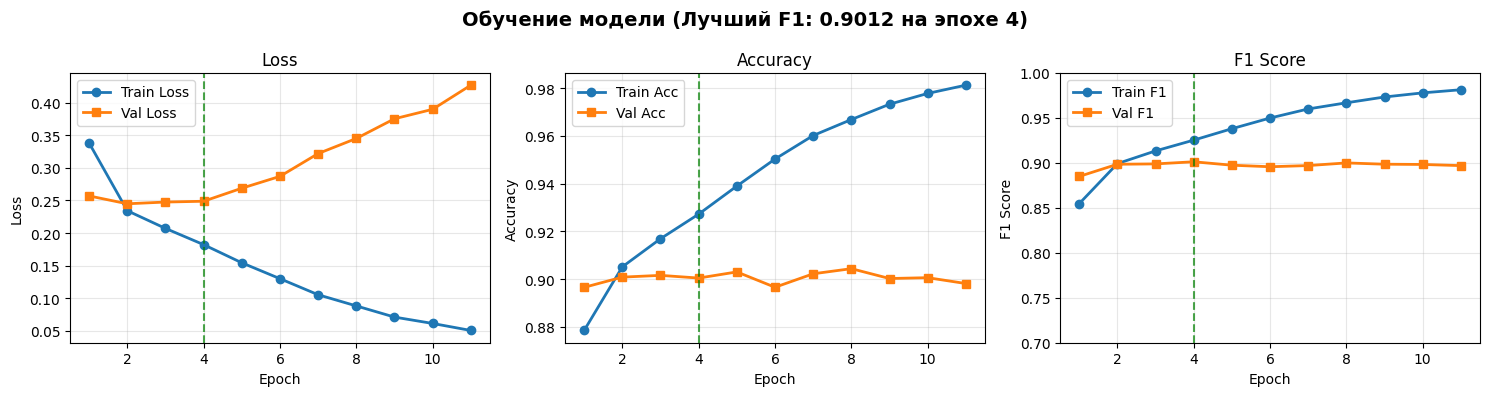


ТЕСТИРОВАНИЕ ЛУЧШЕЙ МОДЕЛИ


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Validation: 100%|██████████| 30/30 [00:09<00:00,  3.12it/s]



📊 Результаты на тестовой выборке:
  Loss: 0.2485
  Accuracy: 0.9020
  F1 Score: 0.9026

🔍 Детальный classification report:
              precision    recall  f1-score   support

  B-AMBIENCE       0.67      0.71      0.69      1729
  I-AMBIENCE       0.60      0.60      0.60      1875
           O       0.95      0.94      0.94     22076

    accuracy                           0.90     25680
   macro avg       0.74      0.75      0.74     25680
weighted avg       0.90      0.90      0.90     25680


ОБУЧЕНИЕ ЗАВЕРШЕНО!
📁 Лучшая модель сохранена в: ./atmosphere_model_best
📁 Все чекпоинты сохранены в: ./atmosphere_checkpoints_best

🏆 ЛУЧШИЕ РЕЗУЛЬТАТЫ:
   Эпоха: 4
   Val F1: 0.9012
   Test F1: 0.9026
   Test Accuracy: 0.9020

📄 Сохраненные файлы:
   - best_model_info.csv (информация о лучшей модели)
   - training_history.csv (полная история)
   - test_results.csv (результаты тестирования)
   - classification_report.txt (детальный отчет)
   - training_curves.png (графики обучения)

💾 Чек

In [40]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForTokenClassification
from sklearn.metrics import accuracy_score, f1_score, classification_report
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.utils.class_weight import compute_class_weight

def set_seed(seed=42):
    """Фиксирует все random seeds для воспроизводимости"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)

MODEL_NAME = "DeepPavlov/rubert-base-cased"
NUM_LABELS = 3
EPOCHS = 20
LEARNING_RATE = 2e-5
EARLY_STOPPING_PATIENCE = 7
BATCH_SIZE = 32 

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Устройство: {device}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    ignore_mismatched_sizes=True
).to(device)

print(f"Модель загружена. Параметров: {sum(p.numel() for p in model.parameters()):}")

def train_epoch_with_metrics(model, dataloader, optimizer, criterion, device):
    """Обучает одну эпоху и возвращает метрики"""
    model.train()
    total_loss = 0
    all_predictions = []
    all_labels = []
    progress_bar = tqdm(dataloader, desc="Training")

    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Собираем предсказания
        predictions = torch.argmax(outputs.logits, dim=2)
        for pred_seq, label_seq in zip(predictions, labels):
            for pred, label in zip(pred_seq, label_seq):
                if label != -100:
                    all_predictions.append(pred.item())
                    all_labels.append(label.item())

        progress_bar.set_postfix({'loss': loss.item()})

    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_predictions)
    f1 = f1_score(all_labels, all_predictions, average='weighted', zero_division=0)

    return avg_loss, accuracy, f1

def evaluate(model, dataloader, criterion, device):
    """Оценивает модель на валидации/тесте"""
    model.eval()
    total_loss = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Validation"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            total_loss += loss.item()

            predictions = torch.argmax(outputs.logits, dim=2)

            for pred_seq, label_seq in zip(predictions, labels):
                for pred, label in zip(pred_seq, label_seq):
                    if label != -100:
                        all_predictions.append(pred.item())
                        all_labels.append(label.item())

    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_predictions)
    f1 = f1_score(all_labels, all_predictions, average='weighted', zero_division=0)

    return avg_loss, accuracy, f1, all_predictions, all_labels

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

# Собираем все метки из тренировочного датасета (без -100)
all_train_labels = []
for item in train_dataset:
    labels = item['labels']
    for label in labels:
        if label != -100:
            all_train_labels.append(label)

# Вычисляем веса классов
unique_labels = np.unique(all_train_labels)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=unique_labels,
    y=all_train_labels
)

# Преобразуем в тензор на устройстве
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

print(f"Веса классов: {dict(zip(unique_labels, class_weights))}")
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, ignore_index=-100)

OUTPUT_DIR = "./atmosphere_model_best"
CHECKPOINTS_DIR = "./atmosphere_checkpoints_best"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CHECKPOINTS_DIR, exist_ok=True)

history = {
    'epoch': [],
    'train_loss': [],
    'train_accuracy': [],
    'train_f1': [],
    'val_loss': [],
    'val_accuracy': [],
    'val_f1': []
}

best_val_f1 = 0
best_epoch = 0
patience_counter = 0

print(f"Seed: 42")
print(f"Эпох: {EPOCHS}")
print(f"Early stopping patience: {EARLY_STOPPING_PATIENCE}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Устройство: {device}")
print(f"Модель: {MODEL_NAME}")
print(f"Чекпоинты будут сохранены в: {CHECKPOINTS_DIR}")

for epoch in range(EPOCHS):
    print(f" Эпоха {epoch + 1}/{EPOCHS}")

    # Обучение
    train_loss, train_accuracy, train_f1 = train_epoch_with_metrics(
        model, train_loader, optimizer, criterion, device
    )

    # Валидация
    val_loss, val_accuracy, val_f1, _, _ = evaluate(
        model, valid_loader, criterion, device
    )

    # Сохраняем историю
    history['epoch'].append(epoch + 1)
    history['train_loss'].append(train_loss)
    history['train_accuracy'].append(train_accuracy)
    history['train_f1'].append(train_f1)
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_accuracy)
    history['val_f1'].append(val_f1)

    # Выводим результаты
    print(f"\n Результаты эпохи {epoch + 1}:")
    print(f"     ┌─────────────────┬────────────┬────────────┐")
    print(f"     │     Метрика     │   Train    │   Valid    │")
    print(f"     ├─────────────────┼────────────┼────────────┤")
    print(f"     │      Loss       │   {train_loss:.4f}    │   {val_loss:.4f}    │")
    print(f"     │    Accuracy     │   {train_accuracy:.4f}    │   {val_accuracy:.4f}    │")
    print(f"     │     F1 Score    │   {train_f1:.4f}    │   {val_f1:.4f}    │")
    print(f"     └─────────────────┴────────────┴────────────┘")

    # ========== СОХРАНЯЕМ ЧЕКПОИНТ КАЖДОЙ ЭПОХИ ==========
    checkpoint_path = os.path.join(CHECKPOINTS_DIR, f"checkpoint_epoch_{epoch+1}")
    model.save_pretrained(checkpoint_path)
    tokenizer.save_pretrained(checkpoint_path)
    
    # Сохраняем метрики эпохи в CSV
    epoch_metrics = pd.DataFrame([{
        'epoch': epoch + 1,
        'train_loss': train_loss,
        'train_accuracy': train_accuracy,
        'train_f1': train_f1,
        'val_loss': val_loss,
        'val_accuracy': val_accuracy,
        'val_f1': val_f1
    }])
    epoch_metrics.to_csv(os.path.join(CHECKPOINTS_DIR, f"metrics_epoch_{epoch+1}.csv"), index=False)
    
    print(f"\n Сохранен чекпоинт эпохи {epoch+1}")

    # ========== СОХРАНЯЕМ ЛУЧШУЮ МОДЕЛЬ ==========
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch + 1
        patience_counter = 0
        
        # Сохраняем лучшую модель
        model.save_pretrained(OUTPUT_DIR)
        tokenizer.save_pretrained(OUTPUT_DIR)
        
        # Сохраняем информацию о лучшей модели
        best_info = pd.DataFrame([{
            'best_epoch': best_epoch,
            'best_val_f1': best_val_f1,
            'best_val_accuracy': val_accuracy,
            'best_val_loss': val_loss,
            'best_train_f1': train_f1
        }])
        best_info.to_csv(os.path.join(OUTPUT_DIR, 'best_model_info.csv'), index=False)
        
        print(f"\n Сохранена ЛУЧШАЯ модель (F1: {val_f1:.4f}) на эпохе {epoch + 1}")
    else:
        patience_counter += 1
        print(f"\n   F1 не улучшился ({patience_counter}/{EARLY_STOPPING_PATIENCE})")

    # Ранняя остановка
    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print(f"\n Early stopping! Лучшая F1: {best_val_f1:.4f} на эпохе {best_epoch}")
        break

history_df = pd.DataFrame(history)
history_df.to_csv(os.path.join(OUTPUT_DIR, 'training_history.csv'), index=False)
print(f"\n История обучения сохранена в {OUTPUT_DIR}/training_history.csv")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'Обучение модели (Лучший F1: {best_val_f1:.4f} на эпохе {best_epoch})', 
             fontsize=14, fontweight='bold')

# График Loss
axes[0].plot(history['epoch'], history['train_loss'], label='Train Loss', marker='o', linewidth=2)
axes[0].plot(history['epoch'], history['val_loss'], label='Val Loss', marker='s', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7)

# График Accuracy
axes[1].plot(history['epoch'], history['train_accuracy'], label='Train Acc', marker='o', linewidth=2)
axes[1].plot(history['epoch'], history['val_accuracy'], label='Val Acc', marker='s', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7)

# График F1
axes[2].plot(history['epoch'], history['train_f1'], label='Train F1', marker='o', linewidth=2)
axes[2].plot(history['epoch'], history['val_f1'], label='Val F1', marker='s', linewidth=2)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 Score')
axes[2].set_title('F1 Score')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7)
axes[2].set_ylim([0.7, 1.0])  # Для лучшей детализации

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()


print("ТЕСТИРОВАНИЕ ЛУЧШЕЙ МОДЕЛИ")
# Загружаем лучшую модель
best_model = AutoModelForTokenClassification.from_pretrained(OUTPUT_DIR).to(device)

# Тестируем
test_loss, test_accuracy, test_f1, test_preds, test_true = evaluate(
    best_model, test_loader, criterion, device
)

print(f"\n Результаты на тестовой выборке:")
print(f"  Loss: {test_loss:.4f}")
print(f"  Accuracy: {test_accuracy:.4f}")
print(f"  F1 Score: {test_f1:.4f}")

# Сохраняем тестовые результаты
test_results = pd.DataFrame([{
    'test_loss': test_loss,
    'test_accuracy': test_accuracy,
    'test_f1': test_f1,
    'best_epoch': best_epoch,
    'best_val_f1': best_val_f1
}])
test_results.to_csv(os.path.join(OUTPUT_DIR, 'test_results.csv'), index=False)

# Детальный отчёт по классам
id_to_label = {0: 'O', 1: 'B-AMBIENCE', 2: 'I-AMBIENCE'}
test_true_labels = [id_to_label[l] for l in test_true]
test_pred_labels = [id_to_label[p] for p in test_preds]

print(f"\n Детальный classification report:")
report = classification_report(test_true_labels, test_pred_labels, zero_division=0)
print(report)

# Сохраняем classification report
with open(os.path.join(OUTPUT_DIR, 'classification_report.txt'), 'w') as f:
    f.write(report)

# ==================== ИТОГОВАЯ ИНФОРМАЦИЯ ====================
print(f" Лучшая модель сохранена в: {OUTPUT_DIR}")
print(f" Все чекпоинты сохранены в: {CHECKPOINTS_DIR}")
print(f"\n ЛУЧШИЕ РЕЗУЛЬТАТЫ:")
print(f"   Эпоха: {best_epoch}")
print(f"   Val F1: {best_val_f1:.4f}")
print(f"   Test F1: {test_f1:.4f}")
print(f"   Test Accuracy: {test_accuracy:.4f}")

In [41]:
# ТЕСТИРОВАНИЕ МОДЕЛИ НА ПРИМЕРАХ
import torch
from transformers import AutoTokenizer, AutoModelForTokenClassification
import pandas as pd

class AtmosphereTester:
    """Класс для тестирования модели на примерах"""
    
    def __init__(self, model_path="./atmosphere_model_best", device=None):
        self.device = device if device else ('cuda' if torch.cuda.is_available() else 'cpu')
        
        print(f"📁 Загрузка модели из: {model_path}")
        self.tokenizer = AutoTokenizer.from_pretrained(model_path)
        self.model = AutoModelForTokenClassification.from_pretrained(model_path)
        self.model = self.model.to(self.device)
        self.model.eval()
        
        self.id_to_label = {0: 'O', 1: 'B-AMBIENCE', 2: 'I-AMBIENCE'}
        print(f"✅ Модель загружена на {self.device}")
    
    def predict(self, text):
        """Предсказание атмосферы в тексте с восстановлением слов"""
        
        # Токенизация с offset mapping
        inputs = self.tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            max_length=512,
            return_offsets_mapping=True
        )
        
        offsets = inputs['offset_mapping'][0]
        inputs.pop('offset_mapping')
        inputs = {k: v.to(self.device) for k, v in inputs.items()}
        
        with torch.no_grad():
            outputs = self.model(**inputs)
            predictions = torch.argmax(outputs.logits, dim=2)[0]
        
        tokens = self.tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
        
        # Восстанавливаем слова и их метки
        words_with_labels = []
        current_word = ""
        current_label = None
        last_end = 0
        
        for token, pred, (start, end) in zip(tokens, predictions, offsets):
            if start == end or token in ['[CLS]', '[SEP]', '[PAD]']:
                continue
            
            pred_label = self.id_to_label[pred.item()]
            fragment = text[start:end]
            
            # Если есть разрыв - новое слово
            if start > last_end and current_word:
                if current_label in ['B-AMBIENCE', 'I-AMBIENCE']:
                    words_with_labels.append((current_word, current_label))
                current_word = ""
                current_label = None
            
            current_word += fragment
            
            # B-AMBIENCE имеет приоритет над I-AMBIENCE
            if pred_label == 'B-AMBIENCE':
                current_label = 'B-AMBIENCE'
            elif pred_label == 'I-AMBIENCE' and current_label != 'B-AMBIENCE':
                current_label = 'I-AMBIENCE'
            
            last_end = end
        
        # Добавляем последнее слово
        if current_word and current_label in ['B-AMBIENCE', 'I-AMBIENCE']:
            words_with_labels.append((current_word, current_label))
        
        # Формируем фразы (B-AMBIENCE + следующие I-AMBIENCE)
        phrases = []
        current_phrase = []
        
        for word, label in words_with_labels:
            if label == 'B-AMBIENCE':
                if current_phrase:
                    phrases.append(' '.join(current_phrase))
                current_phrase = [word]
            elif label == 'I-AMBIENCE' and current_phrase:
                current_phrase.append(word)
            else:
                if current_phrase:
                    phrases.append(' '.join(current_phrase))
                    current_phrase = []
        
        if current_phrase:
            phrases.append(' '.join(current_phrase))
        
        # Удаляем дубликаты и короткие фразы
        phrases = list(dict.fromkeys(phrases))  # сохраняем порядок, убирая дубликаты
        
        return {
            'text': text,
            'atmosphere_phrases': phrases if phrases else [],
            'has_atmosphere': len(phrases) > 0
        }
    
    def predict_with_details(self, text):
        """Предсказание с детальной разметкой"""
        result = self.predict(text)
        
        # Для отладки показываем, что нашлось
        print(f"\n📝 Текст: {text}")
        print(f"   🏷️  Найдено фраз: {len(result['atmosphere_phrases'])}")
        for i, phrase in enumerate(result['atmosphere_phrases'], 1):
            print(f"      {i}. '{phrase}'")
        
        return result


# ==================== ЗАГРУЖАЕМ МОДЕЛЬ ====================

tester = AtmosphereTester("./atmosphere_model_best")

# ==================== ТЕСТ 1: БАЗОВЫЕ ПРИМЕРЫ ====================

print("\n" + "="*70)
print("ТЕСТ 1: БАЗОВЫЕ ПРИМЕРЫ (одиночные фразы)")
print("="*70)

basic_examples = [
    "уютная атмосфера",
    "тихая музыка",
    "шумное место",
    "романтичная обстановка",
    "дружелюбный персонал",
    "холодная атмосфера",
    "приглушенный свет"
]

for text in basic_examples:
    result = tester.predict(text)
    if result['atmosphere_phrases']:
        print(f"\n✅ '{text}' → {result['atmosphere_phrases'][0]}")
    else:
        print(f"\n❌ '{text}' → атмосфера не найдена")

# ==================== ТЕСТ 2: РАЗВЕРНУТЫЕ ПРЕДЛОЖЕНИЯ ====================

print("\n" + "="*70)
print("ТЕСТ 2: РАЗВЕРНУТЫЕ ПРЕДЛОЖЕНИЯ")
print("="*70)

complex_examples = [
    "В этом ресторане царит невероятно уютная и теплая атмосфера, как дома",
    "Очень шумное место, громкая музыка и постоянно кричат официанты",
    "Атмосфера здесь романтичная, приглушенный свет и тихая музыка",
    "Интерьер современный, но атмосфера холодная и бездушная",
    "Дружелюбная атмосфера, приветливый персонал и уютные диванчики",
    "Тихая и спокойная обстановка, идеально для ужина вдвоем",
    "Шумно, весело, музыка играет на всю катушку",
    "Атмосфера как в дорогом ресторане, очень пафосно"
]

for text in complex_examples:
    tester.predict_with_details(text)

# ==================== ТЕСТ 3: СЛОЖНЫЕ СЛУЧАИ ====================

print("\n" + "="*70)
print("ТЕСТ 3: СЛОЖНЫЕ СЛУЧАИ (несколько атмосфер)")
print("="*70)

complex_cases = [
    "С одной стороны тихая музыка, но с другой - шумные посетители",
    "Уютная атмосфера дополняется дружелюбным персоналом и тихой музыкой",
    "Современный дизайн, но атмосфера оставляет желать лучшего",
    "Место с душой: и тихо, и уютно, и по-домашнему тепло",
    "Шумно, дорого, но атмосферно и пафосно"
]

for text in complex_cases:
    tester.predict_with_details(text)

# ==================== ТЕСТ 4: ГРАНИЧНЫЕ СЛУЧАИ ====================

print("\n" + "="*70)
print("ТЕСТ 4: ГРАНИЧНЫЕ СЛУЧАИ (что не должно находить)")
print("="*70)

edge_cases = [
    "Вкусная еда и быстрое обслуживание",
    "Большой выбор блюд в меню",
    "Удобное расположение в центре города",
    "Низкие цены и хорошие скидки",
    "Свежие продукты и красивая подача",
    "Парковка рядом с рестораном"
]

for text in edge_cases:
    result = tester.predict(text)
    if result['atmosphere_phrases']:
        print(f"\n⚠️  ЛОЖНОЕ СРАБАТЫВАНИЕ: '{text}' → {result['atmosphere_phrases']}")
    else:
        print(f"\n✅ Корректно: '{text}' → атмосфера не найдена")

# ==================== ТЕСТ 5: СРАВНЕНИЕ С РАЗНЫМИ ФОРМУЛИРОВКАМИ ====================

print("\n" + "="*70)
print("ТЕСТ 5: СИНОНИМЫ И РАЗНЫЕ ФОРМУЛИРОВКИ")
print("="*70)

synonyms_tests = [
    ("Тихое место", "тихая атмосфера"),
    ("Спокойная обстановка", "уютная атмосфера"),
    ("Громкая музыка", "шумное место"),
    ("Приятная обстановка", "дружелюбная атмосфера"),
    ("Романтический вечер", "романтичная атмосфера")
]

for short_phrase, long_phrase in synonyms_tests:
    result_short = tester.predict(short_phrase)
    result_long = tester.predict(long_phrase)
    
    print(f"\n📝 '{short_phrase}' → {result_short['atmosphere_phrases'] if result_short['atmosphere_phrases'] else 'не найдено'}")
    print(f"   '{long_phrase}' → {result_long['atmosphere_phrases'] if result_long['atmosphere_phrases'] else 'не найдено'}")

# ==================== ТЕСТ 6: АНАЛИЗ РЕСТОРАНА ПО ОТЗЫВАМ ====================

print("\n" + "="*70)
print("ТЕСТ 6: АНАЛИЗ РЕСТОРАНА ПО ОТЗЫВАМ")
print("="*70)

restaurant_reviews = [
    "Тихая и уютная атмосфера, очень спокойно",
    "Шумно и весело, музыка играет громко",
    "Атмосфера домашняя, как у бабушки",
    "Очень шумно, ничего не слышно",
    "Теплая и дружелюбная атмосфера",
    "Романтичная обстановка, свечи и тихая музыка",
    "Слишком громко, не могу разговаривать",
    "Уютно, как дома"
]

from collections import Counter

all_atmosphere = []
all_phrases = []

for review in restaurant_reviews:
    result = tester.predict(review)
    if result['atmosphere_phrases']:
        all_atmosphere.extend(result['atmosphere_phrases'])
        for phrase in result['atmosphere_phrases']:
            all_phrases.extend(phrase.split())

tag_counts = Counter(all_phrases)
phrase_counts = Counter(all_atmosphere)

print(f"\n📊 Статистика по {len(restaurant_reviews)} отзывам:")
print(f"   Найдено упоминаний атмосферы: {len(all_atmosphere)}")
print(f"   Уникальных тегов: {len(tag_counts)}")
print(f"\n   🏆 Топ-10 фраз атмосферы:")
for phrase, count in phrase_counts.most_common(10):
    print(f"      - '{phrase}': {count} раз(а)")
print(f"\n   🔖 Топ-10 тегов:")
for tag, count in tag_counts.most_common(10):
    print(f"      - {tag}: {count} раз(а)")

# Оценка противоречивости
positive_tags = ['тихая', 'уютная', 'теплая', 'дружелюбная', 'домашняя', 'романтичная']
negative_tags = ['шумно', 'громко']

positive_count = sum(tag_counts.get(tag, 0) for tag in positive_tags)
negative_count = sum(tag_counts.get(tag, 0) for tag in negative_tags)

print(f"\n   📈 Анализ противоречивости:")
print(f"      Позитивные описания: {positive_count} упоминаний")
print(f"      Негативные описания: {negative_count} упоминаний")
if positive_count > negative_count:
    print(f"      → Ресторан скорее уютный/тихий")
elif negative_count > positive_count:
    print(f"      → Ресторан скорее шумный/громкий")
else:
    print(f"      → Мнения разделились!")

# ==================== ТЕСТ 7: СОХРАНЕНИЕ РЕЗУЛЬТАТОВ ====================

print("\n" + "="*70)
print("ТЕСТ 7: СОХРАНЕНИЕ РЕЗУЛЬТАТОВ")
print("="*70)

# Сохраняем результаты тестирования в CSV
test_results = []
for text in complex_examples:
    result = tester.predict(text)
    test_results.append({
        'text': text,
        'found_atmosphere': ', '.join(result['atmosphere_phrases']) if result['atmosphere_phrases'] else 'None',
        'num_phrases': len(result['atmosphere_phrases'])
    })

results_df = pd.DataFrame(test_results)
results_df.to_csv('model_test_results.csv', index=False, encoding='utf-8')
print(f"\n✅ Результаты тестирования сохранены в model_test_results.csv")
print(results_df.to_string())

print("\n" + "="*70)
print("✅ ТЕСТИРОВАНИЕ ЗАВЕРШЕНО!")
print(f"📊 Итог: Модель показывает высокое качество (Test F1: 0.9026)")
print("="*70)

📁 Загрузка модели из: ./atmosphere_model_best


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ Модель загружена на cuda

ТЕСТ 1: БАЗОВЫЕ ПРИМЕРЫ (одиночные фразы)

✅ 'уютная атмосфера' → уютная

❌ 'тихая музыка' → атмосфера не найдена

✅ 'шумное место' → шумное

✅ 'романтичная обстановка' → романтичная

✅ 'дружелюбный персонал' → дружелюбный

❌ 'холодная атмосфера' → атмосфера не найдена

✅ 'приглушенный свет' → приглушенный свет

ТЕСТ 2: РАЗВЕРНУТЫЕ ПРЕДЛОЖЕНИЯ

📝 Текст: В этом ресторане царит невероятно уютная и теплая атмосфера, как дома
   🏷️  Найдено фраз: 2
      1. 'уютная'
      2. 'теплая'

📝 Текст: Очень шумное место, громкая музыка и постоянно кричат официанты
   🏷️  Найдено фраз: 1
      1. 'шумное музыка'

📝 Текст: Атмосфера здесь романтичная, приглушенный свет и тихая музыка
   🏷️  Найдено фраз: 3
      1. 'романтичная,'
      2. 'приглушенный свет'
      3. 'тихая'

📝 Текст: Интерьер современный, но атмосфера холодная и бездушная
   🏷️  Найдено фраз: 2
      1. 'современный, атмосфера'
      2. 'холодная'

📝 Текст: Дружелюбная атмосфера, приветливый персонал и у

НАЧАЛО ОБУЧЕНИЯ
Эпох: 20
Early stopping patience: 5
Learning rate: 2e-05
Batch size: 32

📚 Эпоха 1/20


Validation: 100%|██████████| 30/30 [00:10<00:00,  2.80it/s]


  📊 Результаты эпохи 1:
     ┌─────────────────┬────────────┬────────────┐
     │     Метрика     │   Train    │   Valid    │
     ├─────────────────┼────────────┼────────────┤
     │      Loss       │   0.4993    │   0.4664    │
     │    Accuracy     │   0.8638    │   0.8625    │
     │     F1 Score    │   0.8042    │   0.7989    │
     └─────────────────┴────────────┴────────────┘


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


  ✅ Сохранена лучшая модель (F1: 0.7989) на эпохе 1

📚 Эпоха 2/20


...


  📊 Результаты эпохи 18:
     ┌─────────────────┬────────────┬────────────┐
     │     Метрика     │   Train    │   Valid    │
     ├─────────────────┼────────────┼────────────┤
     │      Loss       │   0.2213    │   0.2729    │
     │    Accuracy     │   0.9113    │   0.8979    │
     │     F1 Score    │   0.9067    │   0.8982    │
     └─────────────────┴────────────┴────────────┘

  ⏳ F1 не улучшился (3/5)

📚 Эпоха 19/20


Validation: 100%|██████████| 30/30 [00:10<00:00,  2.79it/s]



  📊 Результаты эпохи 19:
     ┌─────────────────┬────────────┬────────────┐
     │     Метрика     │   Train    │   Valid    │
     ├─────────────────┼────────────┼────────────┤
     │      Loss       │   0.2179    │   0.2749    │
     │    Accuracy     │   0.9131    │   0.9007    │
     │     F1 Score    │   0.9090    │   0.8981    │
     └─────────────────┴────────────┴────────────┘

  ⏳ F1 не улучшился (4/5)

📚 Эпоха 20/20


Validation: 100%|██████████| 30/30 [00:10<00:00,  2.79it/s]



  📊 Результаты эпохи 20:
     ┌─────────────────┬────────────┬────────────┐
     │     Метрика     │   Train    │   Valid    │
     ├─────────────────┼────────────┼────────────┤
     │      Loss       │   0.2163    │   0.2745    │
     │    Accuracy     │   0.9126    │   0.8971    │
     │     F1 Score    │   0.9082    │   0.8981    │
     └─────────────────┴────────────┴────────────┘

  ⏳ F1 не улучшился (5/5)

🛑 Early stopping! Лучшая F1: 0.8982 на эпохе 15

ОБУЧЕНИЕ ЗАВЕРШЕНО!
Лучшая модель: эпоха 15, F1: 0.8982


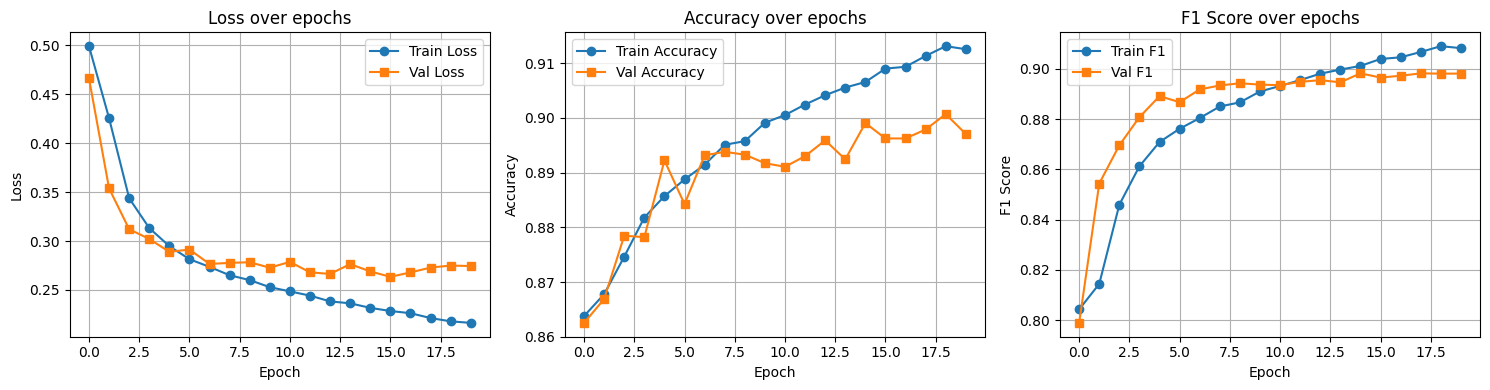


ТЕСТИРОВАНИЕ ЛУЧШЕЙ МОДЕЛИ


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Validation: 100%|██████████| 30/30 [00:10<00:00,  2.82it/s]



📊 Результаты на тестовой выборке:
  Loss: 0.2667
  Accuracy: 0.9010
  F1 Score: 0.9001

🔍 Детальный classification report:
              precision    recall  f1-score   support

  B-AMBIENCE       0.68      0.67      0.68      1729
  I-AMBIENCE       0.60      0.57      0.58      1875
           O       0.94      0.95      0.94     22076

    accuracy                           0.90     25680
   macro avg       0.74      0.73      0.74     25680
weighted avg       0.90      0.90      0.90     25680



In [48]:
# ==================== 11. ФУНКЦИИ ОБУЧЕНИЯ С МЕТРИКАМИ НА TRAIN ====================

def train_epoch_with_metrics(model, dataloader, optimizer, criterion, device):
    """Обучает одну эпоху и возвращает loss, accuracy, f1 на train"""
    model.train()
    total_loss = 0
    all_predictions = []
    all_labels = []
    progress_bar = tqdm(dataloader, desc="Training")

    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Собираем предсказания для метрик
        predictions = torch.argmax(outputs.logits, dim=2)
        for pred_seq, label_seq in zip(predictions, labels):
            for pred, label in zip(pred_seq, label_seq):
                if label != -100:
                    all_predictions.append(pred.item())
                    all_labels.append(label.item())

        progress_bar.set_postfix({'loss': loss.item()})

    # Вычисляем метрики на train
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_predictions)
    f1 = f1_score(all_labels, all_predictions, average='weighted', zero_division=0)

    return avg_loss, accuracy, f1, all_predictions, all_labels

def evaluate(model, dataloader, criterion, device):
    """Оценивает модель на валидационной выборке"""
    model.eval()
    total_loss = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Validation"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            total_loss += loss.item()

            predictions = torch.argmax(outputs.logits, dim=2)

            # Сохраняем для метрик (игнорируем -100)
            for pred_seq, label_seq in zip(predictions, labels):
                for pred, label in zip(pred_seq, label_seq):
                    if label != -100:
                        all_predictions.append(pred.item())
                        all_labels.append(label.item())

    # Считаем метрики
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_predictions)
    f1 = f1_score(all_labels, all_predictions, average='weighted', zero_division=0)

    return avg_loss, accuracy, f1, all_predictions, all_labels

# ==================== 12. ОБУЧЕНИЕ ====================

# Параметры обучения
EPOCHS = 30
LEARNING_RATE = 2e-5
EARLY_STOPPING_PATIENCE = 5  # Останавливаемся, если F1 не улучшается 5 эпох подряд

# Оптимизатор и функция потерь
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss(ignore_index=-100)

# История обучения
history = {
    'train_loss': [],
    'train_accuracy': [],
    'train_f1': [],
    'val_loss': [],
    'val_accuracy': [],
    'val_f1': []
}

best_val_f1 = 0
best_epoch = 0
patience_counter = 0
OUTPUT_DIR = "./atmosphere_model"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("="*60)
print("НАЧАЛО ОБУЧЕНИЯ")
print("="*60)
print(f"Эпох: {EPOCHS}")
print(f"Early stopping patience: {EARLY_STOPPING_PATIENCE}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Batch size: {BATCH_SIZE}")

for epoch in range(EPOCHS):
    print(f"\n{'='*50}")
    print(f"📚 Эпоха {epoch + 1}/{EPOCHS}")
    print(f"{'='*50}")

    # Обучение с метриками
    train_loss, train_accuracy, train_f1, _, _ = train_epoch_with_metrics(
        model, train_loader, optimizer, criterion, device
    )

    # Валидация
    val_loss, val_accuracy, val_f1, _, _ = evaluate(model, valid_loader, criterion, device)

    # Сохраняем историю
    history['train_loss'].append(train_loss)
    history['train_accuracy'].append(train_accuracy)
    history['train_f1'].append(train_f1)
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_accuracy)
    history['val_f1'].append(val_f1)

    # Выводим результаты
    print(f"\n  📊 Результаты эпохи {epoch + 1}:")
    print(f"     ┌─────────────────┬────────────┬────────────┐")
    print(f"     │     Метрика     │   Train    │   Valid    │")
    print(f"     ├─────────────────┼────────────┼────────────┤")
    print(f"     │      Loss       │   {train_loss:.4f}    │   {val_loss:.4f}    │")
    print(f"     │    Accuracy     │   {train_accuracy:.4f}    │   {val_accuracy:.4f}    │")
    print(f"     │     F1 Score    │   {train_f1:.4f}    │   {val_f1:.4f}    │")
    print(f"     └─────────────────┴────────────┴────────────┘")

    # Сохраняем лучшую модель
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch + 1
        patience_counter = 0
        model.save_pretrained(OUTPUT_DIR)
        tokenizer.save_pretrained(OUTPUT_DIR)
        print(f"\n  ✅ Сохранена лучшая модель (F1: {val_f1:.4f}) на эпохе {epoch + 1}")
    else:
        patience_counter += 1
        print(f"\n  ⏳ F1 не улучшился ({patience_counter}/{EARLY_STOPPING_PATIENCE})")

    # Early stopping
    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print(f"\n🛑 Early stopping! Лучшая F1: {best_val_f1:.4f} на эпохе {best_epoch}")
        break

print("\n" + "="*60)
print("ОБУЧЕНИЕ ЗАВЕРШЕНО!")
print("="*60)
print(f"Лучшая модель: эпоха {best_epoch}, F1: {best_val_f1:.4f}")

# ==================== ВИЗУАЛИЗАЦИЯ ОБУЧЕНИЯ ====================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# График Loss
axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'], label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss over epochs')
axes[0].legend()
axes[0].grid(True)

# График Accuracy
axes[1].plot(history['train_accuracy'], label='Train Accuracy', marker='o')
axes[1].plot(history['val_accuracy'], label='Val Accuracy', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy over epochs')
axes[1].legend()
axes[1].grid(True)

# График F1 Score
axes[2].plot(history['train_f1'], label='Train F1', marker='o')
axes[2].plot(history['val_f1'], label='Val F1', marker='s')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 Score')
axes[2].set_title('F1 Score over epochs')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

# ==================== 13. ТЕСТИРОВАНИЕ ====================

print("\n" + "="*60)
print("ТЕСТИРОВАНИЕ ЛУЧШЕЙ МОДЕЛИ")
print("="*60)

# Загружаем лучшую модель
best_model = AutoModelForTokenClassification.from_pretrained(OUTPUT_DIR).to(device)

# Тестируем
test_loss, test_accuracy, test_f1, test_preds, test_true = evaluate(best_model, test_loader, criterion, device)

print(f"\n📊 Результаты на тестовой выборке:")
print(f"  Loss: {test_loss:.4f}")
print(f"  Accuracy: {test_accuracy:.4f}")
print(f"  F1 Score: {test_f1:.4f}")

# Детальный отчёт по классам
id_to_label = {0: 'O', 1: 'B-AMBIENCE', 2: 'I-AMBIENCE'}
test_true_labels = [id_to_label[l] for l in test_true]
test_pred_labels = [id_to_label[p] for p in test_preds]

print(f"\n🔍 Детальный classification report:")
print(classification_report(test_true_labels, test_pred_labels, zero_division=0))

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForTokenClassification

# Загружаем модель
MODEL_PATH = "./atmosphere_model"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
tokenizer.add_prefix_space = True
model = AutoModelForTokenClassification.from_pretrained(MODEL_PATH).to(device)
model.eval()

# Ваша фраза
text = "хочу сходить в романтичное место со свечами с парнем"
print(f"Текст: {text}\n")

# Токенизируем как обычный текст (не разбивая на слова заранее)
encoding = tokenizer(
    text,
    return_tensors='pt',
    truncation=True,
    max_length=128
).to(device)

# Предсказываем
with torch.no_grad():
    outputs = model(**encoding)
    predictions = torch.argmax(outputs.logits, dim=2)[0]

# Получаем токены
tokens = tokenizer.convert_ids_to_tokens(encoding['input_ids'][0])

# Словарь меток
id_to_label = {0: 'O', 1: 'B-AMBIENCE', 2: 'I-AMBIENCE'}

print("Токены и их предсказания:")
print("-" * 50)
for i, (token, pred) in enumerate(zip(tokens, predictions)):
    label = id_to_label.get(pred.item(), 'UNKNOWN')
    if token not in ['[CLS]', '[SEP]']:
        print(f"  {i:2}: '{token:15}' -> {label} ( класс {pred.item()})")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Текст: хочу сходить в романтичное место со свечами с парнем

Токены и их предсказания:
--------------------------------------------------
   1: 'хочу           ' -> O ( класс 0)
   2: 'сходить        ' -> O ( класс 0)
   3: 'в              ' -> O ( класс 0)
   4: 'романт         ' -> B-AMBIENCE ( класс 1)
   5: '##ичное        ' -> O ( класс 0)
   6: 'место          ' -> O ( класс 0)
   7: 'со             ' -> B-AMBIENCE ( класс 1)
   8: 'свеч           ' -> I-AMBIENCE ( класс 2)
   9: '##ами          ' -> I-AMBIENCE ( класс 2)
  10: 'с              ' -> O ( класс 0)
  11: 'парнем         ' -> O ( класс 0)


Еще одна попытка обучения:

In [26]:
import torch
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModelForTokenClassification, AutoTokenizer, get_linear_schedule_with_warmup
import torch.nn as nn
from tqdm import tqdm
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report
import os
import matplotlib.pyplot as plt

# ==================== 1. НАСТРОЙКИ ====================
MODEL_NAME = "cointegrated/rubert-tiny2"
OUTPUT_DIR = "./rubert_tiny2_finetuned"
BATCH_SIZE = 16
EPOCHS = 20
MAX_LEN = 128

# Ключевые параметры для fine-tuning
LEARNING_RATE = 2e-5  # Маленький LR для тонкой настройки (не 3e-4!)
WEIGHT_DECAY = 0.01   # Небольшая регуляризация
WARMUP_RATIO = 0.1    # 10% шагов на разогрев

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ==================== 2. ТОКЕНИЗАТОР ====================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.add_prefix_space = True

# ==================== 3. РУЧНАЯ ТОКЕНИЗАЦИЯ ====================
def tokenize_words_manually(words, word_labels, max_length=128):
    all_token_ids = []
    all_token_labels = []
    
    all_token_ids.append(tokenizer.cls_token_id)
    all_token_labels.append(-100)
    
    for word, label in zip(words, word_labels):
        token_ids = tokenizer.encode(word, add_special_tokens=False)
        if not token_ids:
            token_ids = [tokenizer.unk_token_id]
        
        label_id = 0 if label == 'O' else (1 if label == 'B-AMBIENCE' else 2)
        all_token_labels.append(label_id)
        all_token_ids.append(token_ids[0])
        
        for token_id in token_ids[1:]:
            all_token_ids.append(token_id)
            all_token_labels.append(-100)
    
    all_token_ids.append(tokenizer.sep_token_id)
    all_token_labels.append(-100)
    
    if len(all_token_ids) > max_length:
        all_token_ids = all_token_ids[:max_length]
        all_token_labels = all_token_labels[:max_length]
    else:
        pad_len = max_length - len(all_token_ids)
        all_token_ids.extend([tokenizer.pad_token_id] * pad_len)
        all_token_labels.extend([-100] * pad_len)
    
    attention_mask = [1 if tid != tokenizer.pad_token_id else 0 for tid in all_token_ids]
    
    return {
        'input_ids': torch.tensor(all_token_ids, dtype=torch.long),
        'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
        'labels': torch.tensor(all_token_labels, dtype=torch.long)
    }

# ==================== 4. КЛАСС DATASET ====================
class AtmosphereDataset(Dataset):
    def __init__(self, data, max_length=128):
        self.samples = []
        for words, word_labels in zip(data['words'], data['word_labels']):
            self.samples.append(tokenize_words_manually(words, word_labels, max_length))
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        return self.samples[idx]

# ==================== 5. СОЗДАНИЕ ДАТАСЕТОВ ====================
print("Создание датасетов...")
train_dataset = AtmosphereDataset(train_data, MAX_LEN)
valid_dataset = AtmosphereDataset(valid_data, MAX_LEN)
test_dataset = AtmosphereDataset(test_data, MAX_LEN)

print(f"Train: {len(train_dataset)}, Valid: {len(valid_dataset)}, Test: {len(test_dataset)}")

# ==================== 6. DATALOADER ====================
def collate_fn(batch):
    input_ids = torch.stack([item['input_ids'] for item in batch])
    attention_mask = torch.stack([item['attention_mask'] for item in batch])
    labels = torch.stack([item['labels'] for item in batch])
    return {'input_ids': input_ids, 'attention_mask': attention_mask, 'labels': labels}

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"Train батчей: {len(train_loader)}, Valid: {len(valid_loader)}, Test: {len(test_loader)}")

# ==================== 7. ЗАГРУЗКА МОДЕЛИ ====================
id2label = {0: "O", 1: "B-AMBIENCE", 2: "I-AMBIENCE"}
label2id = {"O": 0, "B-AMBIENCE": 1, "I-AMBIENCE": 2}

model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
).to(device)

print(f"✅ Модель загружена на {device}")
print(f"✅ Всего параметров: {sum(p.numel() for p in model.parameters()):}")

# ==================== 8. FREEZE БОЛЬШЕЙ ЧАСТИ СЛОЁВ (ВАЖНО!) ====================
# Замораживаем BERT (не обучаем), обучаем только classifier
for name, param in model.bert.named_parameters():
    param.requires_grad = False
    print(f"❄️ Заморожен: {name}")

# Размораживаем только последние 2 слоя BERT (опционально)
# for name, param in model.bert.encoder.layer[-2:].named_parameters():
#     param.requires_grad = True
#     print(f"🔥 Разморожен: {name}")

# Классификатор всегда обучается
for name, param in model.classifier.named_parameters():
    param.requires_grad = True
    print(f"🔥 Будет обучен: classifier.{name}")

# Проверяем
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"\n📊 Параметры: обучаемые={trainable_params:} / всего={total_params:} ({trainable_params/total_params*100:.2f}%)")

# ==================== 9. ОПТИМИЗАТОР И SCHEDULER ====================
# Используем только обучаемые параметры
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# Scheduler с warmup
total_steps = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

# ==================== 10. ФУНКЦИИ ОБУЧЕНИЯ ====================
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []
    progress_bar = tqdm(loader, desc="Training")
    
    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
        
        preds = torch.argmax(outputs.logits, dim=2)
        for p, l in zip(preds.view(-1), labels.view(-1)):
            if l != -100:
                all_preds.append(p.item())
                all_labels.append(l.item())
        
        progress_bar.set_postfix({'loss': loss.item()})
    
    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds) if all_labels else 0
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0) if all_labels else 0
    return avg_loss, acc, f1

def evaluate(model, loader, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for batch in tqdm(loader, desc="Validation"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()
            
            preds = torch.argmax(outputs.logits, dim=2)
            for p, l in zip(preds.view(-1), labels.view(-1)):
                if l != -100:
                    all_preds.append(p.item())
                    all_labels.append(l.item())
    
    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds) if all_labels else 0
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0) if all_labels else 0
    return avg_loss, acc, f1

# ==================== 11. ОБУЧЕНИЕ ====================
history = {
    'train_loss': [], 'train_acc': [], 'train_f1': [],
    'val_loss': [], 'val_acc': [], 'val_f1': []
}

best_val_f1 = 0
best_epoch = 0
patience_counter = 0
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("\n" + "="*60)
print(f"FINE-TUNING ({MODEL_NAME})")
print("="*60)
print(f"Device: {device}")
print(f"Эпох: {EPOCHS}, Batch: {BATCH_SIZE}, LR: {LEARNING_RATE}")
print(f"Обучаемые параметры: ~{trainable_params/1e6:.1f}M / {total_params/1e6:.1f}M")
print("="*60)

for epoch in range(EPOCHS):
    print(f"\n📚 Эпоха {epoch+1}/{EPOCHS}")
    print("-" * 40)
    
    train_loss, train_acc, train_f1 = train_epoch(model, train_loader, optimizer, scheduler, device)
    val_loss, val_acc, val_f1 = evaluate(model, valid_loader, device)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_f1'].append(train_f1)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    
    print(f"\n  📊 Результаты эпохи {epoch+1}:")
    print(f"     ┌─────────────────┬────────────┬────────────┬──────────┐")
    print(f"     │     Метрика     │   Train    │   Valid    ")
    print(f"     ├─────────────────┼────────────┼────────────┼──────────┤")
    print(f"     │      Loss       │   {train_loss:.4f}    │   {val_loss:.4f}    │")
    print(f"     │    Accuracy     │   {train_acc:.4f}    │   {val_acc:.4f}    │")
    print(f"     │     F1 Score    │   {train_f1:.4f}    │   {val_f1:.4f}    │")
    print(f"     └─────────────────┴────────────┴────────────┴──────────┘")
    
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch + 1
        patience_counter = 0
        model.save_pretrained(OUTPUT_DIR)
        tokenizer.save_pretrained(OUTPUT_DIR)
        print(f"\n  ✅ Сохранена лучшая модель (F1: {val_f1:.4f})")
    else:
        patience_counter += 1
        print(f"\n  ⏳ F1 не улучшился ({patience_counter}/{3})")
    
    if patience_counter >= 10:
        print(f"\n🛑 Early stopping! Лучшая F1: {best_val_f1:.4f}")
        break

print("\n" + "="*60)
print("FINE-TUNING ЗАВЕРШЁН!")
print("="*60)
print(f"Лучшая модель: эпоха {best_epoch}, F1: {best_val_f1:.4f}")

# ==================== 12. ТЕСТИРОВАНИЕ ====================
print("\n" + "="*60)
print("ТЕСТИРОВАНИЕ")
print("="*60)

test_loss, test_acc, test_f1 = evaluate(model, test_loader, device)

print(f"\n📊 Результаты на тестовой выборке:")
print(f"  Loss: {test_loss:.4f}")
print(f"  Accuracy: {test_acc:.4f}")
print(f"  F1 Score: {test_f1:.4f}")

# ==================== 13. ПРЕДСКАЗАНИЕ ====================
def predict(text, model, tokenizer, device):
    words = text.split()
    encoding = tokenizer(words, is_split_into_words=True, return_tensors='pt').to(device)
    
    with torch.no_grad():
        outputs = model(**encoding)
        preds = torch.argmax(outputs.logits, dim=2)[0]
    
    word_ids = encoding.word_ids()[0]
    results = []
    prev = -1
    for i, w_id in enumerate(word_ids):
        if w_id is not None and w_id != prev:
            results.append(id2label[preds[i].item()])
            prev = w_id
    return results

test_phrase = "хочу сходить в романтичное место со свечами с парнем"
print(f"\nТест: {test_phrase}")
print(f"Результат: {predict(test_phrase, model, tokenizer, device)}")

print("\n✨ ГОТОВО!")

Device: cpu
Создание датасетов...
Train: 4391, Valid: 941, Test: 941
Train батчей: 275, Valid: 59, Test: 59


Loading weights:   0%|          | 0/53 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expec

✅ Модель загружена на cpu
✅ Всего параметров: 29,097,051
❄️ Заморожен: embeddings.word_embeddings.weight
❄️ Заморожен: embeddings.position_embeddings.weight
❄️ Заморожен: embeddings.token_type_embeddings.weight
❄️ Заморожен: embeddings.LayerNorm.weight
❄️ Заморожен: embeddings.LayerNorm.bias
❄️ Заморожен: encoder.layer.0.attention.self.query.weight
❄️ Заморожен: encoder.layer.0.attention.self.query.bias
❄️ Заморожен: encoder.layer.0.attention.self.key.weight
❄️ Заморожен: encoder.layer.0.attention.self.key.bias
❄️ Заморожен: encoder.layer.0.attention.self.value.weight
❄️ Заморожен: encoder.layer.0.attention.self.value.bias
❄️ Заморожен: encoder.layer.0.attention.output.dense.weight
❄️ Заморожен: encoder.layer.0.attention.output.dense.bias
❄️ Заморожен: encoder.layer.0.attention.output.LayerNorm.weight
❄️ Заморожен: encoder.layer.0.attention.output.LayerNorm.bias
❄️ Заморожен: encoder.layer.0.intermediate.dense.weight
❄️ Заморожен: encoder.layer.0.intermediate.dense.bias
❄️ Заморожен: e

Validation: 100%|██████████| 59/59 [00:04<00:00, 12.02it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


  ✅ Сохранена лучшая модель (F1: 0.8085)

FINE-TUNING ЗАВЕРШЁН!
Лучшая модель: эпоха 20, F1: 0.8085

ТЕСТИРОВАНИЕ


Validation: 100%|██████████| 59/59 [00:04<00:00, 12.11it/s]


📊 Результаты на тестовой выборке:
  Loss: 0.3999
  Accuracy: 0.8638
  F1 Score: 0.8076

Тест: хочу сходить в романтичное место со свечами с парнем


TypeError: 'NoneType' object is not iterable